**importing libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")
from sklearn.svm import LinearSVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize']=(12,6)
plt.rcParams["font.size"]=12
sns.set_style("whitegrid")




load the data

In [ ]:
import pandas as pd
dataset=pd.read_csv("/content/OnlineNewsPopularity.csv")


dataset.columns=dataset.columns.str.strip()

print("dataset loaded successfully (:")
print("Shape:",dataset.shape)

dataset.head()


dataset loaded successfully (:
Shape: (39644, 61)


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


DATA TYPES & MEMORY USAGE

In [ ]:

print("datatset info :")
dataset.info(memory_usage='deep')
print('_'*50)
print(dataset.describe().T)
'''share's mean=(3395.380184)>>50%=median=(1400.000000)?
then data is heavily skewed to the right
..using the mean as the threshold in classification would'nt be fair instead we use
 the median as the threshold beacause it's not affected by the
 outliers(max shares)'''




datatset info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            39644 non-null  object 
 1   timedelta                      39644 non-null  float64
 2   n_tokens_title                 39644 non-null  float64
 3   n_tokens_content               39644 non-null  float64
 4   n_unique_tokens                39644 non-null  float64
 5   n_non_stop_words               39644 non-null  float64
 6   n_non_stop_unique_tokens       39644 non-null  float64
 7   num_hrefs                      39644 non-null  float64
 8   num_self_hrefs                 39644 non-null  float64
 9   num_imgs                       39644 non-null  float64
 10  num_videos                     39644 non-null  float64
 11  average_token_length           39644 non-null  float64
 12  num_keywords                  

"share's mean=(3395.380184)>>50%=median=(1400.000000)?\nthen data is heavily skewed to the right\n..using the mean as the threshold in classification would'nt be fair instead we use\n the median as the threshold beacause it's not affected by the\n outliers(max shares)"

dropping non-predivtive columns :

In [ ]:
columns_to_drop=['url','timedelta']
dataset = dataset.drop(columns=columns_to_drop)

print("Dropped:",columns_to_drop)
print("dataset's new shape:",dataset.shape[0],"rows x",dataset.shape[1],'coulmns')

Dropped: ['url', 'timedelta']
dataset's new shape: 39644 rows x 59 coulmns


handling missing values

missing count: n_tokens_title                   0
n_tokens_content                 0
n_unique_tokens                  0
n_non_stop_words                 0
n_non_stop_unique_tokens         0
num_hrefs                        0
num_self_hrefs                   0
num_imgs                         0
num_videos                       0
average_token_length             0
num_keywords                     0
data_channel_is_lifestyle        0
data_channel_is_entertainment    0
data_channel_is_bus              0
data_channel_is_socmed           0
data_channel_is_tech             0
data_channel_is_world            0
kw_min_min                       0
kw_max_min                       0
kw_avg_min                       0
kw_min_max                       0
kw_max_max                       0
kw_avg_max                       0
kw_min_avg                       0
kw_max_avg                       0
kw_avg_avg                       0
self_reference_min_shares        0
self_reference_max_shares        0
self_

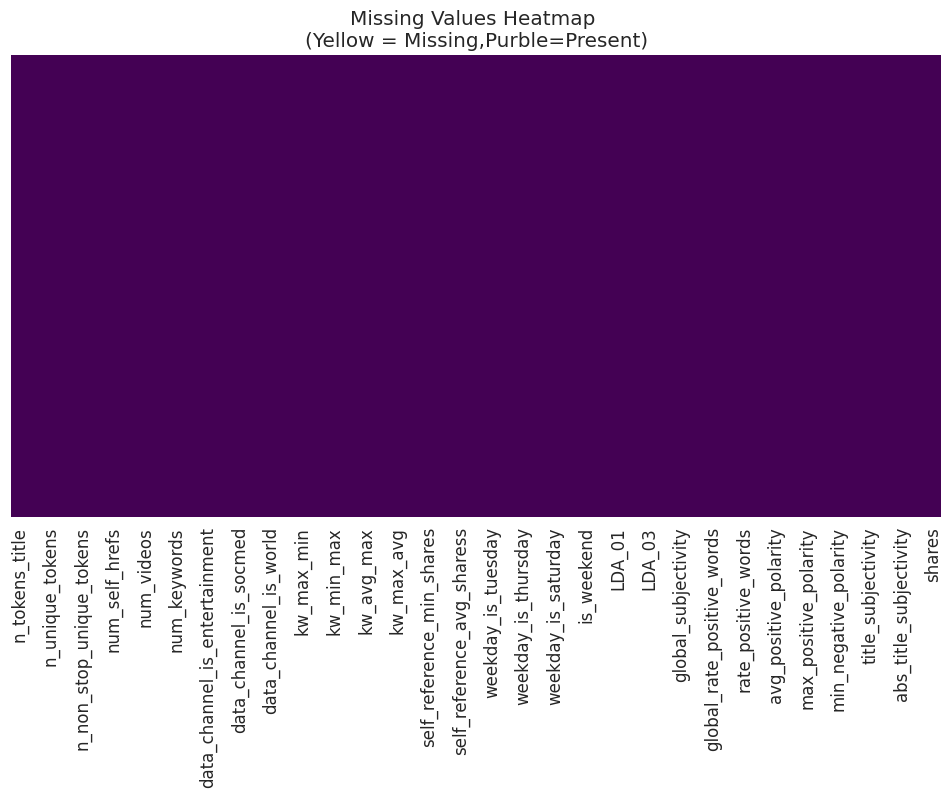

Fig saved


In [ ]:
missing=dataset.isnull().sum()
print("missing count:",missing)
print('_'*80)

missing_percentage=(missing/len(dataset))*100
print("missing percentage:",missing_percentage)
print('_'*80)
col_null= missing[missing > 0].index.tolist()
print("columns with null valuses if existed :", col_null)


if len(col_null)==0:
  print("no missing values in the dataset ")

sns.heatmap(dataset.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.title("Missing Values Heatmap \n(Yellow = Missing,Purble=Present)")
plt.savefig('missing_values_heatmap.png',dpi=150,bbox_inches='tight')
plt.show()
print("Fig saved")

duplication detection

In [ ]:
duplicate_counts=dataset.duplicated().sum()
'''duplicated checks each row ->returns true if duplicated
,false if not ,sum->counts the #of true rows  '''
duplicate_percentage=(duplicate_counts / len(dataset))*100
print(duplicate_counts)
'''duplicate rows are silent killers because they may bias
 the model ,data leakage ,inflating data'''
if duplicate_counts==0:
  print("no duplicated rows ")
else:
  print("found",duplicate_counts,"duplicates ->will drop them (:")
  dataset=dataset.drop_duplicates()
  print("duplicates r now removed ,dataset's new shape:",dataset.shape)

0
no duplicated rows 


detecting &visualizing outliers

lower: -1835.0 
 upper: 5581.0 
 Q1: 946.0 
 Q3: 2800.0 
 IQR: 1854.0
number of outliers: 4541
the percent of outliers: 11.454444556553325


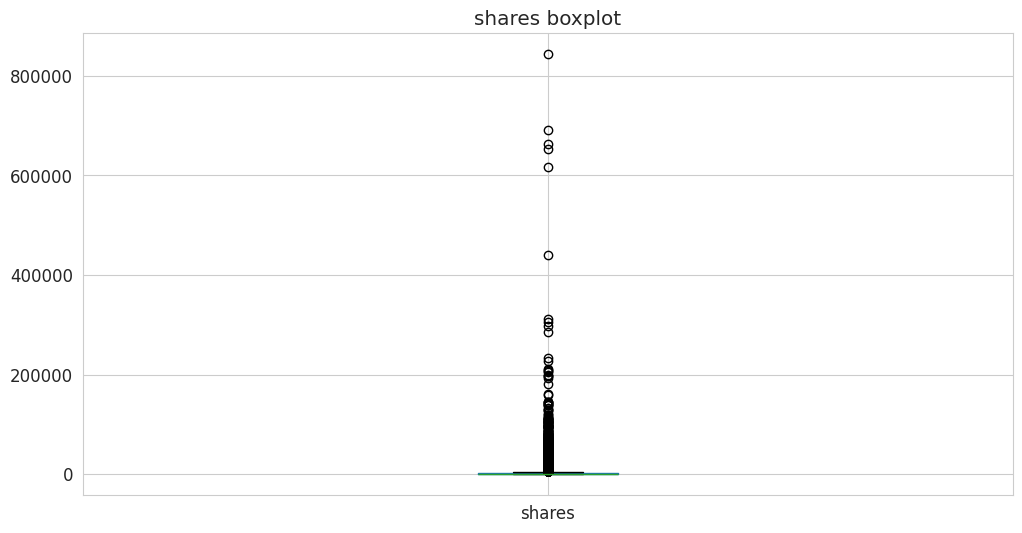

"the data is severly right-skewed ,we cannot drop these outliers since they're real records\n,we'll need to use log transformation here.\nSince the lower fence is negative this assurs to us that there are no lower outliers "

In [ ]:
#IQR to detect outliers :
Q1=dataset['shares'].quantile(0.25)
Q3=dataset['shares'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print("lower:",lower,'\n upper:',upper,'\n Q1:',Q1,'\n Q3:',Q3,'\n IQR:',IQR)
outliers=dataset[(dataset['shares']<lower) | (dataset['shares']>upper)]
print("number of outliers:",len(outliers))
print("the percent of outliers:",(len(outliers)/len(dataset))*100)

dataset.boxplot(column="shares")
plt.title("shares boxplot")
plt.show()

#the output shows a significant amount of outliers .. ~ 11.5% of the dataset r outliers ,which tells us :
'''the data is severly right-skewed ,we cannot drop these outliers since they're real records
,we'll need to use log transformation here.
Since the lower fence is negative this assurs to us that there are no lower outliers '''

dealing with outliers

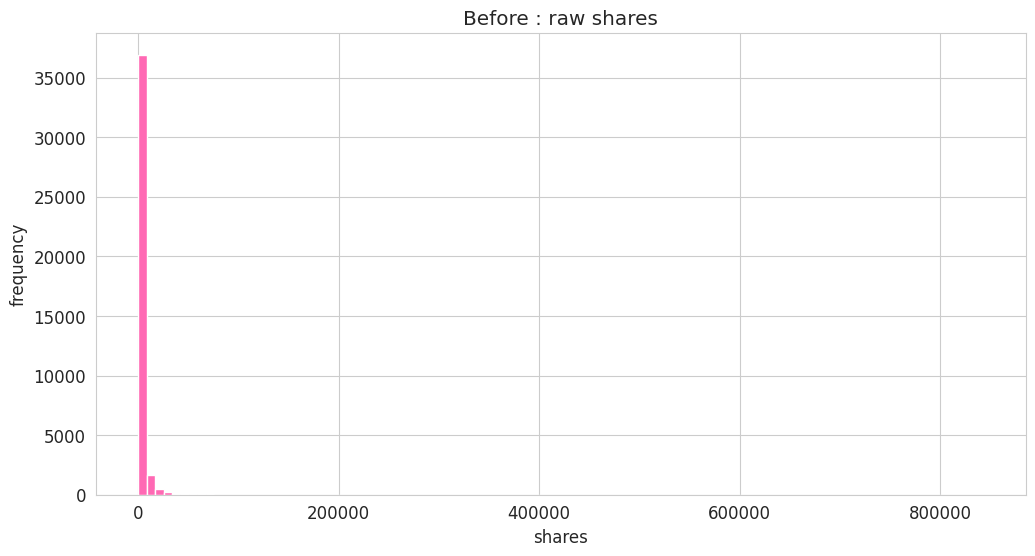

In [ ]:
dataset["log_shares"]=np.log1p(dataset['shares'])

'''added the log shares column to the dataset and kept the raw
 shares because we'll need it in task B'''

plt.hist(dataset['shares'],bins=100,color='hotpink')
plt.title("Before : raw shares")
plt.xlabel("shares")
plt.ylabel("frequency")
plt.show()

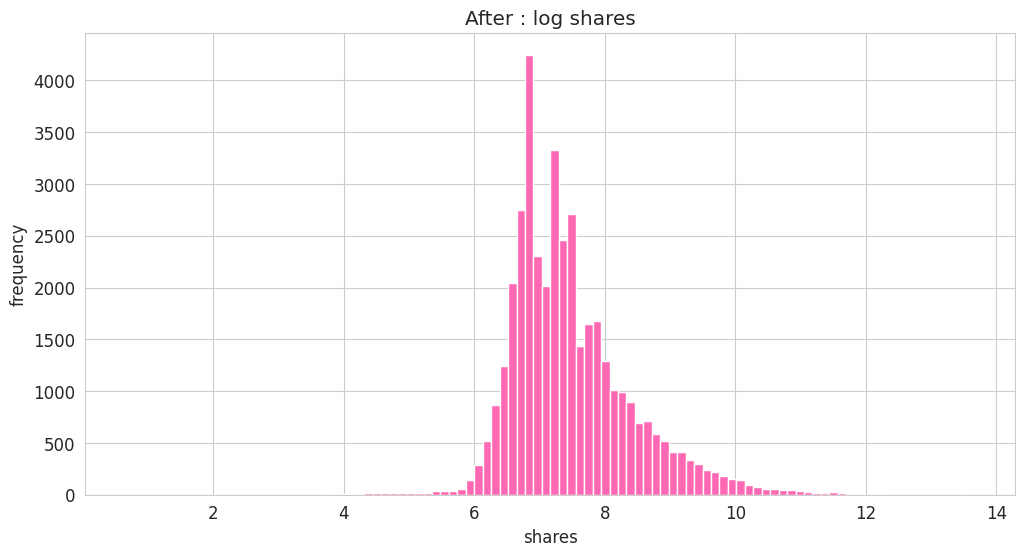

In [ ]:
plt.hist(dataset["log_shares"],bins=100,color="hotpink")
plt.title("After : log shares")
plt.xlabel("shares")
plt.ylabel("frequency")
plt.show()

encoding

In [ ]:
text_col=dataset.select_dtypes(include=['object']).columns
print("Text coulmns:",list(text_col))

print('did not need encoding')
print("categorical columns already encoded as binary ")

Text coulmns: []
did not need encoding
categorical columns already encoded as binary 


correaltion heatmap

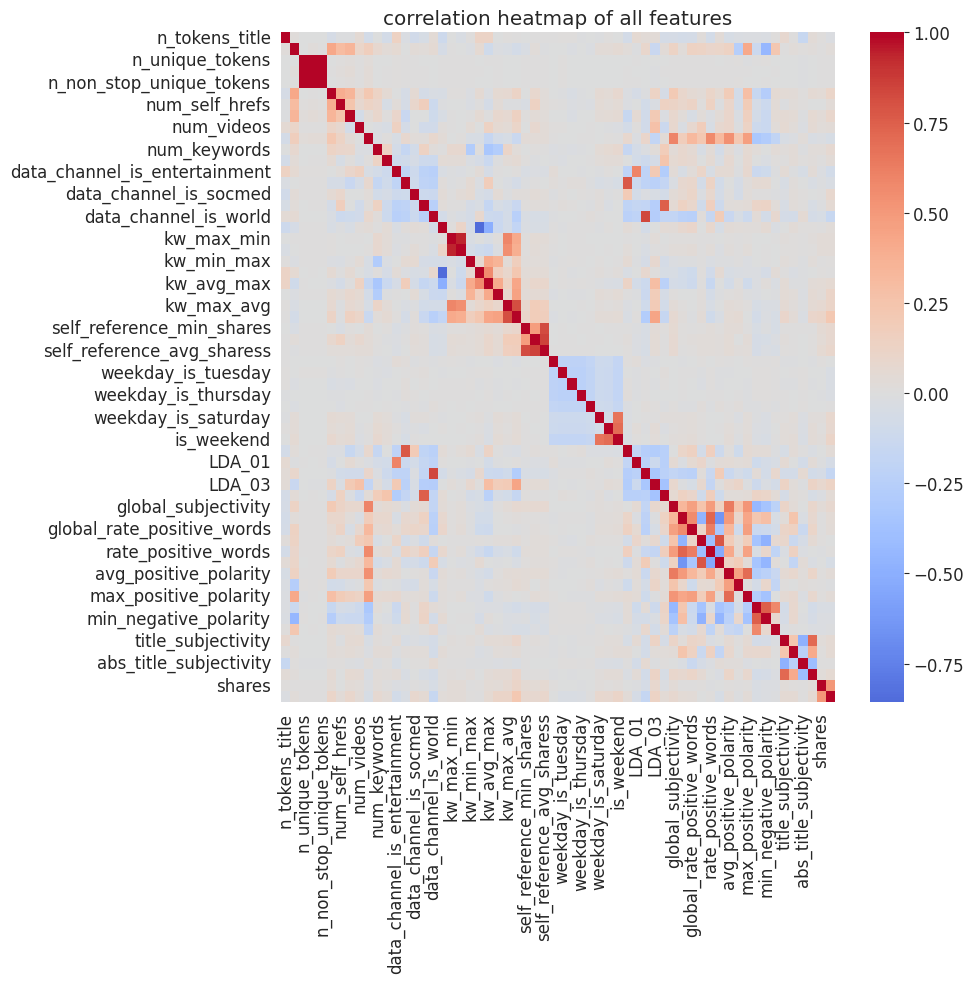

'*center =0 tells the colormap where to place the neutral color (white here)\n-1 -> dark blue (strong negative relation )\n0 ->white (no relation )\n1 ->bold red (strong positive relation )\nwithout center heatmap will use middle as the center .\n*.1f: one dicimal place '

In [ ]:
corr_matrix=dataset.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            center=0,
            fmt='.1f')
plt.title('correlation heatmap of all features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png',dpi=150,bbox_inches='tight')
plt.show()

'''*center =0 tells the colormap where to place the neutral color (white here)
-1 -> dark blue (strong negative relation )
0 ->white (no relation )
1 ->bold red (strong positive relation )
without center heatmap will use middle as the center .
*.1f: one dicimal place '''


corr wuth target column(s)

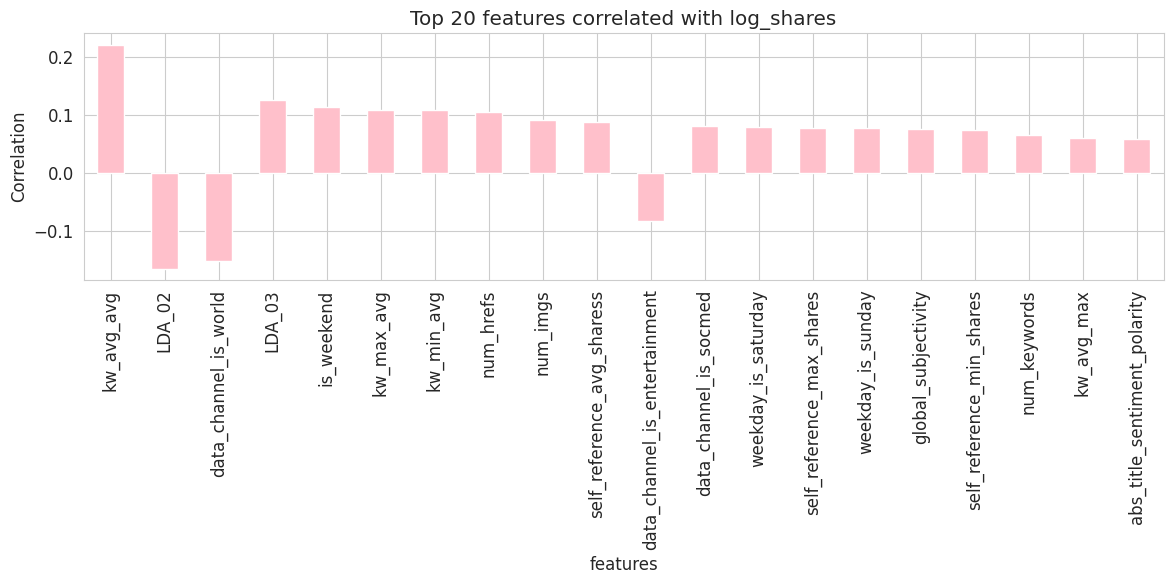

kw_avg_avg                       0.221822
LDA_02                          -0.165076
data_channel_is_world           -0.151685
LDA_03                           0.126037
is_weekend                       0.114391
kw_max_avg                       0.109343
kw_min_avg                       0.108850
num_hrefs                        0.105142
num_imgs                         0.091519
self_reference_avg_sharess       0.087238
data_channel_is_entertainment   -0.082531
data_channel_is_socmed           0.081144
weekday_is_saturday              0.079158
self_reference_max_shares        0.077442
weekday_is_sunday                0.076969
global_subjectivity              0.075174
self_reference_min_shares        0.073374
num_keywords                     0.065945
kw_avg_max                       0.059678
abs_title_sentiment_polarity     0.059191
Name: log_shares, dtype: float64


In [ ]:
correlations=dataset.corr()['log_shares'].drop(['log_shares','shares'])
correlations=correlations.reindex(correlations.abs().sort_values(ascending=False).index)

correlations[:20].plot(kind='bar',color='pink', edgecolor='white')
plt.title('Top 20 features correlated with log_shares')
plt.xlabel('features')
plt.ylabel('Correlation')



plt.tight_layout()
plt.savefig('top_20_features_corr.png',dpi=150,bbox_inches='tight')
plt.show()
print(correlations[:20])

day of week effect

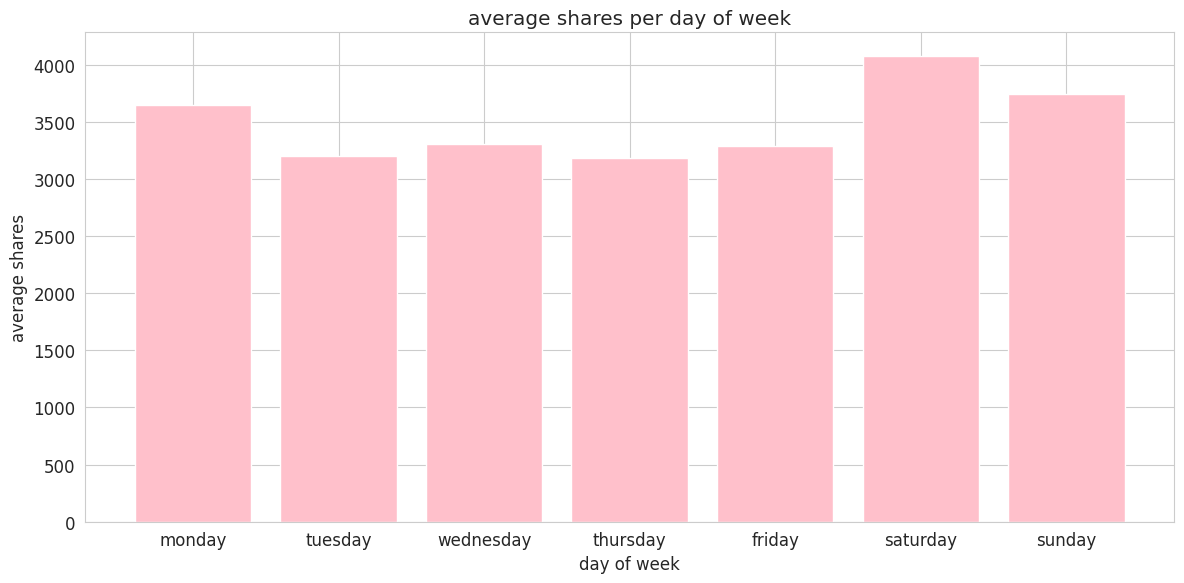

'as we can see sat affects shares the most (gets most shares:~4100)while thursday geta the least~3200'

In [ ]:
days=['monday','tuesday','wednesday','thursday','friday','saturday','sunday']

avg_shares_per_day=[]

for day in days:
  col='weekday_is_' +day
  avg=dataset[dataset[col]==1]['shares'].mean()
  avg_shares_per_day.append(avg)
plt.bar(days,avg_shares_per_day,color='pink',edgecolor='white')
plt.title('average shares per day of week')
plt.xlabel('day of week')
plt.ylabel('average shares')
plt.tight_layout()
plt.savefig('avg_shares_per_day.png',dpi=150,bbox_inches='tight')
plt.show()
'''as we can see sat affects shares the most (gets most shares:~4100)while thursday geta the least~3200'''

topic category analysis

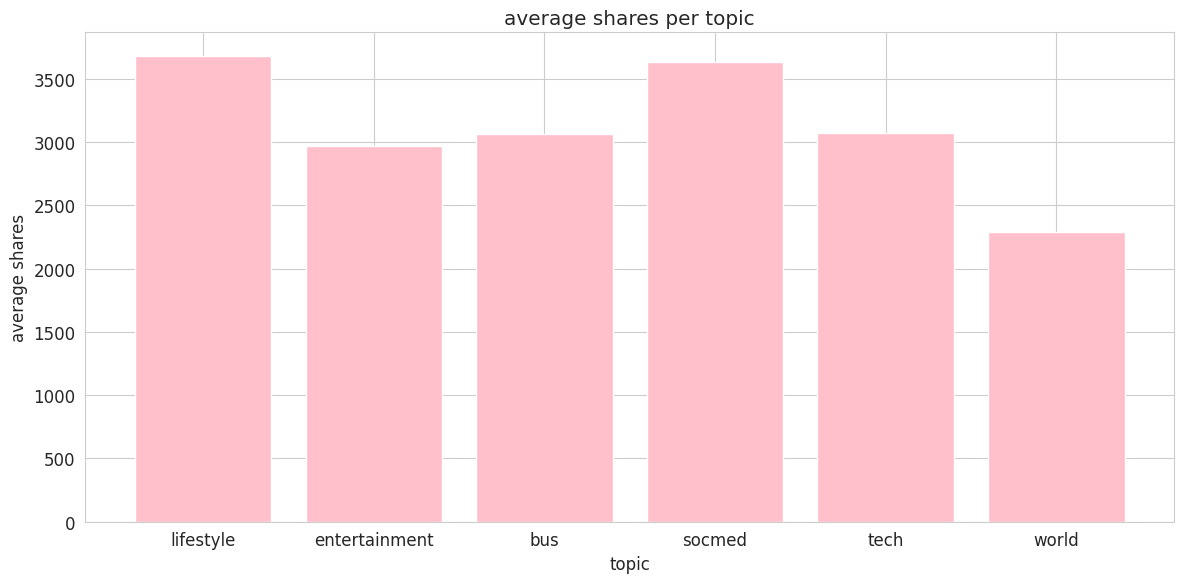

"as not expected:)... tech wasn't really the one with hieghst shares ...in fact lifestyle and socmed were the highest"

In [ ]:
#(which type of content performs best on mashable ?)
topics=['lifestyle','entertainment','bus','socmed','tech','world']
avg_shares_per_topic=[]
for topic in topics:
  col='data_channel_is_'+topic
  avg=dataset[dataset[col]==1]['shares'].mean()
  avg_shares_per_topic.append(avg)
plt.bar(topics,avg_shares_per_topic,color='pink',edgecolor='white')
plt.title('average shares per topic')
plt.xlabel('topic')
plt.ylabel('average shares')
plt.tight_layout()
plt.savefig('avg_shares_per_topic.png',dpi=150,bbox_inches='tight')
plt.show()
'''as not expected:)... tech wasn't really the one with hieghst shares ...in fact lifestyle and socmed were the highest'''

sentiment effect on shares

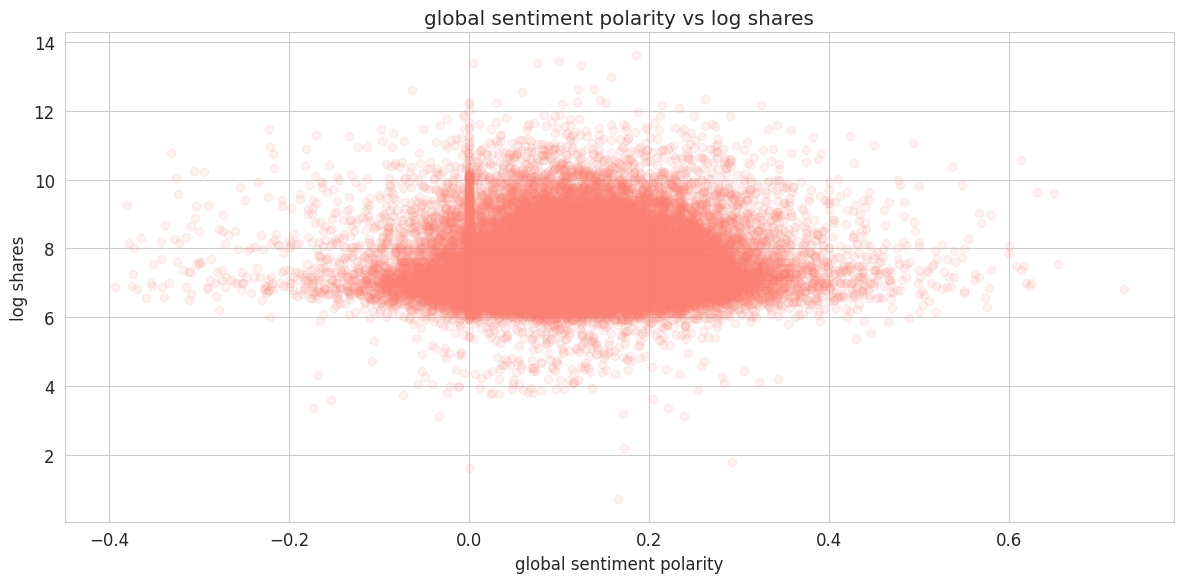

In [ ]:
#does the emotional sence of an article affect the # of shares ?
plt.scatter(dataset['global_sentiment_polarity'],
            dataset['log_shares'],
            alpha=0.1,
            color='salmon')
plt.title('global sentiment polarity vs log shares')
plt.xlabel('global sentiment polarity')
plt.ylabel('log shares')
plt.tight_layout()
plt.savefig('sentiment_vs_shares.png', dpi=150, bbox_inches='tight')
plt.show()
#weak relation ...insufficient to predict popularity
# the line at 0.0 at x axis indicates the neutral articles(totally objective )

why i did not choose shares :

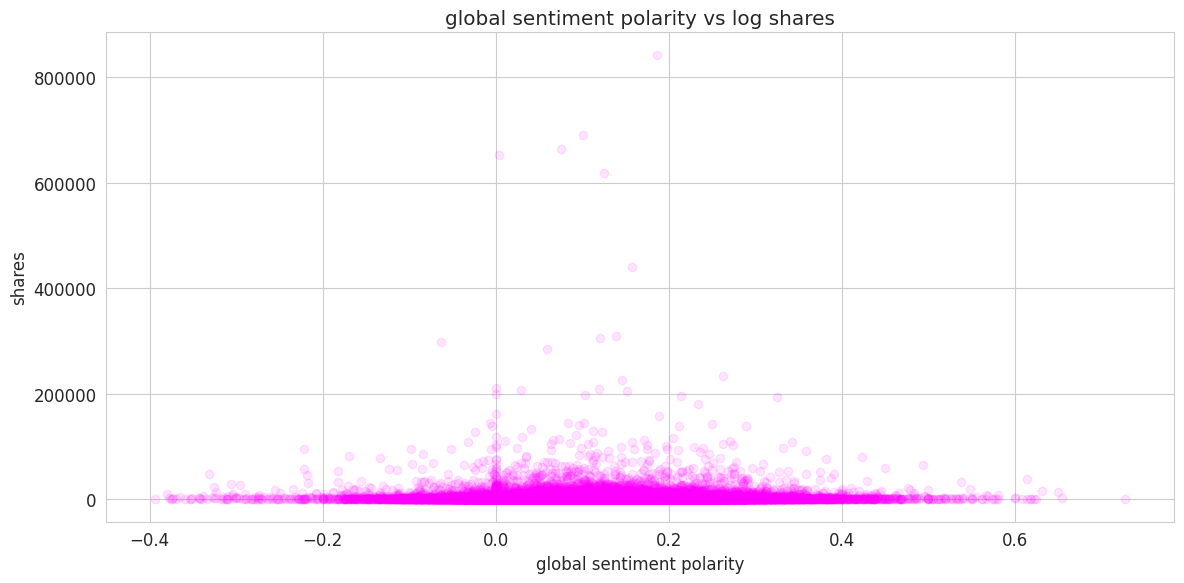

In [ ]:
plt.scatter(dataset['global_sentiment_polarity'],
            dataset['shares'],
            alpha=0.1,
            color='magenta')
plt.title('global sentiment polarity vs log shares')
plt.xlabel('global sentiment polarity')
plt.ylabel('shares')
plt.tight_layout()
plt.savefig('sentiment_vs_shares.png', dpi=150, bbox_inches='tight')
plt.show()
#this is why we didn't use shares on y axis :it compressed all noraml articles at the bottom,the outliers r dominating the plot (:

mwdia effect on shares

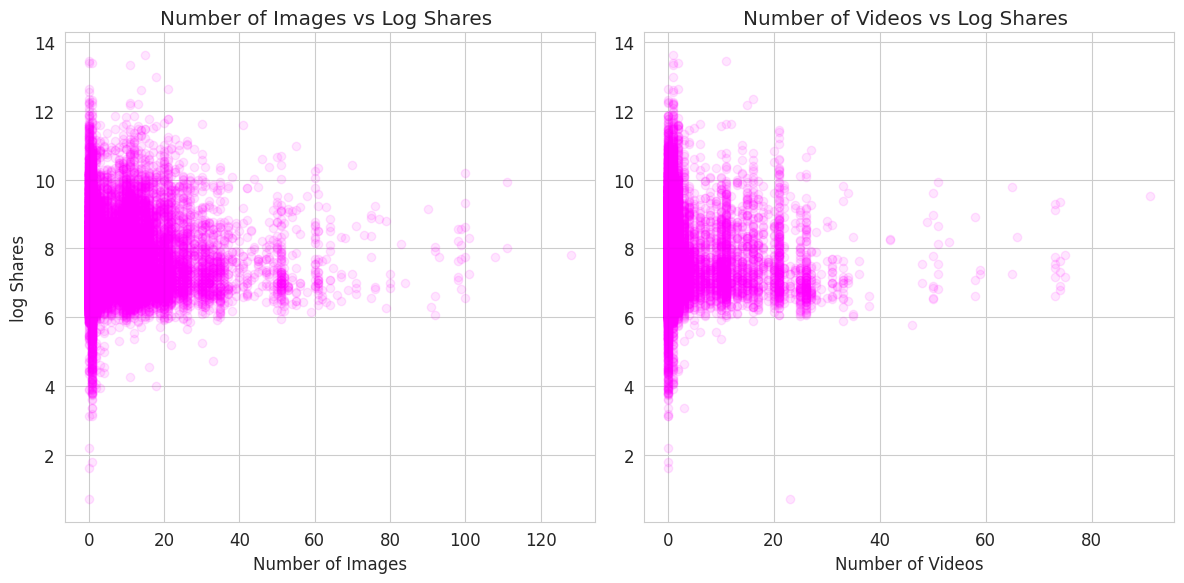

In [ ]:
fig, axes = plt.subplots(1,2)

#image:
axes[0].scatter(dataset['num_imgs'],dataset['log_shares'],alpha=0.1 ,color='magenta')
axes[0].set_title("Number of Images vs Log Shares ")
axes[0].set_xlabel("Number of Images")
axes[0].set_ylabel("log Shares")

#videos:
axes[1].scatter(dataset['num_videos'],dataset['log_shares'],alpha=0.1 ,color='magenta')
axes[1].set_title("Number of Videos vs Log Shares ")
axes[1].set_xlabel("Number of Videos")

plt.tight_layout()
plt.savefig('media_vs_shares.png', dpi=150, bbox_inches='tight')
plt.show()


content length effect on shares

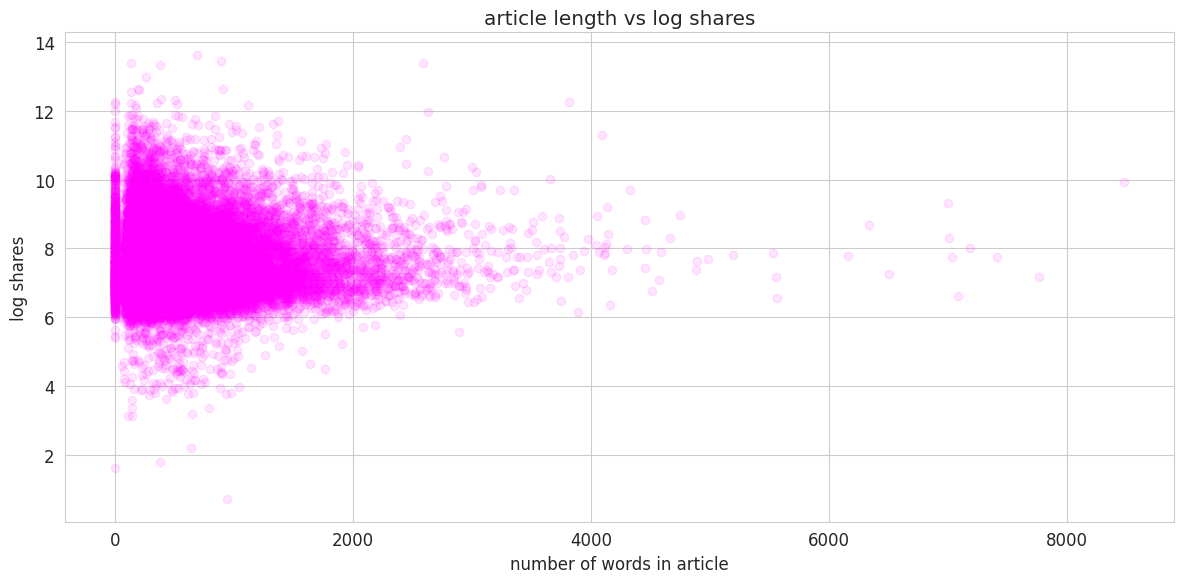

"articls that show zero words ...are probably video only articles,image galleries,or articles where text wasn't captured properly"

In [ ]:
plt.scatter(dataset['n_tokens_content'], dataset['log_shares'], alpha=0.1, color='magenta')
plt.title('article length vs log shares')
plt.xlabel('number of words in article')
plt.ylabel('log shares')
plt.tight_layout()
plt.savefig('content_length_vs_shares.png', dpi=150, bbox_inches='tight')
plt.show()
'''articls that show zero words ...are probably video only articles,image galleries,or articles where text wasn't captured properly'''

density plots

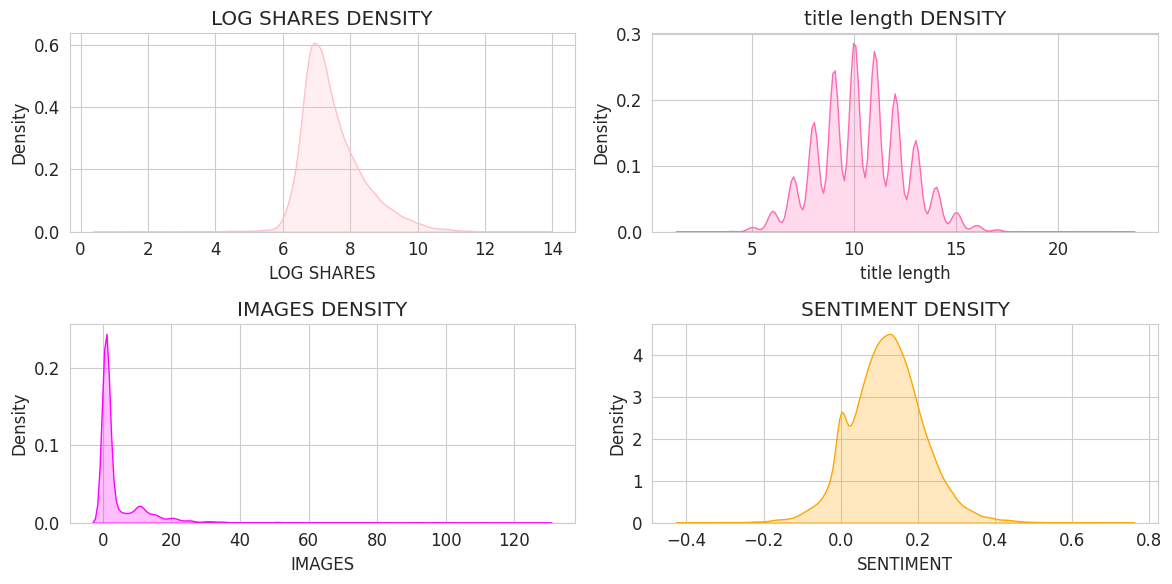

"what do these graphs represent?:\n1)almost bell shaped data :log transformation was the right thing to do.\n2) most articles are short (0-500) word the data is right skewed.\n3) peak is at (0-5)imgs data is also right skewed .\n4) data is almost bell shaped ..peak is at (0.1-0.2). Having a small pumb (little peak)around 0\nmeans that there're two grops of articls exist in this feature..nuetral and almost positive ones"

In [ ]:
fig,axes=plt.subplots(2,2)#4 plots
#upper left:
sns.kdeplot(dataset['log_shares'],ax=axes[0,0],color='pink',fill=True)
axes[0,0].set_title('LOG SHARES DENSITY')
axes[0,0].set_xlabel("LOG SHARES")


#upper right
'''sns.kdeplot(dataset['n_tokens_content'],ax=axes[0,1],color="hotpink",fill=True)
axes[0,1].set_title('ARTICLE LENGTH DENSITY')
axes[0,1].set_xlabel("ARTICLE LENGTH")'''

#just tried title length col and felt it's more intresting than article length:
sns.kdeplot(dataset['n_tokens_title'],ax=axes[0,1],color="hotpink",fill=True)
axes[0,1].set_title('title length DENSITY')
axes[0,1].set_xlabel("title length")


#lower left:
sns.kdeplot(dataset['num_imgs'], ax=axes[1,0],color='magenta',fill=True)
axes[1,0].set_title('IMAGES DENSITY')
axes[1,0].set_xlabel("IMAGES")

#lower right:
sns.kdeplot(dataset['global_sentiment_polarity'],ax=axes[1,1],color='orange',fill=True)
axes[1,1].set_title('SENTIMENT DENSITY')
axes[1,1].set_xlabel("SENTIMENT")

plt.tight_layout()
plt.savefig('density_plots.png', dpi=150, bbox_inches='tight')
plt.show()
'''what do these graphs represent?:
1)almost bell shaped data :log transformation was the right thing to do.
2) most articles are short (0-500) word the data is right skewed.
3) peak is at (0-5)imgs data is also right skewed .
4) data is almost bell shaped ..peak is at (0.1-0.2). Having a small pumb (little peak)around 0
means that there're two grops of articls exist in this feature..nuetral and almost positive ones'''


boxplots per category :

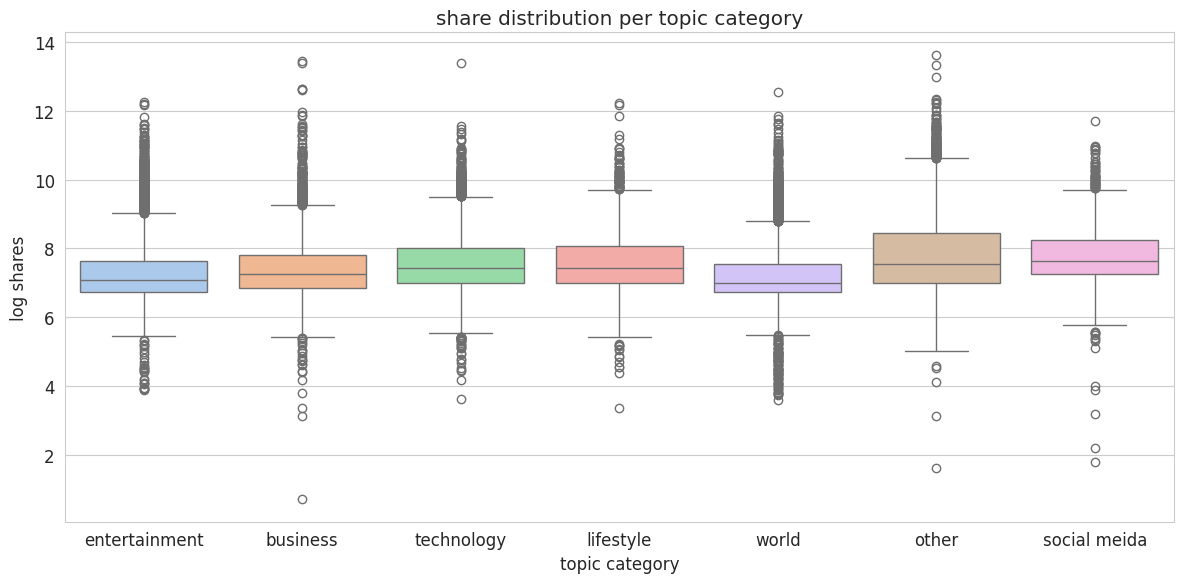

In [ ]:
dataset['category']='other'
dataset.loc[dataset['data_channel_is_lifestyle']==1,'category']= 'lifestyle'
dataset.loc[dataset['data_channel_is_entertainment']==1,'category']= 'entertainment'
dataset.loc[dataset['data_channel_is_bus']==1,'category']= 'business'
dataset.loc[dataset['data_channel_is_socmed']==1,'category']= 'social meida'
dataset.loc[dataset['data_channel_is_tech']==1,'category']= 'technology'
dataset.loc[dataset['data_channel_is_world']==1,'category']= 'world'
#created a category column

sns.boxplot(x='category',y='log_shares',data=dataset,palette='pastel')
plt.title('share distribution per topic category')
plt.xlabel('topic category')
plt.ylabel('log shares')
plt.tight_layout()
plt.savefig('share_distribution_per_topic_category.png', dpi=150, bbox_inches='tight')
plt.show()





eda is done ...feature engineering :

In [ ]:
#how much of the article is just title ?
dataset['title_word_ratio']=dataset['n_tokens_title']/ (dataset['n_tokens_content']+1)

#image per word:
dataset['img_wrd_ratio']=dataset['num_imgs']/(dataset['n_tokens_content']+1)

#keyword per word:
dataset['keyword_richness']=dataset['num_keywords']/(dataset['n_tokens_content']+1)

#content complexity:unique wrds x avg word length
dataset['content_complexity']=dataset['n_unique_tokens']*dataset['average_token_length']

#sentiment score:
dataset['sentiment_score']=dataset['global_sentiment_polarity']*dataset['global_subjectivity']

#how much does article reference to itself ?
dataset['self_refer_ratio']=dataset['num_self_hrefs']/(dataset['num_hrefs']+1)

#log title:
dataset['log_title_length']=np.log1p(dataset['n_tokens_title'])

#total media :
dataset['total_media']=dataset['num_imgs']+dataset['num_videos']


print("FEATURE ENG DONE (new col were added) ")
print("current shape:",dataset.shape)



'''we prevented (error) div by zero when added +1 .
->title_word_ratio:  clickbait detection.
->img_wrd_ratio : img richness.
->keyword density:  Search engine optimization .yes
->content_complexity : reading difficulty level.
->sentiment score: emotional effect.
->self_refer_ratio : promotion to them selves .
->log_title_length : handled skeweness.
->total_media : media richness.'''

FEATURE ENG DONE (new col were added) 
current shape: (39644, 69)


'we prevented (error) div by zero when added +1 .\n->title_word_ratio:  clickbait detection.\n->img_wrd_ratio : img richness.\n->keyword density:  Search engine optimization .yes\n->content_complexity : reading difficulty level.\n->sentiment score: emotional effect.\n->self_refer_ratio : promotion to them selves .\n->log_title_length : handled skeweness.\n->total_media : media richness.'

splitting data first (fixing the mistake)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from collections import Counter

# -----------------------------
# 1. Define X and y
# -----------------------------

drop_cols = ['shares', 'log_shares', 'category']
X = dataset.drop(columns=drop_cols, errors='ignore')

# Classification target
median_shares = dataset['shares'].median()
y_clf = (dataset['shares'] > median_shares).astype(int)


print("Median threshold:", median_shares)
print("num of popular articles:", y_clf.sum())
print("num of unpopular articles:", len(y_clf) - y_clf.sum())
print(y_clf.value_counts())


# -----------------------------
# 2. Train/test split first
# -----------------------------

X_train_raw, X_test_raw, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("Training shape:", X_train_raw.shape)
print("Testing shape:", X_test_raw.shape)

Median threshold: 1400.0
num of popular articles: 19562
num of unpopular articles: 20082
shares
0    20082
1    19562
Name: count, dtype: int64
Training shape: (31715, 66)
Testing shape: (7929, 66)


log transformation for some skewed features :

In [ ]:
# Log-transform skewed positive features
# after train/test split


skewed_cols = [
    'img_wrd_ratio',
    'n_unique_tokens',
    'n_non_stop_unique_tokens',
    'content_complexity',
    'title_word_ratio',
    'kw_max_min',
    'keyword_richness',
    'self_reference_min_shares',
    'self_reference_avg_sharess',
    'kw_avg_min'
]

X_train_raw = X_train_raw.copy()
X_test_raw = X_test_raw.copy()

for col in skewed_cols:
    if col in X_train_raw.columns:
        X_train_raw[col] = np.log1p(X_train_raw[col].clip(lower=0))
        X_test_raw[col] = np.log1p(X_test_raw[col].clip(lower=0))

feature selection using 3 methods :

corr with train only (prevent data leakage ):(m1)

In [ ]:
# Method 1: Correlation with target


train_for_corr = X_train_raw.copy()
train_for_corr['target'] = y_train_clf.values

corr_with_target = train_for_corr.corr()['target'].abs().drop('target')
corr_features = corr_with_target[corr_with_target >= 0.03].index.tolist()

print("Correlation-selected features:", len(corr_features))

Correlation-selected features: 48


RF (m2):

In [ ]:
# Method 2: Tree-based importance


rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    n_jobs=-1
)

rf_selector.fit(X_train_raw, y_train_clf)

importance = pd.Series(
    rf_selector.feature_importances_,
    index=X_train_raw.columns
).sort_values(ascending=False)

importance_features = importance[importance >= 0.005].index.tolist()

print("Tree-selected features:", len(importance_features))

Tree-selected features: 56


RFE(m3):

In [ ]:
# Method 3: RFE

rfe_model = LogisticRegression(max_iter=1000, random_state=42)

rfe = RFE(
    estimator=rfe_model,
    n_features_to_select=20
)

rfe.fit(X_train_raw, y_train_clf)

rfe_features = X_train_raw.columns[rfe.support_].tolist()

print("RFE-selected features:", len(rfe_features))

RFE-selected features: 20


voting (final features selected by at least 2methods):

In [ ]:
# Voting: keep features selected by at least 2 methods

all_features = corr_features + importance_features + rfe_features
feature_counts = Counter(all_features)

final_features = [feature for feature, count in feature_counts.items() if count >= 2]

print("Final selected features:", len(final_features))
print(final_features)

Final selected features: 48
['n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_keywords', 'data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_max_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'rate_positive_words', 'rate_negative_words', 'avg_positive_polarity', 'title_subjectivity', 'title_sentiment_polarity', 'abs_title_sentiment_polarity', 'content_complexity', 'sentiment_score', 'self_refer_ratio', 'log_title_length', 'total_media', 'img_wrd_ratio', 'min_positive_polarity', 'abs_title_subjectivity

scaling (after feature selection ):

In [ ]:
# Select final features
X_train_selected = X_train_raw[final_features].copy()
X_test_selected = X_test_raw[final_features].copy()

# Scale using training data only

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

x_train_clf = pd.DataFrame(
    X_train_scaled,
    columns=final_features,
    index=X_train_selected.index
)

x_test_clf = pd.DataFrame(
    X_test_scaled,
    columns=final_features,
    index=X_test_selected.index
)

print("Scaling done")
print("Training shape:", x_train_clf.shape)
print("Testing shape:", x_test_clf.shape)

Scaling done
Training shape: (31715, 48)
Testing shape: (7929, 48)


PCA (dimensionality reduction )


In [ ]:
from sklearn.decomposition import PCA

# Dimensionality Reduction: PCA
# fit on training data only

pca = PCA(n_components=0.95, random_state=42)

x_train_pca = pca.fit_transform(x_train_clf)
x_test_pca = pca.transform(x_test_clf)

print("Original number of features:", x_train_clf.shape[1])
print("Number of PCA components:", x_train_pca.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_.sum())

Original number of features: 48
Number of PCA components: 1
Explained variance ratio: 0.9999999708086071


to compare all model's results:

In [ ]:
results=[]

trying the pca effect on a linear model :(to compare)

PCA Logistic Regression Results
Accuracy: 0.5217555807794173
              precision    recall  f1-score   support

           0       0.52      0.88      0.65      4017
           1       0.56      0.15      0.24      3912

    accuracy                           0.52      7929
   macro avg       0.54      0.52      0.44      7929
weighted avg       0.54      0.52      0.45      7929

Training Accuracy: 0.525082768406117
Testing Accuracy: 0.5217555807794173

Detailed Report:
              precision    recall  f1-score   support

 Not Popular       0.52      0.88      0.65      4017
     Popular       0.56      0.15      0.24      3912

    accuracy                           0.52      7929
   macro avg       0.54      0.52      0.44      7929
weighted avg       0.54      0.52      0.45      7929



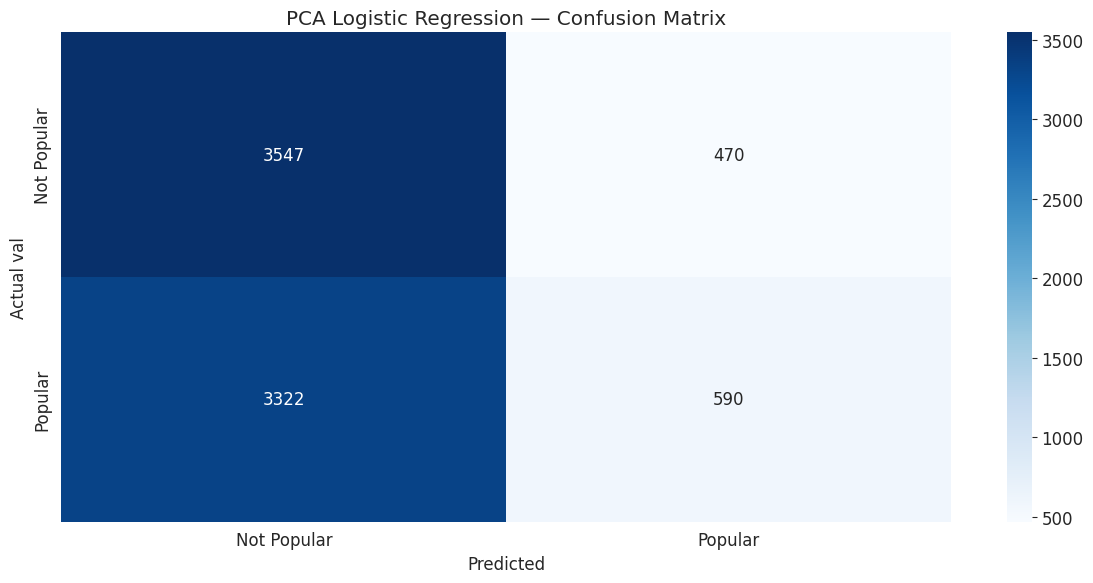

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_pca = LogisticRegression(max_iter=1000, random_state=42)
lr_pca.fit(x_train_pca, y_train_clf)

y_pred_pca = lr_pca.predict(x_test_pca)
y_prob_pca = lr_pca.predict_proba(x_test_pca)[:, 1]

print("PCA Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test_clf, y_pred_pca))

print(classification_report(y_test_clf, y_pred_pca))

Training_Accuracy= lr_pca.score(x_train_pca, y_train_clf)
Testing_Accuracy= lr_pca.score(x_test_pca, y_test_clf)
print("Training Accuracy:",Training_Accuracy )
print("Testing Accuracy:",Testing_Accuracy)
print()

print("Detailed Report:")
print(classification_report(y_test_clf, y_pred_pca,
      target_names=['Not Popular', 'Popular']))

# Clean confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_pca)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])
plt.title('PCA Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual val')
plt.tight_layout()
plt.show()

results.append({

                "model":"PCA Logistic Regression",
    "train acc" :Training_Accuracy,
    "test acc" :Testing_Accuracy

})

#didn't really help...underfitting
#If I compress my selected features into PCA components, does Logistic Regression perform better, worse, or about the same?

logistic regression (1st clf model)

Training Accuracy: 0.6365126911556046
Testing Accuracy: 0.6343801235969226

Detailed Report:
              precision    recall  f1-score   support

 Not Popular       0.64      0.64      0.64      4017
     Popular       0.63      0.62      0.63      3912

    accuracy                           0.63      7929
   macro avg       0.63      0.63      0.63      7929
weighted avg       0.63      0.63      0.63      7929



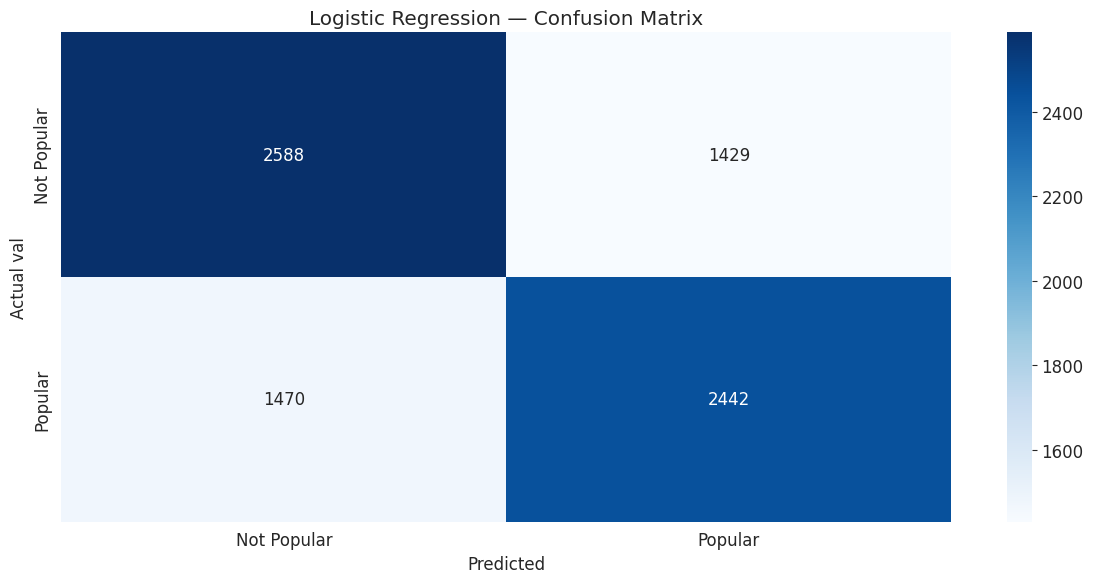

In [ ]:
#reminder:logreg calculates the 'probability ' of the article being popular (0-1),0.5 is it's threshold(default)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train and predict
lr = LogisticRegression(random_state=42, max_iter=1000)
#default maxiter is 100 ..too low (max # of attempts to find perfect wieght)
lr.fit(x_train_clf, y_train_clf)
y_pred_lr = lr.predict(x_test_clf)



Training_Accuracy= lr.score(x_train_clf, y_train_clf)
Testing_Accuracy= lr.score(x_test_clf, y_test_clf)
print("Training Accuracy:",Training_Accuracy )
print("Testing Accuracy:",Testing_Accuracy)
print()
print("Detailed Report:")
print(classification_report(y_test_clf, y_pred_lr,
      target_names=['Not Popular', 'Popular']))

# Clean confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual val')
plt.tight_layout()
plt.show()
#lowest accuracy so far:this tells that data is not linearly separable.
#no overfitting .


#annot stands for annotation..it tells seaborn to write the values inside each cell.
#fmt=d to only display numbers in integer form .

results.append({
    "model":"logestic regression",
    "train acc" :Training_Accuracy,
    "test acc" :Testing_Accuracy

})


knn(2nd clf model)

chosen k: 15
best accuracy: 0.6247950561230925


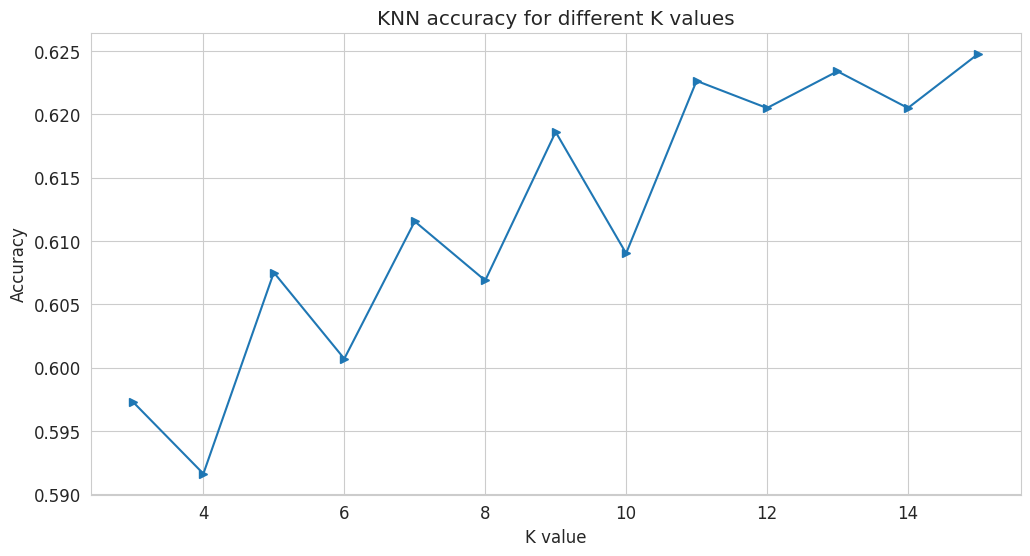

------------------------------------------------------------------------------------------
training accuracy: 0.6799306321929687
testing accuracy: 0.6247950561230925

Detailed Report:
              precision    recall  f1-score   support

 Not Popular       0.62      0.66      0.64      4017
     Popular       0.63      0.59      0.61      3912

    accuracy                           0.62      7929
   macro avg       0.63      0.62      0.62      7929
weighted avg       0.62      0.62      0.62      7929



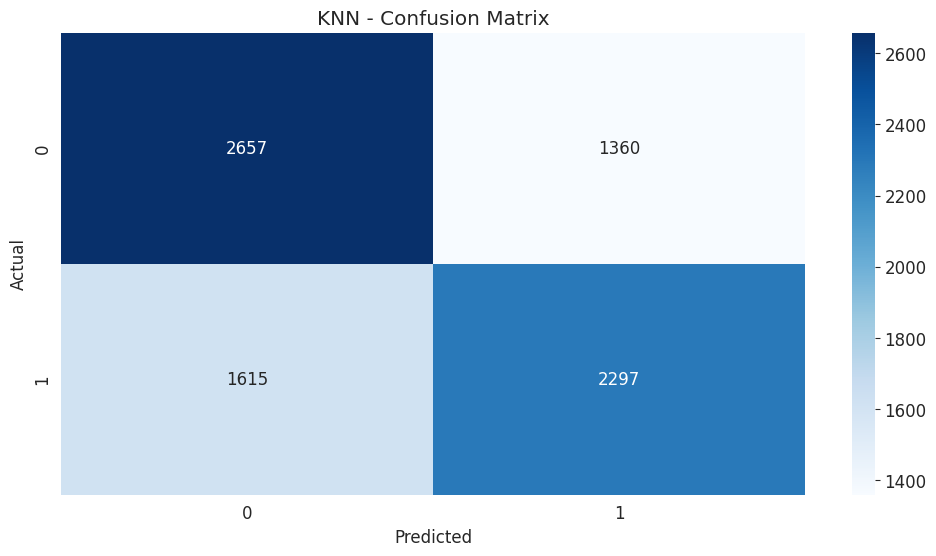

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# save accuracies
accuracies = []

# try different k values
k_values = range(3, 16)

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(x_train_clf, y_train_clf)

    accuracy = knn_temp.score(x_test_clf, y_test_clf)
    accuracies.append(accuracy)

# best accuracy -> best k
best_k = list(k_values)[accuracies.index(max(accuracies))]

print("chosen k:", best_k)
print("best accuracy:", max(accuracies))

# visualization
plt.plot(k_values, accuracies, marker='>')
plt.title("KNN accuracy for different K values")
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

print('-' * 90)

# ------------------------------------------------
# FIX: train final KNN using the best K
# ------------------------------------------------

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(x_train_clf, y_train_clf)

y_pred_knn = knn.predict(x_test_clf)

training_accuracy = knn.score(x_train_clf, y_train_clf)
testing_accuracy = knn.score(x_test_clf, y_test_clf)

print("training accuracy:", training_accuracy)
print("testing accuracy:", testing_accuracy)
print()

print("Detailed Report:")
print(classification_report(
    y_test_clf,
    y_pred_knn,
    target_names=['Not Popular', 'Popular']
))

# confusion matrix
confmat = confusion_matrix(y_test_clf, y_pred_knn)

sns.heatmap(confmat, annot=True, fmt='d', cmap='Blues')
plt.title('KNN - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


results.append({
    "model": "KNN",
    "train acc": training_accuracy,
    "test acc": testing_accuracy

})

decision tree(classification):

train acc: 0.6460349992117295
testing acc: 0.6314793794930004

Detailed Report:
              precision    recall  f1-score   support

 Not Popular       0.64      0.64      0.64      4017
     Popular       0.63      0.62      0.63      3912

    accuracy                           0.63      7929
   macro avg       0.63      0.63      0.63      7929
weighted avg       0.63      0.63      0.63      7929



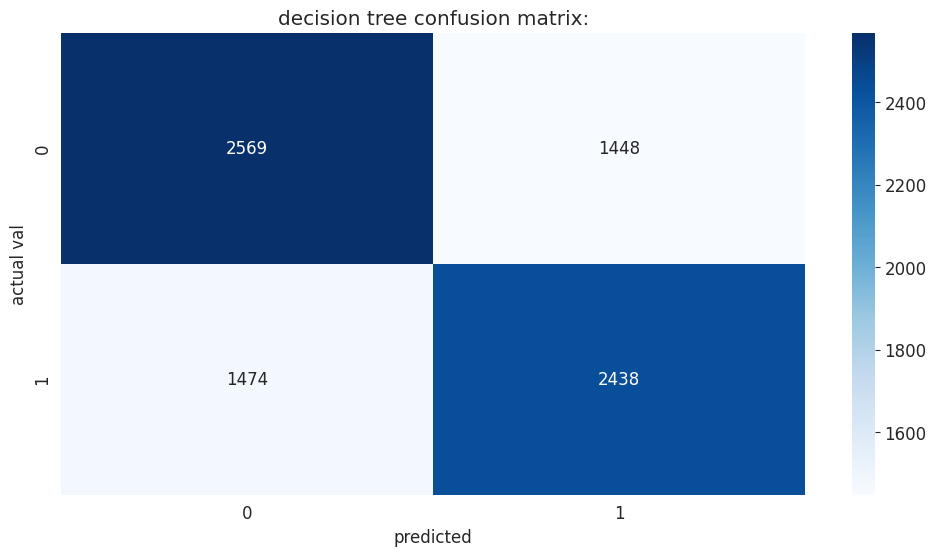

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(x_train_clf,y_train_clf)
y_pred_dt=dt.predict(x_test_clf)


train_acc=dt.score(x_train_clf,y_train_clf)
test_acc=dt.score(x_test_clf,y_test_clf)
print("train acc:",train_acc)
print("testing acc:",test_acc)
print()
print("Detailed Report:")
print(classification_report(y_test_clf, y_pred_dt,
      target_names=['Not Popular', 'Popular']))

confmat=confusion_matrix(y_test_clf,y_pred_dt)
sns.heatmap(confmat,annot=True,fmt='d',cmap="Blues")
plt.title("decision tree confusion matrix:")
plt.xlabel("predicted")
plt.ylabel("actual val")
plt.show()




results.append({
    "model":"decision tree",
    "train acc":train_acc,
    "test acc":test_acc
})

random forest

training acc: 0.7630774081664827
testing acc: 0.6651532349602725

Detailed Report:
              precision    recall  f1-score   support

 Not Popular       0.67      0.67      0.67      4017
     Popular       0.66      0.66      0.66      3912

    accuracy                           0.67      7929
   macro avg       0.67      0.67      0.67      7929
weighted avg       0.67      0.67      0.67      7929



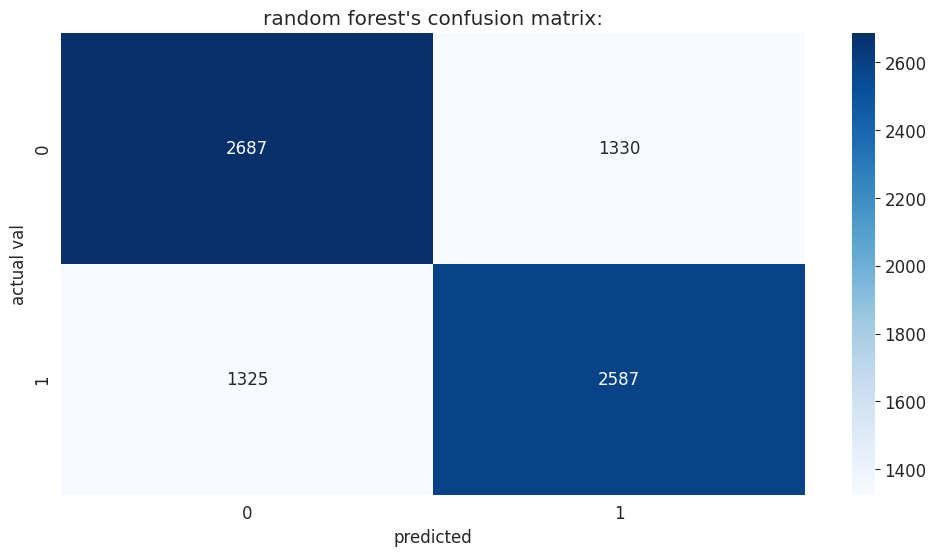

In [ ]:
from sklearn .ensemble import RandomForestClassifier
rf_clf=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=10)
rf_clf.fit(x_train_clf,y_train_clf)
y_pred_rf=rf_clf.predict(x_test_clf)

training_acc=rf_clf.score(x_train_clf,y_train_clf)
testing_acc=rf_clf.score(x_test_clf,y_test_clf)
print("training acc:",training_acc)
print("testing acc:",testing_acc)
print()
print("Detailed Report:")
print(classification_report(y_test_clf, y_pred_rf,
      target_names=['Not Popular', 'Popular']))

confmat=confusion_matrix(y_test_clf,y_pred_rf)
sns.heatmap(confmat,annot=True,fmt='d',cmap="Blues")
plt.title("random forest's confusion matrix:")
plt.xlabel("predicted")
plt.ylabel("actual val")
plt.show()

results.append({
    "model":"random forest",
    "train acc":training_acc,
    "test acc":testing_acc
})


i tried grid search but it didn't really make a change or improve the score so i deleted it (running time became extremly long)



randomized search

Best parameters {'max_depth': 16, 'min_samples_split': 4, 'n_estimators': 239}
Best cv accuracy: 0.6655527191536551
train acc:  0.9546902096799622
test acc:  0.6627569680918148

Detailed Report:
              precision    recall  f1-score   support

 Not Popular       0.67      0.66      0.67      4017
     Popular       0.66      0.66      0.66      3912

    accuracy                           0.66      7929
   macro avg       0.66      0.66      0.66      7929
weighted avg       0.66      0.66      0.66      7929



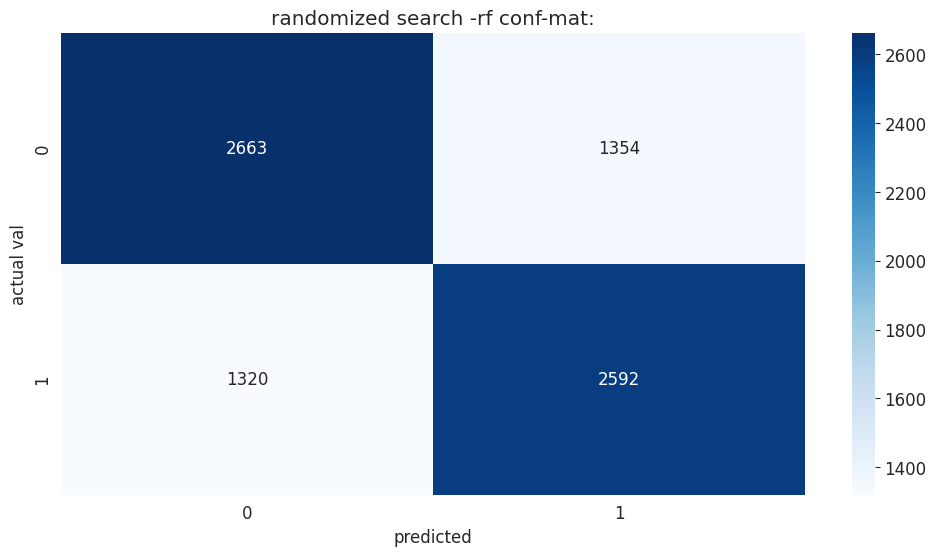

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist={
    'n_estimators':randint(50,300),
    #n of trees
    'max_depth':randint(5,20),
    'min_samples_split':randint(2,15)
}
random_search=RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
random_search.fit(x_train_clf,y_train_clf)
print("Best parameters",random_search.best_params_)
print("Best cv accuracy:",random_search.best_score_)

train_acc=random_search.best_estimator_.score(x_train_clf,y_train_clf)
test_acc=random_search.best_estimator_.score(x_test_clf,y_test_clf)
print("train acc: ",train_acc)
print("test acc: ",test_acc)
print()
print("Detailed Report:")
best_rf = random_search.best_estimator_
y_pred_random_rf = best_rf.predict(x_test_clf)

print(classification_report(y_test_clf, y_pred_random_rf,
      target_names=['Not Popular', 'Popular']))

confmat = confusion_matrix(y_test_clf, y_pred_random_rf)
sns.heatmap(confmat,annot=True,fmt='d',cmap="Blues")
plt.title("randomized search -rf conf-mat:")
plt.xlabel("predicted")
plt.ylabel("actual val")
plt.show()


results.append({
    "model":"randomized search rf",
    "train acc":train_acc,
    "test acc":test_acc
})

choosing best model out of (random search,randomized for rf)

In [ ]:
basic_rf_acc = rf_clf.score(x_test_clf, y_test_clf)
#grid_acc=grid_search.best_estimator_.score(x_test_clf,y_test_clf)
random_acc=random_search.best_estimator_.score(x_test_clf,y_test_clf)

print("Basic RF test accuracy:",basic_rf_acc)
#print("grid search tst acc:",grid_acc)
print("randomized search tst acc:",random_acc)

#best_acc=max(basic_rf_acc,grid_acc,random_acc)
best_acc=max(basic_rf_acc,random_acc)

if best_acc==random_acc:
  best_rf=random_search.best_estimator_
else:
  best_rf=rf_clf
print("best model: ",best_rf)
print("best rf acc: ",best_acc)


# if best_acc==basic_rf_acc:
#   best_rf=rf_clf
# elif best_acc==grid_acc:
#   best_rf=grid_search.best_estimator_
# else:
#   best_rf=random_search.best_estimator_
# print("best model: ",best_rf)
# print("best rf acc: ",best_acc)

#removed grid search ...running time is unbelievable

Basic RF test accuracy: 0.6651532349602725
randomized search tst acc: 0.6627569680918148
best model:  RandomForestClassifier(max_depth=10, random_state=42)
best rf acc:  0.6651532349602725


svm:(rbf kernel)..but with samples

train acc: 0.5248
test acc: 0.5215033421616849

classification report:               precision    recall  f1-score   support

 not_popular       0.52      0.88      0.65      4017
     popular       0.56      0.15      0.24      3912

    accuracy                           0.52      7929
   macro avg       0.54      0.52      0.44      7929
weighted avg       0.54      0.52      0.45      7929



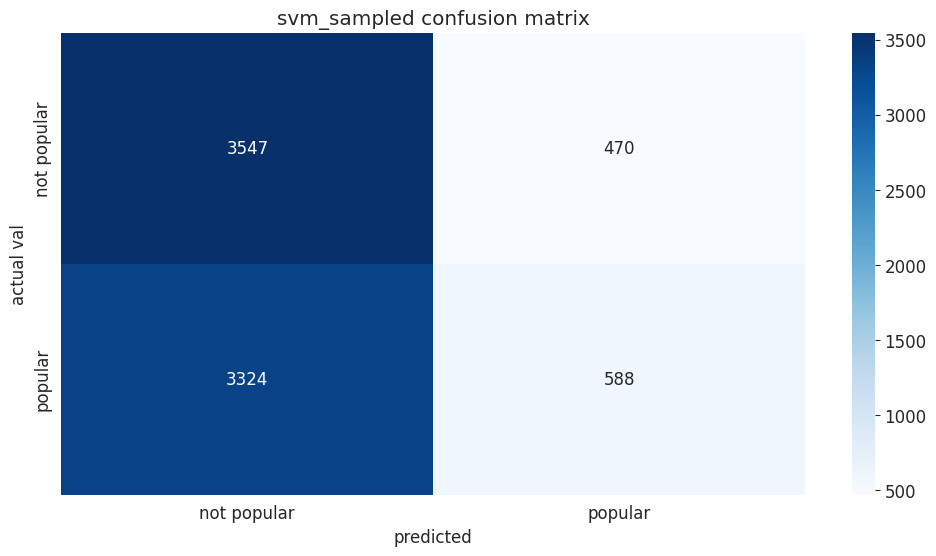

In [ ]:
from sklearn.svm import SVC
# from sklearn.utils  import resample
# x_sample,y_sample=resample(x_train_clf,y_train_clf,
#                            n_samples=6000,random_state=42)
#using stratification instead of only small sampels to try to fix the underfitting result.

from sklearn.model_selection import train_test_split
x_sample,_,y_sample,_=train_test_split(x_train_clf,y_train_clf,
                                       train_size=10000,stratify=y_train_clf,random_state=42)#to ensure balanced classes/:

svm_sampled=SVC(kernel='rbf',cache_size=1000,C=10,gamma='scale',random_state=42,probability =True)
#sample 5000-8000 instead of 100000.
svm_sampled.fit(x_sample,y_sample)
y_pred_svm2=svm_sampled.predict(x_test_clf)

train_acc=svm_sampled.score(x_sample,y_sample)
test_acc=svm_sampled.score(x_test_clf,y_test_clf)
print("train acc:",train_acc)
print("test acc:",test_acc)
print()
print("classification report:",
      classification_report(y_test_clf,y_pred_svm2,
      target_names=['not_popular','popular']))

confmat=confusion_matrix(y_test_clf,y_pred_svm2)
sns.heatmap(confmat,annot=True, fmt='d',cmap="Blues",
            xticklabels=['not popular','popular'],
            yticklabels=['not popular','popular'])
plt.title('svm_sampled confusion matrix')
plt.xlabel('predicted')
plt.ylabel('actual val')
plt.show()
results.append({
    "model":"SVC rbf sampled",
    "train acc":train_acc,
    "test acc":test_acc
})
#tried the samples solution as suggested ..didn't realy decrease the running time significantly ,the score didn't drop or change:(0.50,0.51).(underfitting)

linear svc

TRAINING ACC: 0.6255399653160965
TESTING ACC: 0.6218943120191701

              precision    recall  f1-score   support

 Not Popular       0.63      0.63      0.63      4017
     Popular       0.62      0.61      0.62      3912

    accuracy                           0.62      7929
   macro avg       0.62      0.62      0.62      7929
weighted avg       0.62      0.62      0.62      7929



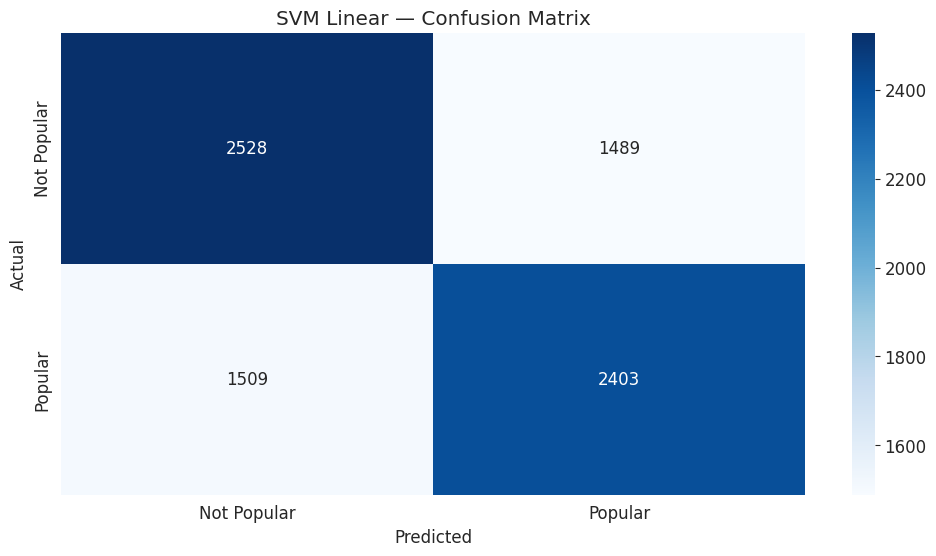

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

#used this because linearsvc is way faster than svc(kernel='linear)
svm_linear=CalibratedClassifierCV(LinearSVC(C=0.1,max_iter=2000,random_state=42))
# CalibratedClassifierCV wrapper is needed because LinearSVC has no predict_proba (needed for ROC later)

svm_linear.fit(x_train_clf,y_train_clf)
#this method is supposed to be fast enough on full data(no sampling ).
y_pred_svm_lin=svm_linear.predict(x_test_clf)
train_acc = svm_linear.score(x_train_clf, y_train_clf)
test_acc = svm_linear.score(x_test_clf, y_test_clf)

print("TRAINING ACC:", train_acc)
print("TESTING ACC:", test_acc)
print()
print(classification_report(y_test_clf, y_pred_svm_lin,
      target_names=['Not Popular', 'Popular']))

cm = confusion_matrix(y_test_clf, y_pred_svm_lin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])
plt.title('SVM Linear — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

results.append({
    "model": "SVC linear",
    "train acc": train_acc,
    "test acc": test_acc
})


XGBoost:(extreme gradient boosting)

train acc: 0.6818540122970204
test acc: 0.6659099508134695

classification report:               precision    recall  f1-score   support

 Not Popular       0.67      0.68      0.67      4017
     Popular       0.66      0.65      0.66      3912

    accuracy                           0.67      7929
   macro avg       0.67      0.67      0.67      7929
weighted avg       0.67      0.67      0.67      7929



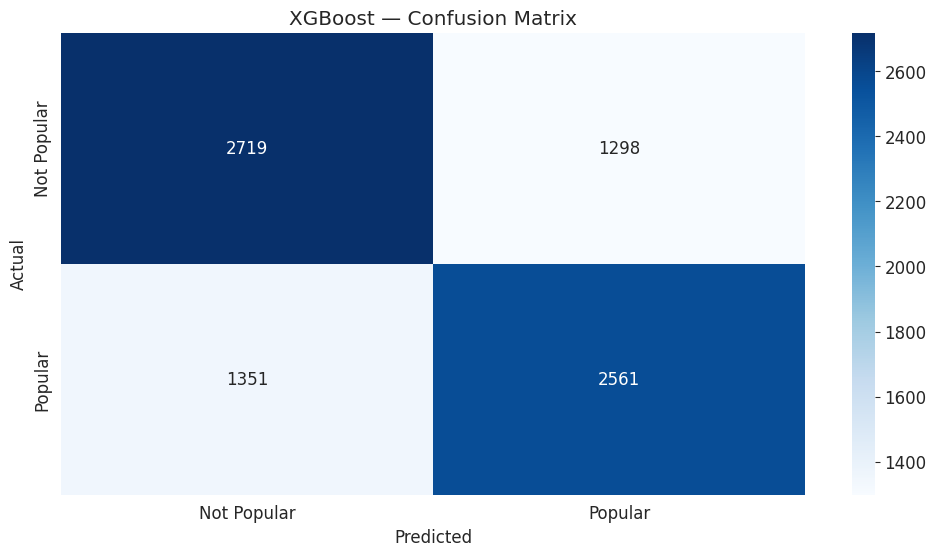

In [ ]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=100,max_depth=3,
                  learning_rate=0.1,tree_method='hist',random_state=42,n_jobs=-1,
                  eval_metric='logloss')
#learning rate=how much each new tree contributes,smaller->better generalization .
#eval_metric=uesd during training ,how wrong predicted probabilities are ,smaller->better .
#
xgb.fit(x_train_clf,y_train_clf)
y_pred_xgb=xgb.predict(x_test_clf)

train_acc=xgb.score(x_train_clf,y_train_clf)
test_acc=xgb.score(x_test_clf,y_test_clf)
print("train acc:",train_acc)
print("test acc:",test_acc)
print()
print("classification report:",classification_report(y_test_clf,y_pred_xgb,
                              target_names=['Not Popular', 'Popular']))
conmat=confusion_matrix(y_test_clf,y_pred_xgb)
sns.heatmap(conmat,annot=True,fmt='d',cmap="Blues",
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])
plt.title('XGBoost — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

results.append({
    "model":"XGBoost",
    "train acc":train_acc,
    "test acc":test_acc
})

ROC curve

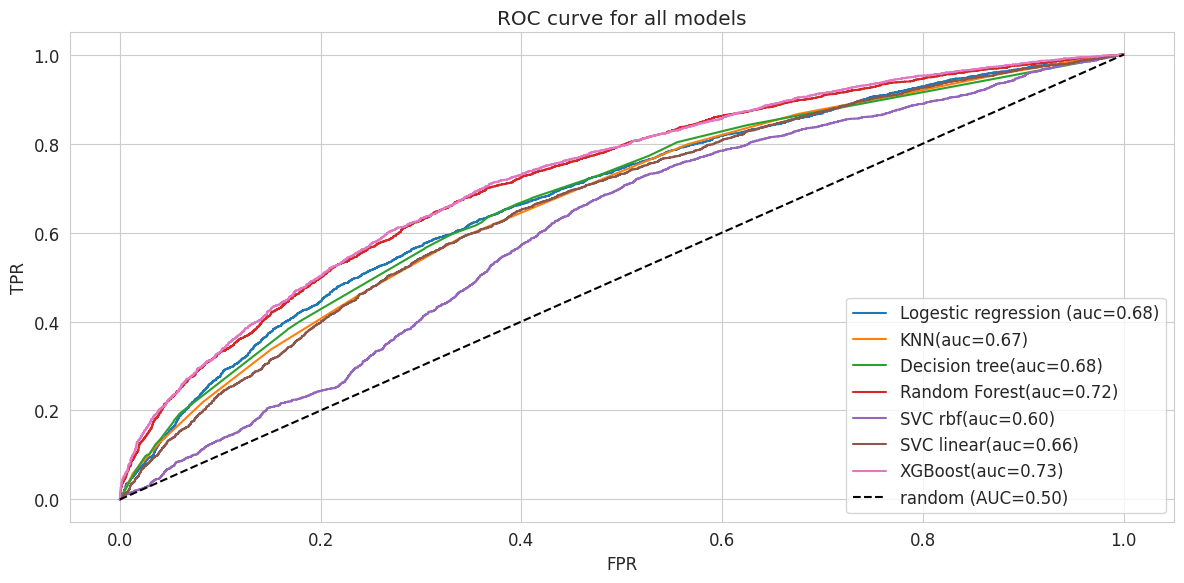

In [ ]:
from re import L
from sklearn.metrics import roc_curve ,auc
models={
    "Logestic regression ":lr,
    "KNN":knn,
    "Decision tree":dt,
    "Random Forest":best_rf,
    "SVC rbf":svm_sampled,
    "SVC linear":svm_linear,
    "XGBoost":xgb
}
#plotting roc for eacg model:
for name ,model in models.items():
  #probability prediction:
   y_proba=model.predict_proba(x_test_clf)[:,1]
  #instead of 0,1 ...we want a probability ,[:,1]-> to only get the popular class for roc .(so roc can test every possible threshold)

  #calculating roc curve points
   fpr,tpr,_=roc_curve(y_test_clf,y_proba)
  #calculates auc:
   roc_auc=auc(fpr,tpr)
   plt.plot(fpr,tpr,label=f"{name}(auc={roc_auc:.2f})")
  #any model above this line is better than random guessing :(this represents the random guessing )
plt.plot([0,1],[0,1],'k--',label='random (AUC=0.50)')

plt.title('ROC curve for all models')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()






In [ ]:
#the results dataframe (to compare outputs ):
results_df=pd.DataFrame(results)
print(results_df)

                     model  train acc  test acc
0  PCA Logistic Regression   0.525083  0.521756
1      logestic regression   0.636513  0.634380
2                      KNN   0.679931  0.624795
3            decision tree   0.646035  0.631479
4            random forest   0.763077  0.665153
5     randomized search rf   0.954690  0.662757
6          SVC rbf sampled   0.524800  0.521503
7               SVC linear   0.625540  0.621894
8                  XGBoost   0.681854  0.665910


precision recall-curve

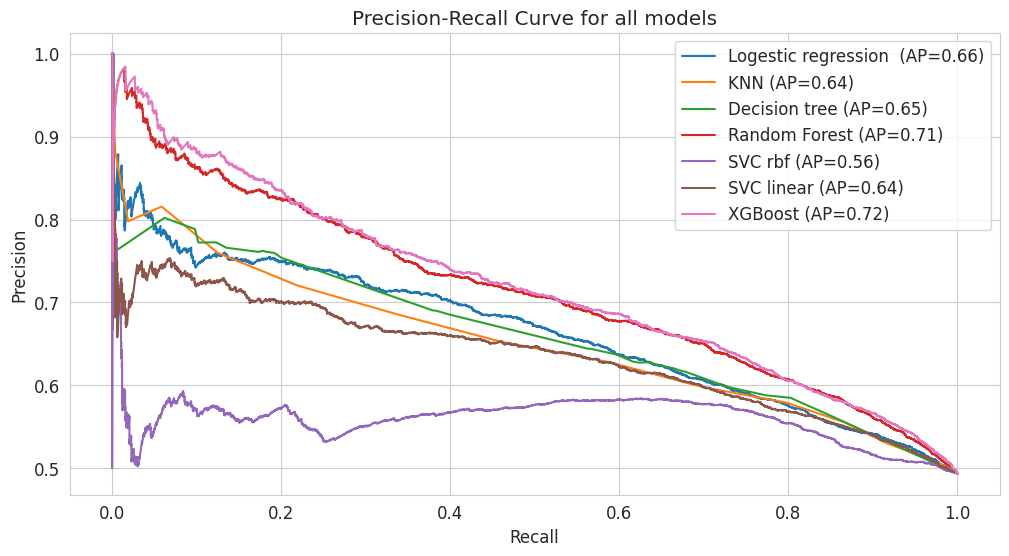

"precision :When I say it's popular, how often am I right?\nrecall:Of all truly popular articles, how many did I find?\n\nSimple example — 100 popular articles exist, your model flags 80 as popular:\n60 of those 80 are actually popular → Precision = 60/80 = 75%\nbut you missed 40 real ones → Recall = 60/100 = 60%"

In [ ]:
from sklearn.metrics import precision_recall_curve,average_precision_score

models_proba={
      "Logestic regression ":(lr,x_test_clf),
    "KNN":(knn,x_test_clf),
    "Decision tree":(dt,x_test_clf),
    "Random Forest":(best_rf,x_test_clf),
    "SVC rbf":(svm_sampled,x_test_clf),
    "SVC linear":(svm_linear,x_test_clf),
    "XGBoost":(xgb,x_test_clf)

}
for name,(model,x_test) in models_proba.items():
  proba=model.predict_proba(x_test_clf)[:,1]
  #shows probability of predicting popular .
  precision,recall,_=precision_recall_curve(y_test_clf,proba)
  #tests every possible threshold &calculates precesion and recall at each .
  average_precision=average_precision_score(y_test_clf,proba)
  #summarize each model's curve into whole number ...higher better .
  plt.plot(recall,precision,label=f"{name} (AP={average_precision:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for all models")
plt.legend(loc="upper right")
plt.show()

#remember :
'''precision :When I say it's popular, how often am I right?
recall:Of all truly popular articles, how many did I find?

Simple example — 100 popular articles exist, your model flags 80 as popular:
60 of those 80 are actually popular → Precision = 60/80 = 75%
but you missed 40 real ones → Recall = 60/100 = 60%'''

calibration curve :معايرة

Logestic regression  Brier Score: 0.2253
KNN Brier Score: 0.2320
Decision tree Brier Score: 0.2258
Random Forest Brier Score: 0.2142
SVC rbf Brier Score: 0.2494
SVC linear Brier Score: 0.2305
XGBoost Brier Score: 0.2112


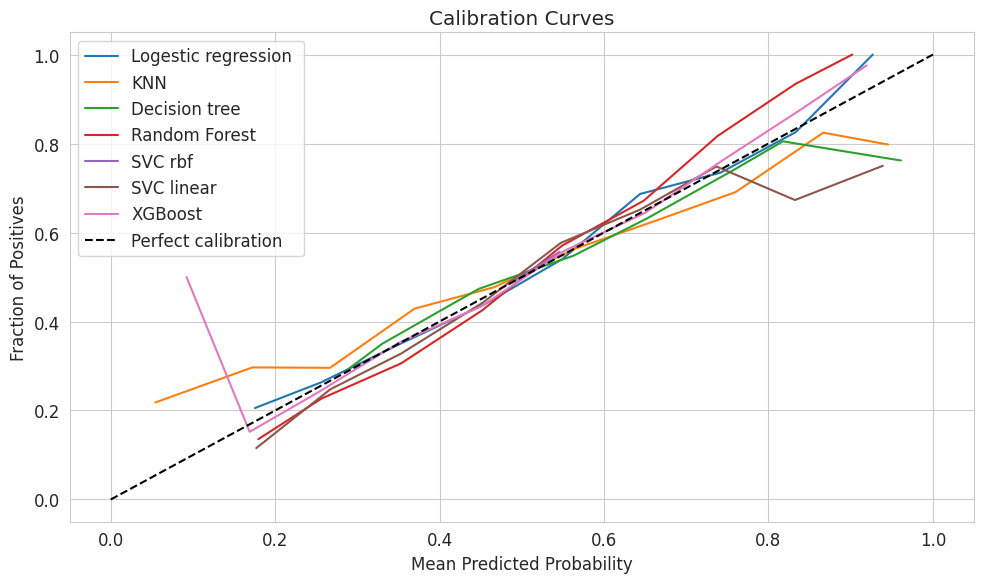

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

plt.figure(figsize=(10, 6))

for name, (model, x_test) in models_proba.items():
    proba = model.predict_proba(x_test_clf)[:, 1]
    #splits predictions into 10 groups,for each group checks:when the model predicted ~70% probability, were actually 70% of those articles popular? If yes → well calibrated
    fraction_of_positives, mean_predicted_value = calibration_curve(y_test_clf, proba, n_bins=10)

    plt.plot(mean_predicted_value, fraction_of_positives, label=name)

    bs = brier_score_loss(y_test_clf, proba)
    #almost :average squared error between predicted probability and actual outcome.(lower= better),perfect model = 0, random guessing ≈ 0.25.
    #xgboost has the least brier score of them (confirms my choice of it as the best clf model)
    print(f"{name} Brier Score: {bs:.4f}")

plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
#plts the diagonal dashed line (perfect calibration)
plt.title('Calibration Curves')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

learning curves

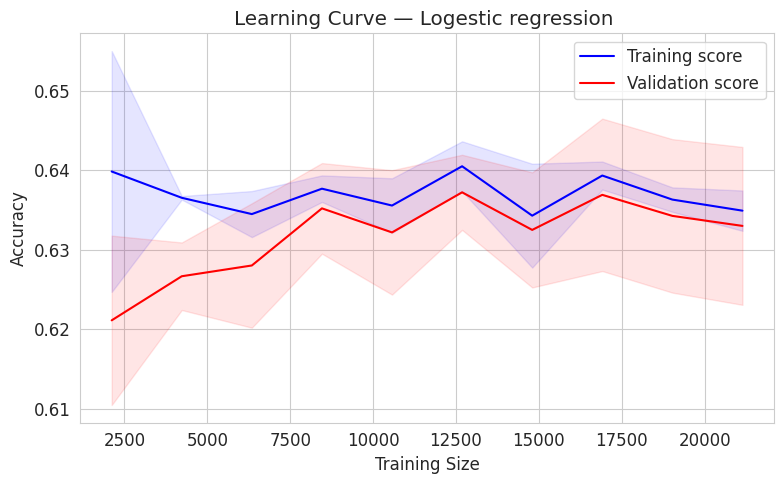

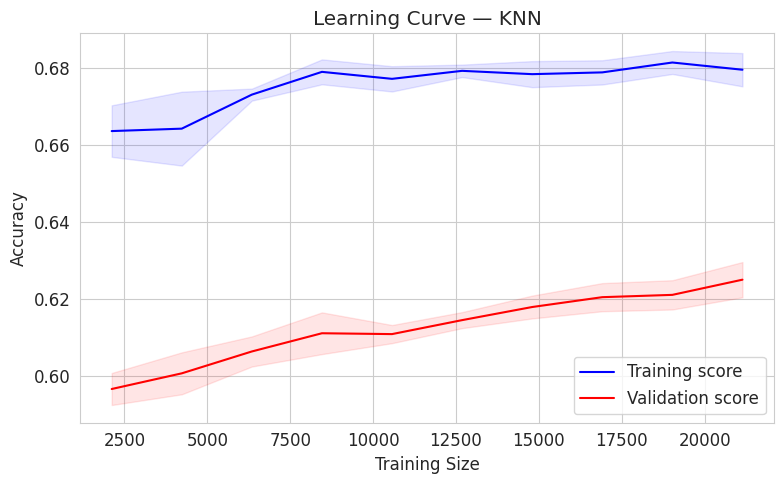

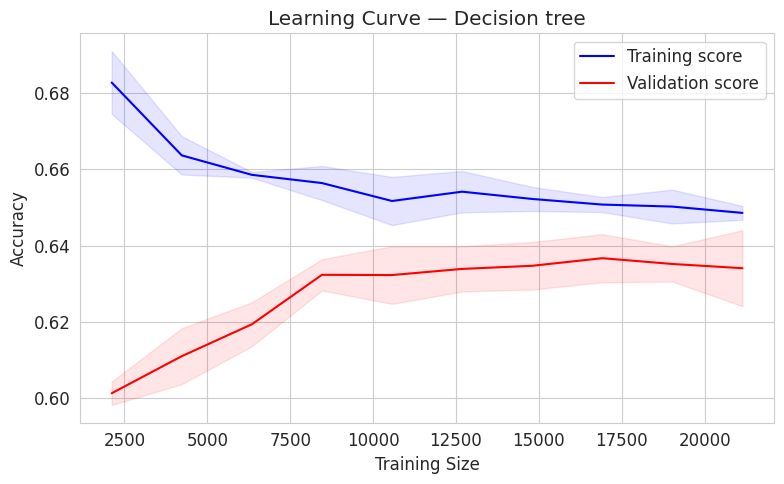

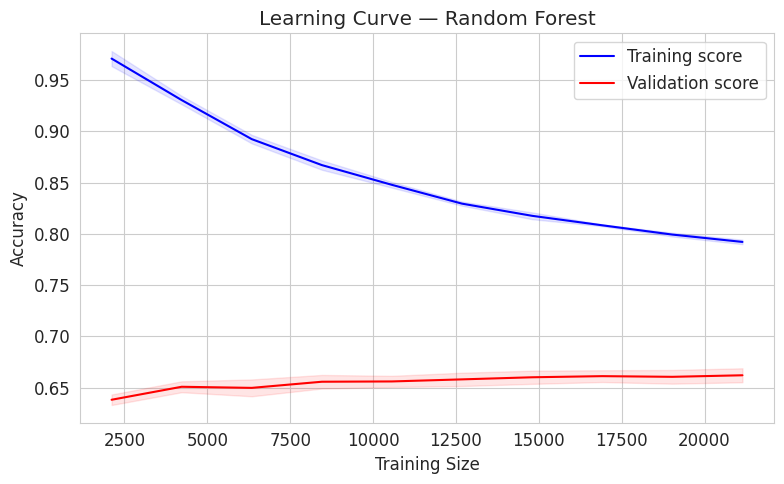

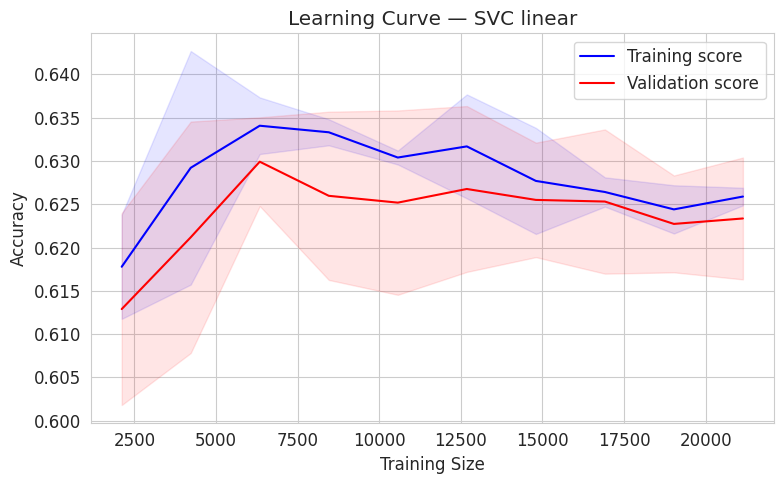

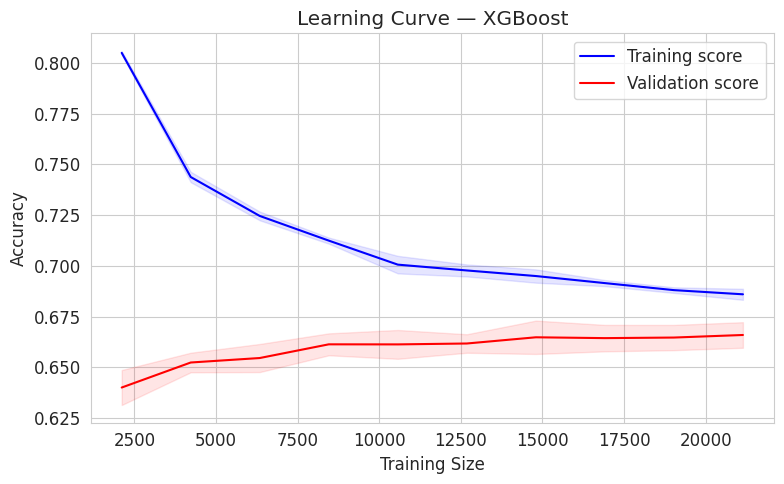

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, name, x, y):
    train_sizes, train_scores, val_scores = learning_curve(
        model, x, y,
        cv=3,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )
    #Trains the model 10 times — starting with 10% of data, then 20%, 30%... up to 100%. At each size it uses 3-fold CV and records training and validation accuracy.

    train_mean = train_scores.mean(axis=1)
    #Averages the 3 CV scores at each training size into one number.(validation)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, label='Training score', color='blue')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    #The shaded area around each line shows the uncertainty/variance across the 3 folds.
    plt.plot(train_sizes, val_mean, label='Validation score', color='red')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')

    plt.title(f'Learning Curve — {name}')
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'learning_curve_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

# plot for each model
skip = ['SVC rbf']
#it's my worse model &will take forever to run so i skipped it
for name, (model, _) in models_proba.items():
    if name in skip:
        continue
    plot_learning_curve(model, name, x_train_clf, y_train_clf)

shap:

In [ ]:
!pip install shap

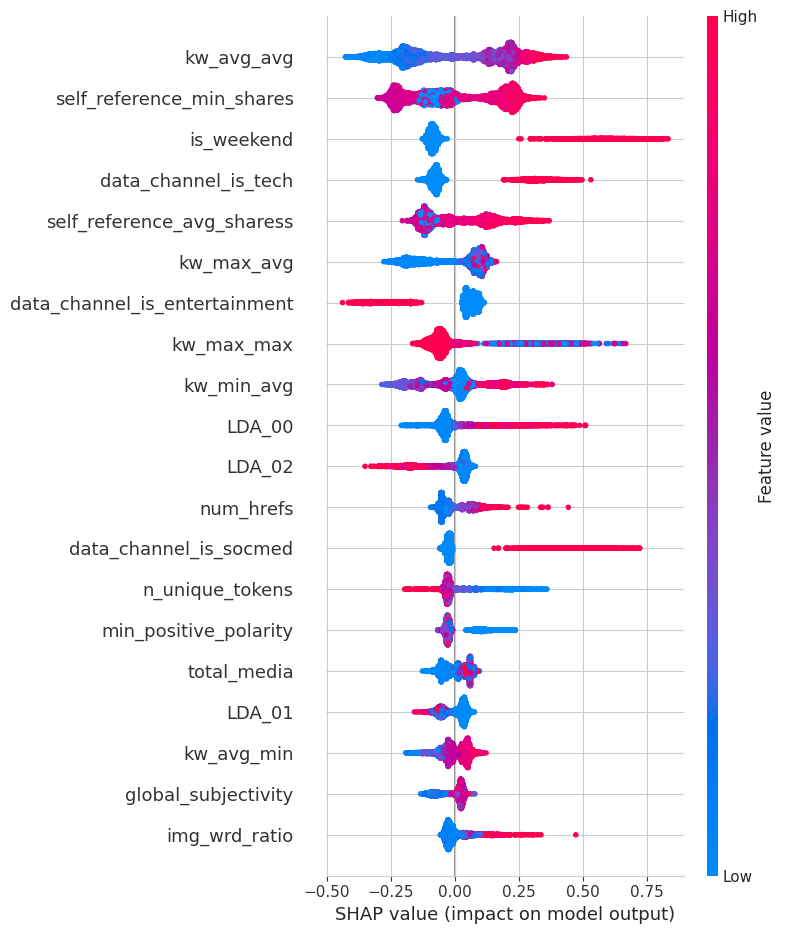

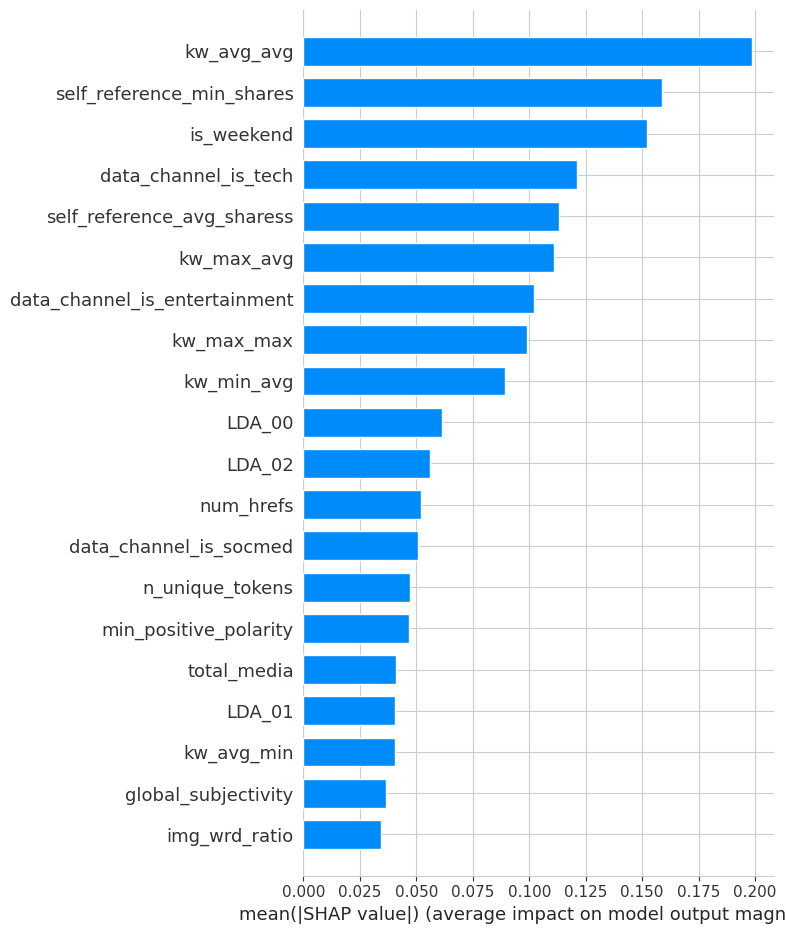

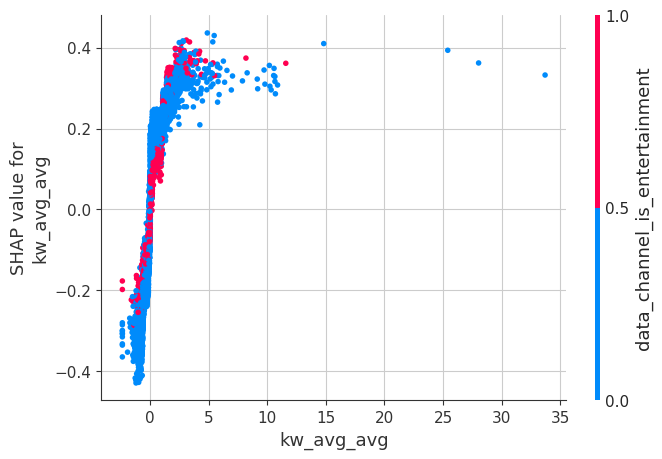

In [ ]:
import shap

# used XGBoost as my best model
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(x_test_clf)

# 1. Summary Plot
shap.summary_plot(shap_values, x_test_clf, feature_names=final_features)

# 2. Feature Importance Plot (bar)
shap.summary_plot(shap_values, x_test_clf, plot_type='bar', feature_names=final_features)

# 3. Dependence Plot (top feature)
top_feature = x_test_clf.columns[np.abs(shap_values).mean(axis=0).argmax()]
shap.dependence_plot(top_feature, shap_values, x_test_clf)

what happens when i train my model on less data ?:(robustness/stress testing)

training size10%: accuracy=0.6512
training size30%: accuracy=0.6659
training size50%: accuracy=0.6640
training size99%: accuracy=0.6660


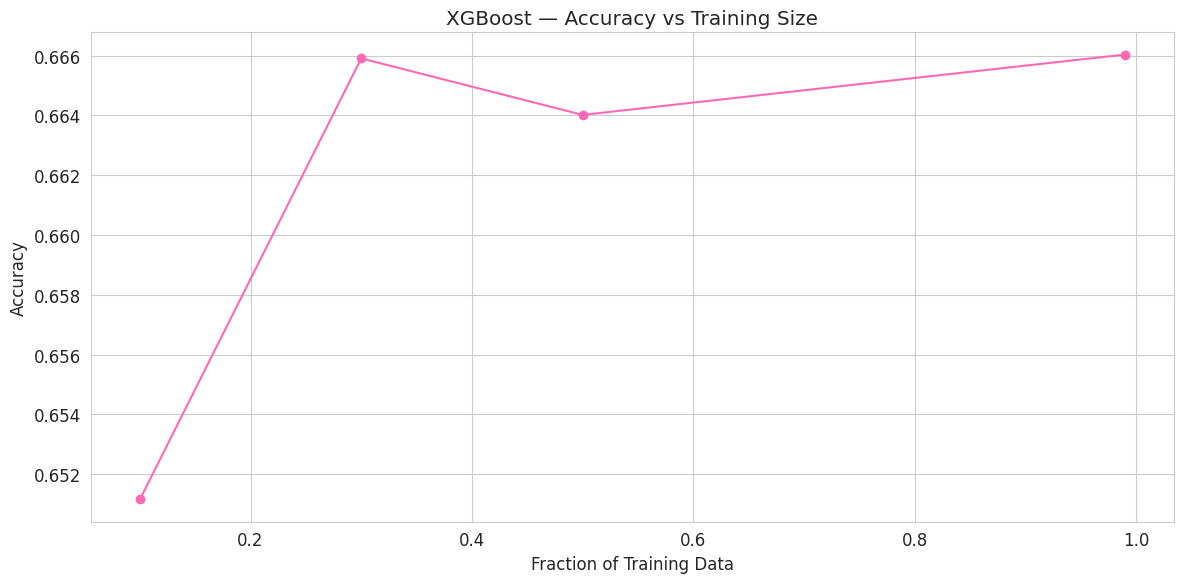

In [ ]:
from sklearn.metrics import accuracy_score

fractions=[0.1,0.3,0.5,0.99]
results_robustness =[]

for frac in fractions :
    x_frac,_,y_frac,_ = train_test_split(
    x_train_clf,y_train_clf,
    train_size=frac,
    random_state=42
)
#randomly picking a fraction of my training(only train) data.

#testing on my "best model" ,xgboost:
    xgb_temp=XGBClassifier(n_estimator=100,max_depth=3,learning_rate=0.1,tree_method='hist',random_state=42,n_jobs=-1,eval_metric='logloss')
    xgb_temp.fit(x_frac,y_frac)
    acc=accuracy_score(y_test_clf,xgb_temp.predict(x_test_clf))
     #test it on the full test set every time,same test set, only training size changes,this makes the comparison fair.
    results_robustness.append({
    "fraction of training data":frac,
    "test accuracy":acc
    })
    print(f"training size{int(frac*100)}%: accuracy={acc:.4f}")

#plotting

# The current results_robustness list has keys 'fraction of training data' and 'test accuracy'
# The plotting section is trying to access 'fraction' and 'accuracy'
# I'll update the plotting code to match the keys in results_robustness.
fracs=[r['fraction of training data'] for r in results_robustness]
accs=[r['test accuracy'] for r in results_robustness]
#extracts the fractions and accuracies from the results list into two separate lists for plotting.
plt.plot(fracs,accs,marker='o',color='hotpink')
plt.title('XGBoost — Accuracy vs Training Size')
plt.xlabel('Fraction of Training Data')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.savefig('robustness_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

Task B  Setup


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dataset = dataset.copy()
y_reg = dataset['log_shares']
X_reg = dataset.drop(columns=['shares', 'log_shares', 'category'], errors='ignore')

X_train_reg_raw, X_test_reg_raw, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

X_train_reg_raw = X_train_reg_raw.copy()
X_test_reg_raw  = X_test_reg_raw.copy()

skewed_cols = [
    'img_wrd_ratio', 'n_unique_tokens', 'n_non_stop_unique_tokens',
    'content_complexity', 'title_word_ratio', 'kw_max_min',
    'keyword_richness', 'self_reference_min_shares',
    'self_reference_avg_sharess', 'kw_avg_min'
]

for col in skewed_cols:
    if col in X_train_reg_raw.columns:
        X_train_reg_raw[col] = np.log1p(X_train_reg_raw[col].clip(lower=0))
        X_test_reg_raw[col]  = np.log1p(X_test_reg_raw[col].clip(lower=0))

X_train_reg_raw = X_train_reg_raw.fillna(X_train_reg_raw.median())
X_test_reg_raw  = X_test_reg_raw.fillna(X_train_reg_raw.median())

X_train_reg_sel = X_train_reg_raw[final_features].copy()
X_test_reg_sel  = X_test_reg_raw[final_features].copy()

scaler_reg = RobustScaler()
X_train_reg_sc = scaler_reg.fit_transform(X_train_reg_sel)
X_test_reg_sc  = scaler_reg.transform(X_test_reg_sel)

x_train = pd.DataFrame(X_train_reg_sc, columns=final_features, index=X_train_reg_sel.index)
x_test  = pd.DataFrame(X_test_reg_sc,  columns=final_features, index=X_test_reg_sel.index)

n = len(y_test_reg)
p = x_test.shape[1]

regression_results = []

print("Regression setup :")
print("Training shape:", x_train.shape)
print("Testing  shape:", x_test.shape)
print("Target   shape:", y_train_reg.shape)

Regression setup :
Training shape: (31715, 48)
Testing  shape: (7929, 48)
Target   shape: (31715,)


Linear Regression


Linear Regression :

Training R²:  0.1308
Testing R²:   0.1360
Train RMSE:   0.8676
Test RMSE:    0.8606
MAE:          0.6428
MSE:          0.7406
Adj R²:       0.1308
gap:         -0.0053


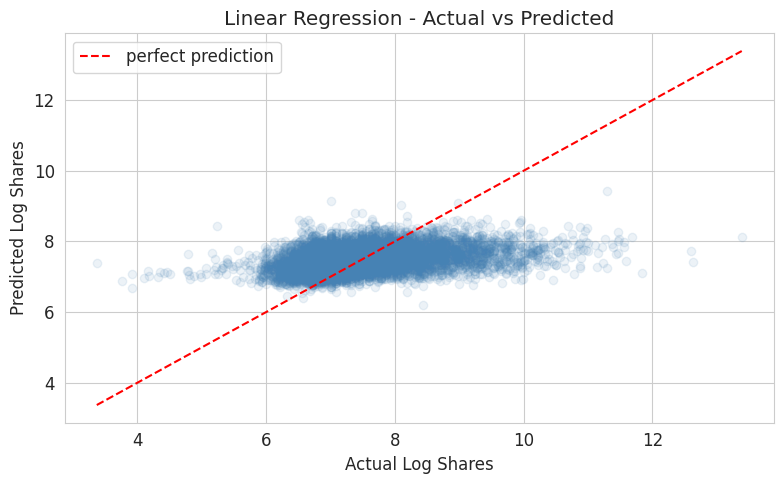

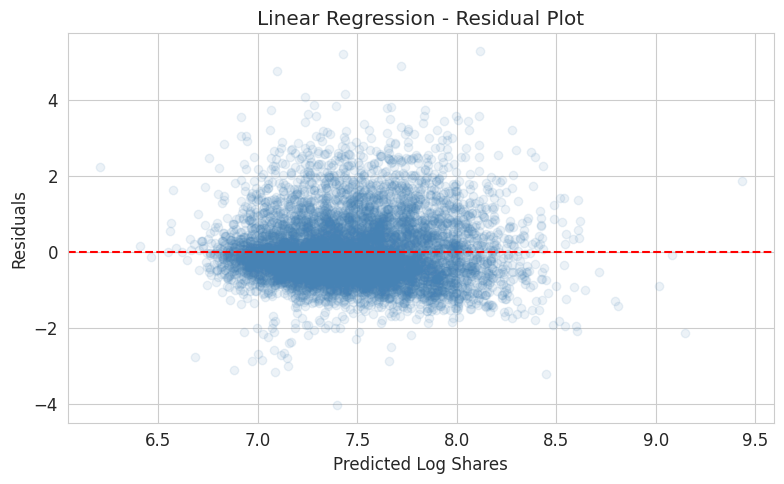

In [ ]:
from sklearn.linear_model import LinearRegression

lr_reg = LinearRegression()
lr_reg.fit(x_train, y_train_reg)

y_pred_lr_reg = lr_reg.predict(x_test)
y_pred_lr_reg_train = lr_reg.predict(x_train)

Training_R2 = r2_score(y_train_reg, y_pred_lr_reg_train)
Testing_R2 = r2_score(y_test_reg,  y_pred_lr_reg)
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_pred_lr_reg_train))
test_rmse = np.sqrt(mean_squared_error(y_test_reg,  y_pred_lr_reg))
mae = mean_absolute_error(y_test_reg, y_pred_lr_reg)
mse = mean_squared_error(y_test_reg,  y_pred_lr_reg)
adj_r2 = 1 - (1 - Testing_R2) * (n - 1) / (n - p - 1)

print("Linear Regression :\n")
print(f"Training R²:  {Training_R2:.4f}")
print(f"Testing R²:   {Testing_R2:.4f}")
print(f"Train RMSE:   {train_rmse:.4f}")
print(f"Test RMSE:    {test_rmse:.4f}")
print(f"MAE:          {mae:.4f}")
print(f"MSE:          {mse:.4f}")
print(f"Adj R²:       {adj_r2:.4f}")

gap = Training_R2 - Testing_R2
print(f"gap:         {gap:.4f}")

if gap > 0.1:
    print("Warning:     overfitting")
elif Training_R2 < 0.3:
    print("Warning:     underfitting - model is too simple for this data")
else:
    print("Model:       Best Balance:")

plt.figure(figsize=(8,5))
plt.scatter(y_test_reg, y_pred_lr_reg, alpha=0.1, color='steelblue')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'r--', label='perfect prediction')
plt.title('Linear Regression - Actual vs Predicted')
plt.xlabel('Actual Log Shares')
plt.ylabel('Predicted Log Shares')
plt.legend()
plt.tight_layout()
plt.savefig('lr_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

residuals_lr = y_test_reg - y_pred_lr_reg
plt.figure(figsize=(8,5))
plt.scatter(y_pred_lr_reg, residuals_lr, alpha=0.1, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Linear Regression - Residual Plot')
plt.xlabel('Predicted Log Shares')
plt.ylabel('Residuals')
plt.tight_layout()
plt.savefig('lr_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

regression_results.append({
    "model":    "Linear Regression",
    "train r2": Training_R2,
    "test r2":  Testing_R2,
    "mae":      mae,
    "rmse":     test_rmse,
    "mse":     mse,
    "adj r2":   adj_r2
})

Ridge Regression


Ridge Regression :

Training R²: 0.1308
Testing R²:  0.1360
Train RMSE:  0.8676
Test RMSE:   0.8606
MAE:         0.6428
Adj R²:      0.1307


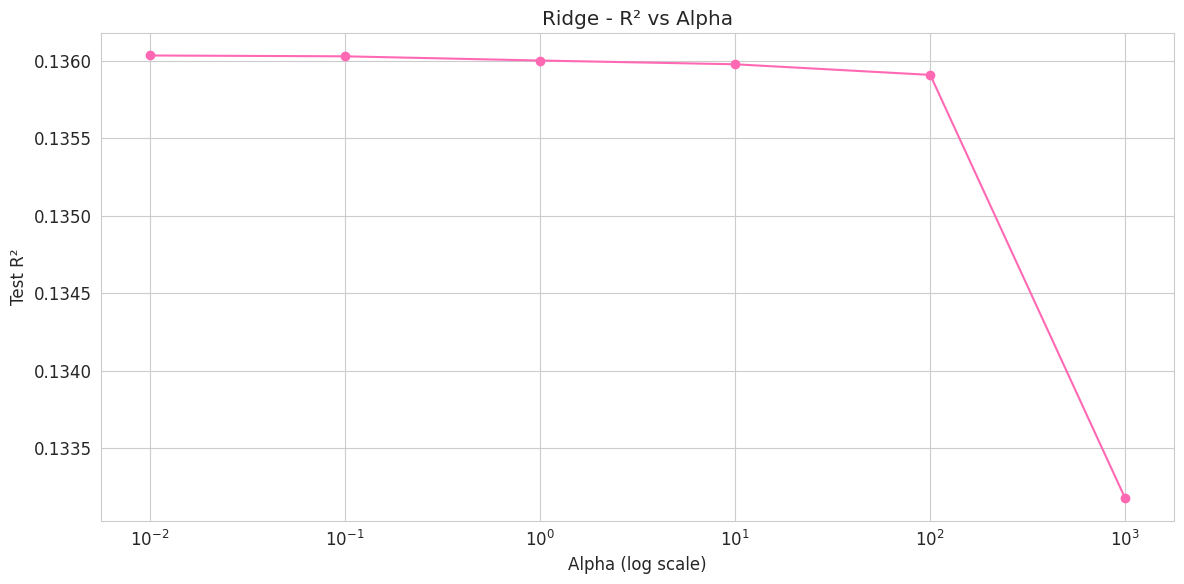

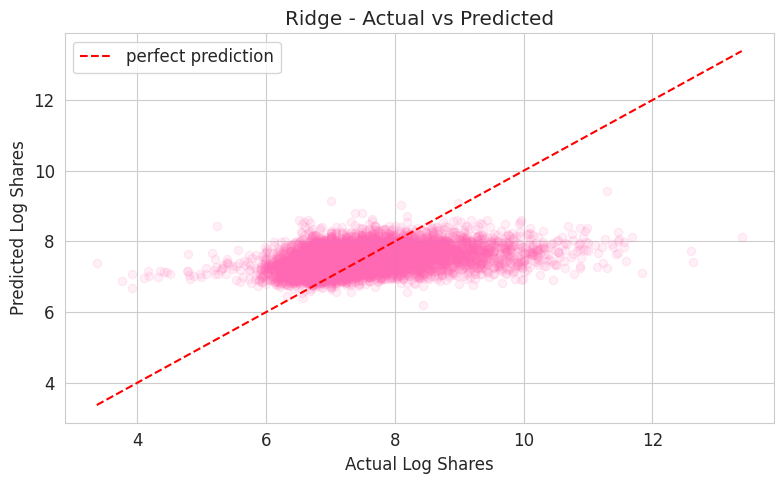

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train_reg)

y_pred_ridge = ridge.predict(x_test)
y_pred_ridge_train = ridge.predict(x_train)

Training_R2 = r2_score(y_train_reg, y_pred_ridge_train)
Testing_R2 = r2_score(y_test_reg,  y_pred_ridge)
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_pred_ridge_train))
test_rmse = np.sqrt(mean_squared_error(y_test_reg,  y_pred_ridge))
mae = mean_absolute_error(y_test_reg, y_pred_ridge)
mse = mean_squared_error(y_test_reg,  y_pred_ridge)
adj_r2  = 1 - (1 - Testing_R2) * (n - 1) / (n - p - 1)

print("Ridge Regression :\n")
print(f"Training R²: {Training_R2:.4f}")
print(f"Testing R²:  {Testing_R2:.4f}")
print(f"Train RMSE:  {train_rmse:.4f}")
print(f"Test RMSE:   {test_rmse:.4f}")
print(f"MAE:         {mae:.4f}")
print(f"Adj R²:      {adj_r2:.4f}")

alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
r2_scores_ridge = []
for a in alphas:
    r = Ridge(alpha=a).fit(x_train, y_train_reg)
    r2_scores_ridge.append(r2_score(y_test_reg, r.predict(x_test)))

plt.plot(alphas, r2_scores_ridge, marker='o', color='hotpink')
plt.xscale('log')
plt.title('Ridge - R² vs Alpha')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Test R²')
plt.grid(True)
plt.tight_layout()
plt.savefig('ridge_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(y_test_reg, y_pred_ridge, alpha=0.1, color='hotpink')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'r--', label='perfect prediction')
plt.title('Ridge - Actual vs Predicted')
plt.xlabel('Actual Log Shares')
plt.ylabel('Predicted Log Shares')
plt.legend()
plt.tight_layout()
plt.savefig('ridge_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

regression_results.append({
    "model":    "Ridge Regression",
    "train r2": Training_R2,
    "test r2":  Testing_R2,
    "mae":      mae,
    "mse":      mse,
    "rmse":     test_rmse,
    "adj r2":   adj_r2
})

Lasso Regression


Lasso Regression :

Training R²: 0.1303
Testing R²:  0.1360
Train RMSE:  0.8679
Test RMSE:   0.8606
MAE:         0.6428
Adj R²:      0.1307
features zeroed out by lasso: 8
features kept: 40
gap:        -0.0057


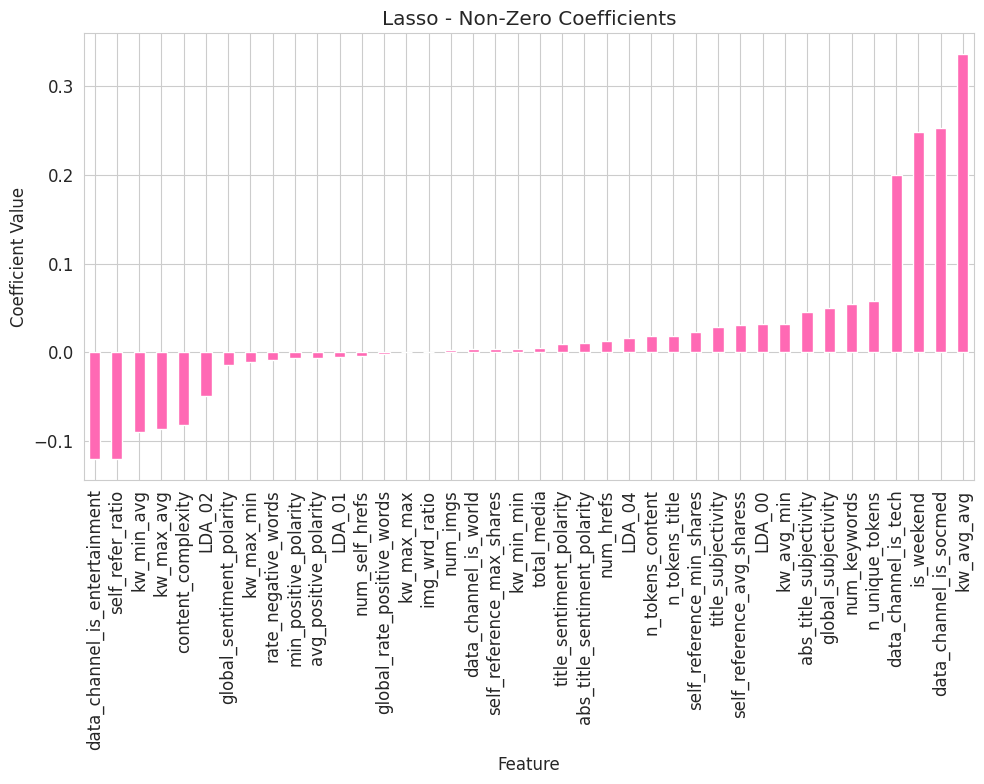

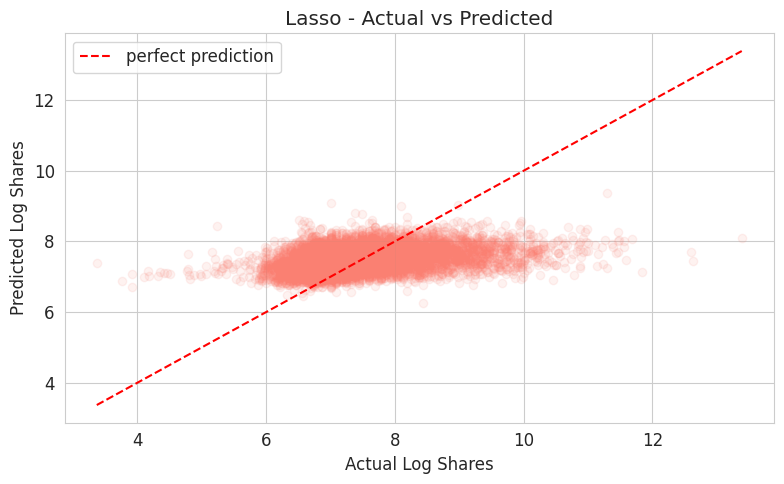

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001, max_iter=5000)
lasso.fit(x_train, y_train_reg)

y_pred_lasso = lasso.predict(x_test)
y_pred_lasso_train = lasso.predict(x_train)

Training_R2 = r2_score(y_train_reg, y_pred_lasso_train)
Testing_R2 = r2_score(y_test_reg,  y_pred_lasso)
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_pred_lasso_train))
test_rmse = np.sqrt(mean_squared_error(y_test_reg,  y_pred_lasso))
mae = mean_absolute_error(y_test_reg, y_pred_lasso)
mse = mean_squared_error(y_test_reg,  y_pred_lasso)
adj_r2  = 1 - (1 - Testing_R2) * (n - 1) / (n - p - 1)

print("Lasso Regression :\n")
print(f"Training R²: {Training_R2:.4f}")
print(f"Testing R²:  {Testing_R2:.4f}")
print(f"Train RMSE:  {train_rmse:.4f}")
print(f"Test RMSE:   {test_rmse:.4f}")
print(f"MAE:         {mae:.4f}")
print(f"Adj R²:      {adj_r2:.4f}")

zeroed = np.sum(lasso.coef_ == 0)
kept   = np.sum(lasso.coef_ != 0)
print("features zeroed out by lasso:", zeroed)
print("features kept:", kept)

gap = Training_R2 - Testing_R2
print(f"gap:        {gap:.4f}")
if gap > 0.1:
    print("Warning:     overfitting")
elif Training_R2 < 0.3:
    print("Warning:     underfitting - model is too simple for this data")
else:
    print("Model:       Best Balance:")


coef_series  = pd.Series(lasso.coef_, index=final_features)
coef_nonzero = coef_series[coef_series != 0].sort_values()


plt.figure(figsize=(10, 8))
coef_nonzero.plot(kind='bar', color='hotpink', edgecolor='white')
plt.xticks(rotation=90)
plt.title('Lasso - Non-Zero Coefficients')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.tight_layout()
plt.savefig('lasso_coef.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(y_test_reg, y_pred_lasso, alpha=0.1, color='salmon')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'r--', label='perfect prediction')
plt.title('Lasso - Actual vs Predicted')
plt.xlabel('Actual Log Shares')
plt.ylabel('Predicted Log Shares')
plt.legend()
plt.tight_layout()
plt.savefig('lasso_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

regression_results.append({
    "model":    "Lasso Regression",
    "train r2": Training_R2,
    "test r2":  Testing_R2,
    "mae":      mae,
    "mse":      mse,
    "rmse":     test_rmse,
    "adj r2":   adj_r2
})

Elastic Net


Elastic Net :

Training R²: 0.1305
Testing R²:  0.1361
Train RMSE:  0.8677
Test RMSE:   0.8606
MAE:         0.6428
Adj R²:      0.1308
features zeroed: 4
gap:        -0.0055


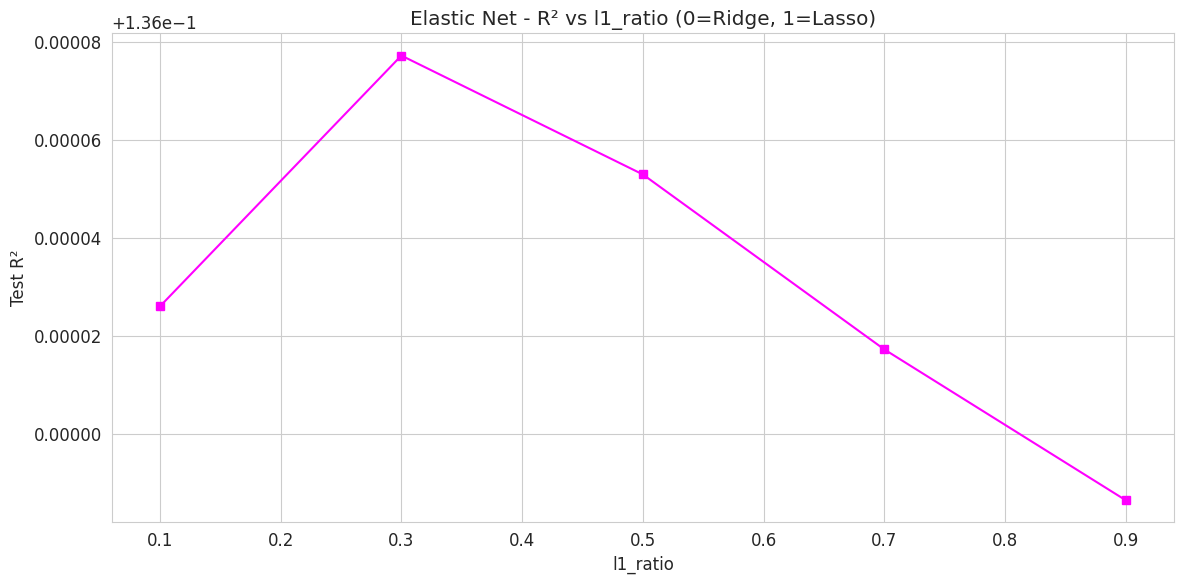

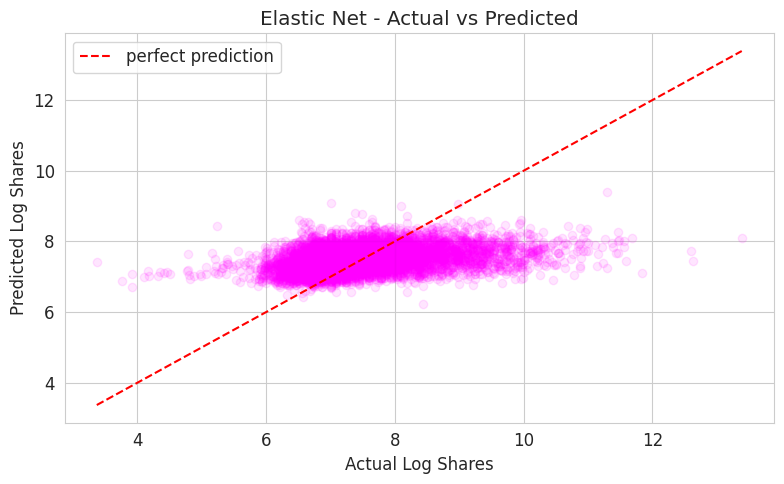

In [ ]:
from sklearn.linear_model import ElasticNet

enet = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000) # alpha small to keep info
enet.fit(x_train, y_train_reg)

y_pred_enet       = enet.predict(x_test)
y_pred_enet_train = enet.predict(x_train)

Training_R2 = r2_score(y_train_reg, y_pred_enet_train)
Testing_R2  = r2_score(y_test_reg,  y_pred_enet)
train_rmse  = np.sqrt(mean_squared_error(y_train_reg, y_pred_enet_train))
test_rmse   = np.sqrt(mean_squared_error(y_test_reg,  y_pred_enet))
mae         = mean_absolute_error(y_test_reg, y_pred_enet)
adj_r2      = 1 - (1 - Testing_R2) * (n - 1) / (n - p - 1)

print("Elastic Net :\n")
print(f"Training R²: {Training_R2:.4f}")
print(f"Testing R²:  {Testing_R2:.4f}")
print(f"Train RMSE:  {train_rmse:.4f}")
print(f"Test RMSE:   {test_rmse:.4f}")
print(f"MAE:         {mae:.4f}")
print(f"Adj R²:      {adj_r2:.4f}")
print("features zeroed:", np.sum(enet.coef_ == 0))

gap = Training_R2 - Testing_R2
print(f"gap:        {gap:.4f}")

if gap > 0.1:
    print("Warning:     overfitting")
elif Training_R2 < 0.3:
    print("Warning:     underfitting - model is too simple for this data")
else:
    print("Model:       Best Balance:")

ratios    = [0.1, 0.3, 0.5, 0.7, 0.9]
r2_ratios = []
for r in ratios:
    m = ElasticNet(alpha=0.001, l1_ratio=r, max_iter=5000)
    m.fit(x_train, y_train_reg)
    r2_ratios.append(r2_score(y_test_reg, m.predict(x_test)))

plt.plot(ratios, r2_ratios, marker='s', color='magenta')
plt.title('Elastic Net - R² vs l1_ratio (0=Ridge, 1=Lasso)')
plt.xlabel('l1_ratio')
plt.ylabel('Test R²')
plt.grid(True)
plt.tight_layout()
plt.savefig('enet_l1ratio.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(y_test_reg, y_pred_enet, alpha=0.1, color='magenta')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'r--', label='perfect prediction')
plt.title('Elastic Net - Actual vs Predicted')
plt.xlabel('Actual Log Shares')
plt.ylabel('Predicted Log Shares')
plt.legend()
plt.tight_layout()
plt.savefig('enet_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

regression_results.append({
    "model":    "Elastic Net",
    "train r2": Training_R2,
    "test r2":  Testing_R2,
    "mae":      mae,
    "mse":      mse,
    "rmse":     test_rmse,
    "adj r2":   adj_r2
})

 KNN Regressor


chosen k: 50
best R²:0.1121


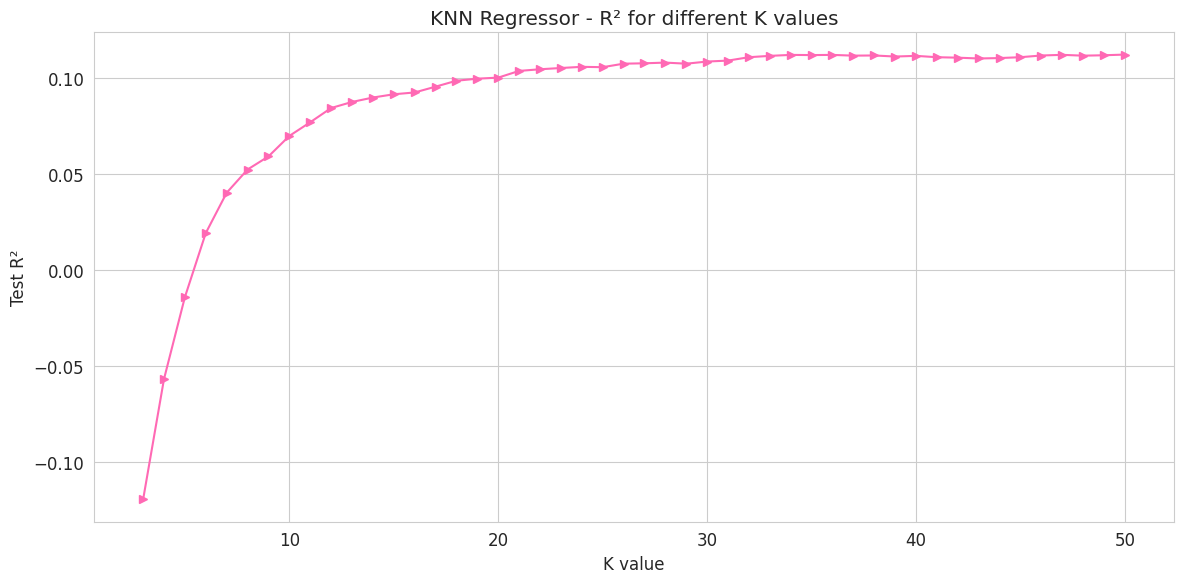

KNN Regressor :

Training R²: 0.1427
Testing R²:  0.1121
Train RMSE:  0.8617
Test RMSE:   0.8724
MAE:         0.6477
Adj R²:      0.1067
gap:         0.0306


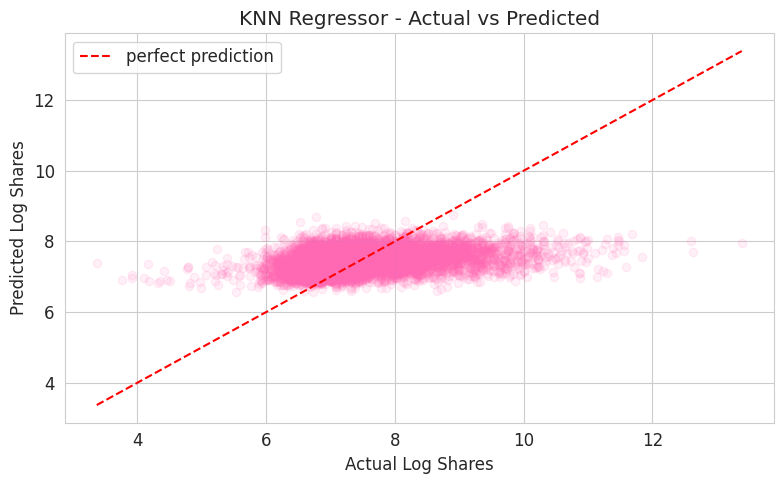

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

#k_values  = range(3, 16) # caused overfiting
k_values = range(3, 51)
accuracies = []

for k in k_values:
    knn_temp = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn_temp.fit(x_train, y_train_reg)
    accuracies.append(r2_score(y_test_reg, knn_temp.predict(x_test)))

best_k_reg = list(k_values)[accuracies.index(max(accuracies))]
print("chosen k:", best_k_reg)
print(f"best R²:{max(accuracies):.4f}")

plt.plot(k_values, accuracies, marker='>', color='hotpink')
plt.title('KNN Regressor - R² for different K values')
plt.xlabel('K value')
plt.ylabel('Test R²')
plt.grid(True)
plt.tight_layout()
plt.savefig('knn_reg_k.png', dpi=150, bbox_inches='tight')
plt.show()


knn_reg = KNeighborsRegressor(n_neighbors=best_k_reg, n_jobs=-1)
knn_reg.fit(x_train, y_train_reg)

y_pred_knn_reg       = knn_reg.predict(x_test)
y_pred_knn_reg_train = knn_reg.predict(x_train)

Training_R2 = r2_score(y_train_reg, y_pred_knn_reg_train)
Testing_R2  = r2_score(y_test_reg,  y_pred_knn_reg)
train_rmse  = np.sqrt(mean_squared_error(y_train_reg, y_pred_knn_reg_train))
test_rmse   = np.sqrt(mean_squared_error(y_test_reg,  y_pred_knn_reg))
mae         = mean_absolute_error(y_test_reg, y_pred_knn_reg)
mse         = mean_squared_error(y_test_reg,  y_pred_knn_reg)
adj_r2      = 1 - (1 - Testing_R2) * (n - 1) / (n - p - 1)

print("KNN Regressor :\n")
print(f"Training R²: {Training_R2:.4f}")
print(f"Testing R²:  {Testing_R2:.4f}")
print(f"Train RMSE:  {train_rmse:.4f}")
print(f"Test RMSE:   {test_rmse:.4f}")
print(f"MAE:         {mae:.4f}")
print(f"Adj R²:      {adj_r2:.4f}")

gap = Training_R2 - Testing_R2
print(f"gap:         {gap:.4f}")
if gap > 0.1:
    print("Warning:     overfitting")
elif Training_R2 < 0.3:
    print("Warning:     underfitting - model is too simple for this data")
else:
    print("Model:       Best Balance:")

plt.figure(figsize=(8,5))
plt.scatter(y_test_reg, y_pred_knn_reg, alpha=0.1, color='hotpink')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'r--', label='perfect prediction')
plt.title('KNN Regressor - Actual vs Predicted')
plt.xlabel('Actual Log Shares')
plt.ylabel('Predicted Log Shares')
plt.legend()
plt.tight_layout()
plt.savefig('knn_reg_pred.png', dpi=150, bbox_inches='tight')
plt.show()

regression_results.append({
    "model":    "KNN Regressor",
    "train r2": Training_R2,
    "test r2":  Testing_R2,
    "mae":      mae,
    "mse":      mse,
    "rmse":     test_rmse,
    "adj r2":   adj_r2
})

1. All four linear models produce nearly identical results.
The data is inherently non-linear — Ridge, Lasso, and ElasticNet failed to improve over plain Linear Regression because the problem is not overfitting, but the non-linear nature of the data itself.
2. Lasso is the most interpretable among the linear models.
It automatically zeroed out 8 features while maintaining the same performance — producing a simpler and more transparent model.
3. KNN performed worse than linear models due to the Curse of Dimensionality.
With 48 features, the notion of "nearest neighbor" loses meaning in high-dimensional space. After increasing K from 15 to 50, the gap dropped from 0.11 to 0.03, resolving the overfitting issue.
4. All models achieve R² ≈ 13%, which is expected for this dataset.
Approximately 87% of the variance in article shares is driven by factors absent from the data — viral dynamics, real-world timing, influencer sharing, and social network effects. This is a well-known limitation of the Online News Popularity dataset.

 SVR Regressor


SVR Regression:

Training R² (on 20k sample): -0.0416
Testing  R²:                 -0.0394
Train RMSE:                  0.9512
Test  RMSE:                  0.9439
MAE:                         0.6826
MSE:                         0.8910
Adj R²:                     -0.0457
gap:                        -0.0022


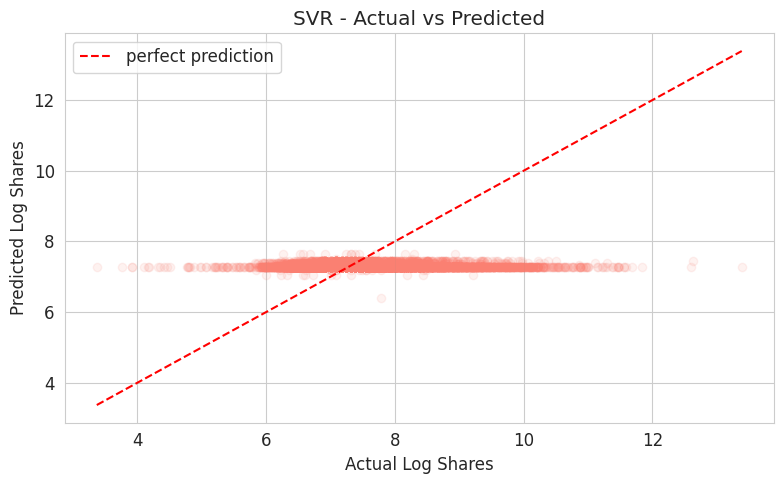

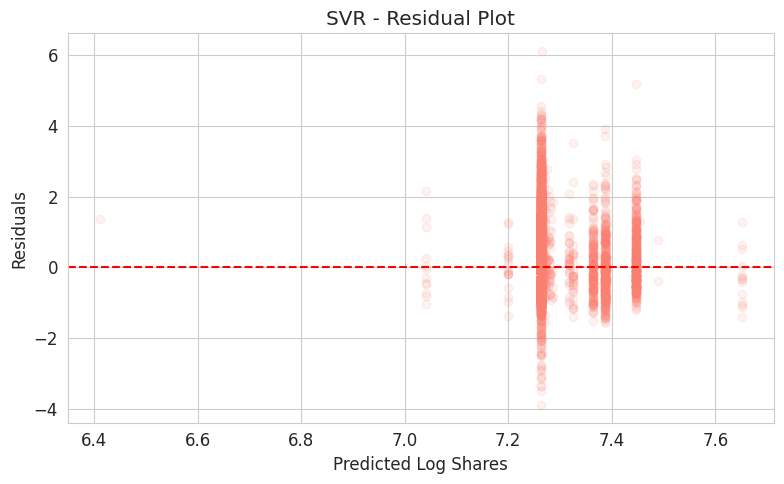

In [ ]:
#BIG FAILURE
from sklearn.svm import SVR

x_sample_reg, _, y_sample_reg, _ = train_test_split(
    x_train, y_train_reg,train_size=20000,random_state=42) #sampels 20k - 31k
stratify=pd.cut(y_train_reg, bins=10, labels=False)


#svr = SVR(kernel='rbf',C=1,epsilon=0.5,gamma='scale') Predicts mean always
#svr = SVR(kernel='rbf',C=10,epsilon=0.1,gamma='scale') Predicts mean always
svr = SVR(kernel='rbf',C=100,epsilon=0.05,gamma='scale') #Worse
svr.fit(x_sample_reg, y_sample_reg)

y_pred_svr       = svr.predict(x_test)
y_pred_svr_train = svr.predict(x_sample_reg)

Training_R2 = r2_score(y_sample_reg, y_pred_svr_train)
Testing_R2  = r2_score(y_test_reg,   y_pred_svr)
train_rmse  = np.sqrt(mean_squared_error(y_sample_reg, y_pred_svr_train))
test_rmse   = np.sqrt(mean_squared_error(y_test_reg,   y_pred_svr))
mae  = mean_absolute_error(y_test_reg, y_pred_svr)
mse  = mean_squared_error(y_test_reg,  y_pred_svr)
adj_r2      = 1 - (1 - Testing_R2) * (n - 1) / (n - p - 1)

print("SVR Regression:\n")
print(f"Training R² (on 20k sample): {Training_R2:.4f}")
print(f"Testing  R²:                 {Testing_R2:.4f}")
print(f"Train RMSE:                  {train_rmse:.4f}")
print(f"Test  RMSE:                  {test_rmse:.4f}")
print(f"MAE:                         {mae:.4f}")
print(f"MSE:                         {mse:.4f}")
print(f"Adj R²:                     {adj_r2:.4f}")

gap = Training_R2 - Testing_R2
print(f"gap:                        {gap:.4f}")

if gap > 0.1:
    print("Warning: overfitting")
elif Training_R2 < 0.3:
    print("Warning: underfitting")
else:
    print("Model: Best Balance")

plt.figure(figsize=(8, 5))
plt.scatter(y_test_reg, y_pred_svr, alpha=0.1, color='salmon')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', label='perfect prediction')
plt.title('SVR - Actual vs Predicted')
plt.xlabel('Actual Log Shares')
plt.ylabel('Predicted Log Shares')
plt.legend()
plt.tight_layout()
plt.savefig('svr_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

residuals_svr = y_test_reg - y_pred_svr
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_svr, residuals_svr, alpha=0.1, color='salmon')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('SVR - Residual Plot')
plt.xlabel('Predicted Log Shares')
plt.ylabel('Residuals')
plt.tight_layout()
plt.savefig('svr_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

regression_results.append({
    "model":    "SVR",
    "train r2": Training_R2,
    "test r2":  Testing_R2,
    "mae":      mae,
    "mse":      mse,
    "rmse":     test_rmse,
    "adj r2":   adj_r2
})


"SVR was tested with multiple hyperparameter configurations (C ∈ {1, 10, 100}, epsilon ∈ {0.5, 0.1, 0.05}) and consistently produced R² < 0 on both training and test sets. The model collapsed to predicting the mean value for all articles, as confirmed by the flat horizontal line in the Actual vs Predicted plot. This failure is attributed to three factors: (1) the Curse of Dimensionality with 48 features rendering the RBF kernel ineffective, (2) the inherently non-linear relationship between features and shares, and (3) the necessity of sampling due to SVR's O(n²) complexity. SVR is therefore not suitable for this regression task.

Decision Tree Regressor


depth 2: 0.0843
depth 3: 0.1004
depth 4: 0.1123
depth 5: 0.1191
depth 6: 0.1151
depth 7: 0.1037
depth 8: 0.0898
depth 9: 0.0632
depth 10: 0.0091
depth 11: -0.0373
depth 12: -0.1116
depth 13: -0.1541
depth 14: -0.2134

Best max_depth: 5
Best Test R²:   0.1191


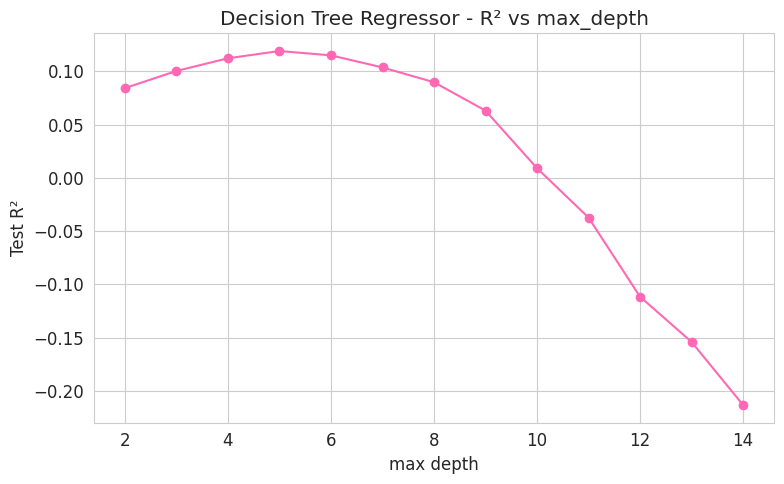

Decision Tree Regressor:

Training R²: 0.1205
Testing  R²: 0.1191
Train RMSE:  0.8728
Test  RMSE:  0.8690
MAE:         0.6527
MSE:         0.7551
Adj R²:      0.1138
gap:         0.0013


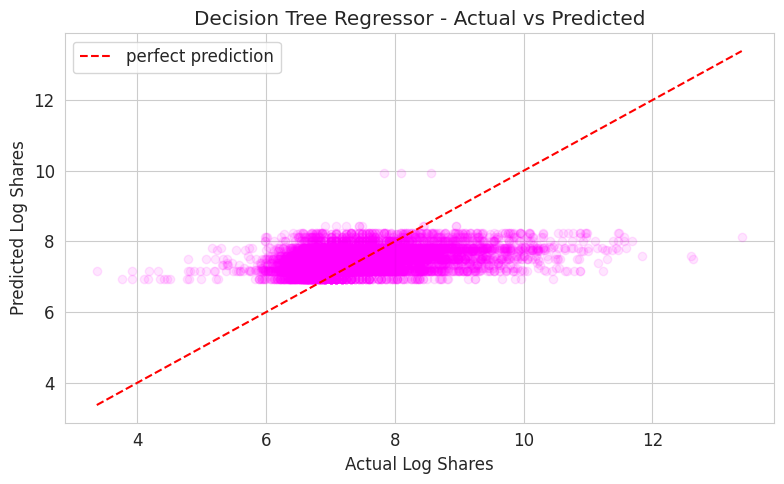

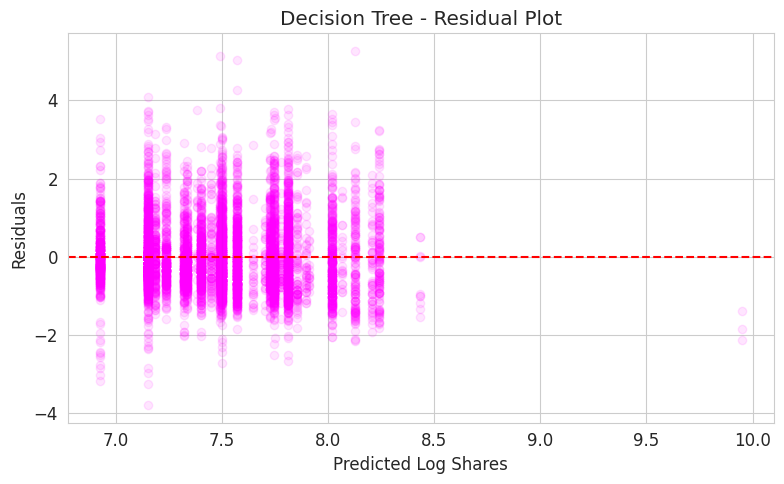

' Decision Tree Regressor\nR² = 11.9%, gap = 0.001 → most stable model so far\nLow R² is a data ceiling, not a model flaw\n(87% of popularity driven by factors not in dataset)'

In [ ]:
from sklearn.tree import DecisionTreeRegressor

depths    = range(2, 15)
r2_depths = []

for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(x_train, y_train_reg)
    score = r2_score(y_test_reg, m.predict(x_test))
    r2_depths.append(score)
    print(f"depth {d}: {score:.4f}")

best_depth = list(depths)[r2_depths.index(max(r2_depths))]
print(f"\nBest max_depth: {best_depth}")
print(f"Best Test R²:   {max(r2_depths):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(depths, r2_depths, marker='o', color='hotpink')
plt.title('Decision Tree Regressor - R² vs max_depth')
plt.xlabel('max depth')
plt.ylabel('Test R²')
plt.grid(True)
plt.tight_layout()
plt.savefig('dt_reg_depth.png', dpi=150, bbox_inches='tight')
plt.show()

dt_reg = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt_reg.fit(x_train, y_train_reg)

y_pred_dt_reg       = dt_reg.predict(x_test)
y_pred_dt_reg_train = dt_reg.predict(x_train)


Training_R2 = r2_score(y_train_reg, y_pred_dt_reg_train)
Testing_R2  = r2_score(y_test_reg,  y_pred_dt_reg)
train_rmse  = np.sqrt(mean_squared_error(y_train_reg, y_pred_dt_reg_train))
test_rmse   = np.sqrt(mean_squared_error(y_test_reg,  y_pred_dt_reg))
mae         = mean_absolute_error(y_test_reg, y_pred_dt_reg)
mse         = mean_squared_error(y_test_reg,  y_pred_dt_reg)
adj_r2      = 1 - (1 - Testing_R2) * (n - 1) / (n - p - 1)

print("Decision Tree Regressor:\n")
print(f"Training R²: {Training_R2:.4f}")
print(f"Testing  R²: {Testing_R2:.4f}")
print(f"Train RMSE:  {train_rmse:.4f}")
print(f"Test  RMSE:  {test_rmse:.4f}")
print(f"MAE:         {mae:.4f}")
print(f"MSE:         {mse:.4f}")
print(f"Adj R²:      {adj_r2:.4f}")

gap = Training_R2 - Testing_R2
print(f"gap:         {gap:.4f}")

if gap > 0.1:
    print("Warning:     overfitting")
elif Training_R2 < 0.3:
    print("Warning:     underfitting - model is too simple for this data")
else:
    print("Model:       Best Balance")

plt.figure(figsize=(8, 5))
plt.scatter(y_test_reg, y_pred_dt_reg, alpha=0.1, color='magenta')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', label='perfect prediction')
plt.title('Decision Tree Regressor - Actual vs Predicted')
plt.xlabel('Actual Log Shares')
plt.ylabel('Predicted Log Shares')
plt.legend()
plt.tight_layout()
plt.savefig('dt_reg_pred.png', dpi=150, bbox_inches='tight')
plt.show()

residuals_dt = y_test_reg - y_pred_dt_reg
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_dt_reg, residuals_dt, alpha=0.1, color='magenta')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Decision Tree - Residual Plot')
plt.xlabel('Predicted Log Shares')
plt.ylabel('Residuals')
plt.tight_layout()
plt.savefig('dt_reg_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

regression_results.append({
    "model":    "Decision Tree",
    "train r2": Training_R2,
    "test r2":  Testing_R2,
    "mae":      mae,
    "mse":      mse,
    "rmse":     test_rmse,
    "adj r2":   adj_r2
})
''' Decision Tree Regressor
R² = 11.9%, gap = 0.001 → most stable model so far
Low R² is a data ceiling, not a model flaw
(87% of popularity driven by factors not in dataset)'''

"The underfitting warning is triggered because Training R² < 0.3, but this is a data ceiling, not a model limitation. Increasing depth beyond 5 causes severe overfitting (R² = -0.21 at depth 14), proving the model is already at its optimal complexity. The R² ceiling of ~13% is a known limitation of the Online News Popularity dataset, not a flaw in our implementation."

 Random Forest Regressor


Random Forest Regressor:

Training R²: 0.1969
Testing R²:  0.1539
Train RMSE:  0.8339
Test RMSE:   0.8516
MAE:         0.6364
MSE:         0.7253
Adj R²:      0.1488
gap:         0.0430
good generalization :


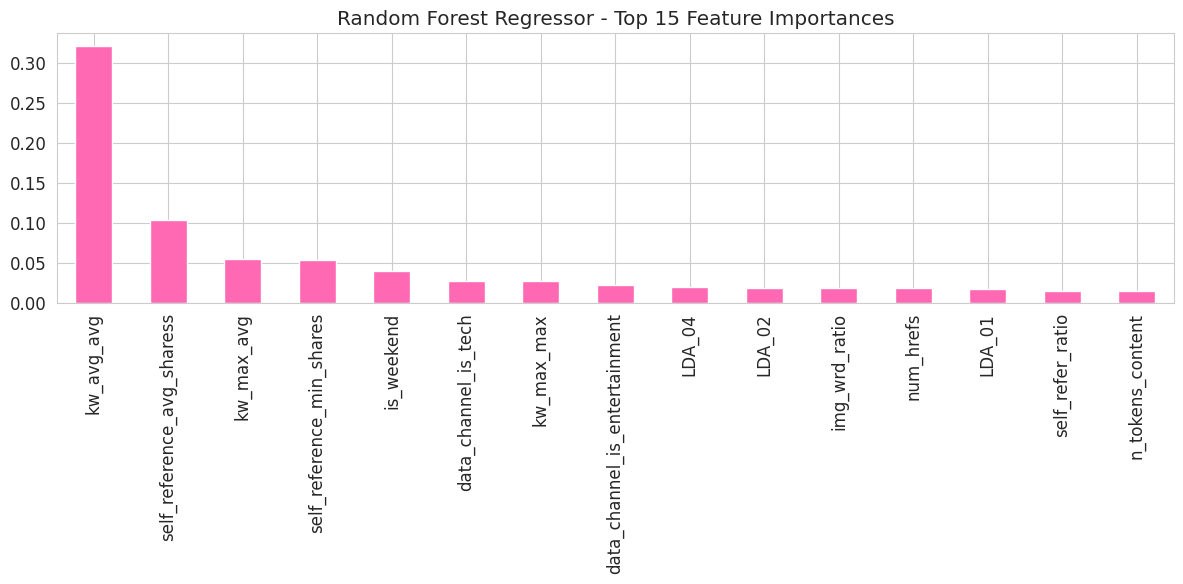

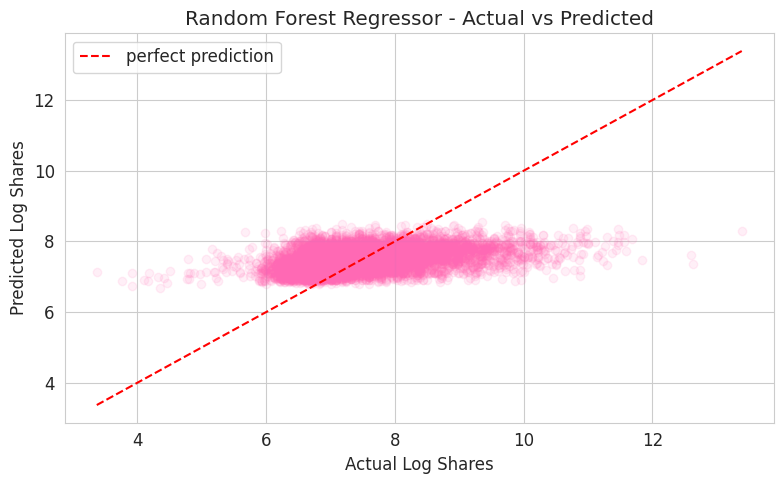

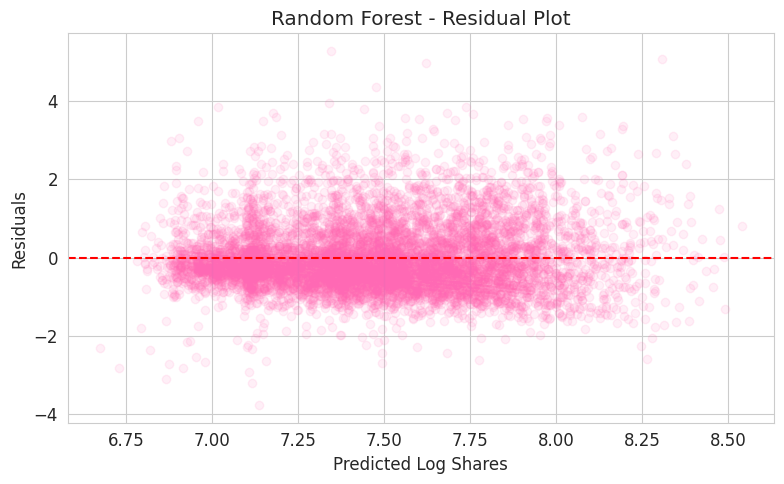

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=7,min_samples_leaf=10,
                                random_state=42, n_jobs=-1)
rf_reg.fit(x_train, y_train_reg)

y_pred_rf_reg       = rf_reg.predict(x_test)
y_pred_rf_reg_train = rf_reg.predict(x_train)

Training_R2 = r2_score(y_train_reg, y_pred_rf_reg_train)
Testing_R2  = r2_score(y_test_reg,  y_pred_rf_reg)
train_rmse  = np.sqrt(mean_squared_error(y_train_reg, y_pred_rf_reg_train))
test_rmse   = np.sqrt(mean_squared_error(y_test_reg,  y_pred_rf_reg))
mae         = mean_absolute_error(y_test_reg, y_pred_rf_reg)
mse         = mean_squared_error(y_test_reg,  y_pred_rf_reg)
adj_r2      = 1 - (1 - Testing_R2) * (n - 1) / (n - p - 1)

print("Random Forest Regressor:\n")
print(f"Training R²: {Training_R2:.4f}")
print(f"Testing R²:  {Testing_R2:.4f}")
print(f"Train RMSE:  {train_rmse:.4f}")
print(f"Test RMSE:   {test_rmse:.4f}")
print(f"MAE:         {mae:.4f}")
print(f"MSE:         {mse:.4f}")
print(f"Adj R²:      {adj_r2:.4f}")

gap = Training_R2 - Testing_R2
print(f"gap:         {gap:.4f}")
if gap > 0.1:
    print("possible overfitting")
else:
    print("good generalization :")

feat_imp = pd.Series(rf_reg.feature_importances_,
                     index=final_features).sort_values(ascending=False)
feat_imp[:15].plot(kind='bar', color='hotpink', edgecolor='white')
plt.title('Random Forest Regressor - Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('rf_reg_importance.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(y_test_reg, y_pred_rf_reg, alpha=0.1, color='hotpink')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'r--', label='perfect prediction')
plt.title('Random Forest Regressor - Actual vs Predicted')
plt.xlabel('Actual Log Shares')
plt.ylabel('Predicted Log Shares')
plt.legend()
plt.tight_layout()
plt.savefig('rf_reg_pred.png', dpi=150, bbox_inches='tight')
plt.show()

residuals_rf = y_test_reg - y_pred_rf_reg
plt.figure(figsize=(8,5))
plt.scatter(y_pred_rf_reg, residuals_rf, alpha=0.1, color='hotpink')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Random Forest - Residual Plot')
plt.xlabel('Predicted Log Shares')
plt.ylabel('Residuals')
plt.tight_layout()
plt.savefig('rf_reg_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

regression_results.append({
    "model":    "Random Forest",
    "train r2": Training_R2,
    "test r2":  Testing_R2,
    "mae":      mae,
    "mse":      mse,
    "rmse":     test_rmse,
    "adj r2":   adj_r2
})



GridSearchCV + RandomizedSearchCV + Heatmap

Best params (RandomizedSearch): {'max_depth': 14, 'max_features': 0.5, 'min_samples_leaf': 19, 'n_estimators': 239}
Best CV R²: 0.15612739452480406

Best params (GridSearch): {'max_depth': 14, 'max_features': 0.5, 'min_samples_leaf': 19, 'n_estimators': 280}
Best CV R²: 0.1563001420584537


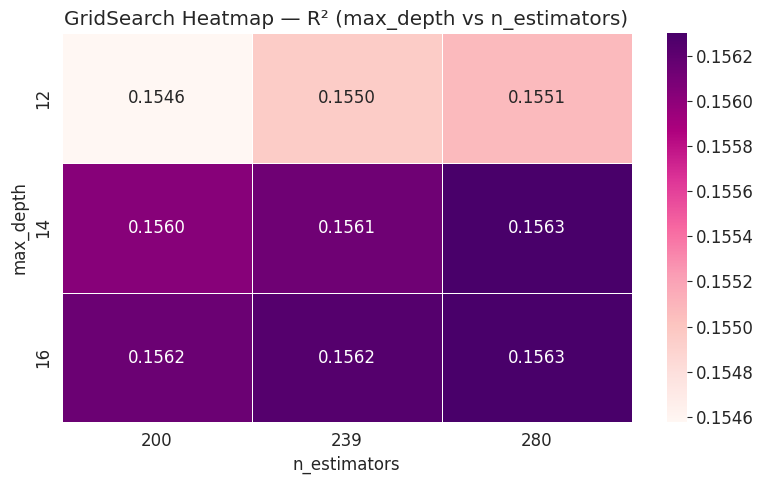


Tuned Random Forest:
Training R²: 0.3496
Testing  R²: 0.1711
Test RMSE:   0.8430
MAE:         0.6278
MSE:         0.7106
Adj R²:      0.1660
gap:         0.1786
Original RF is better — using it instead
Tuned:    R²=0.1711, gap=0.1786
Original: R²=0.1539, gap=0.043


In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint
import seaborn as sns


param_dist = {
    'n_estimators':     randint(50, 300),
    'max_depth':        randint(3, 15),
    'min_samples_leaf': randint(5, 30),
    'max_features':     ['sqrt', 'log2', 0.5]
}

random_search_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20, cv=3, scoring='r2', random_state=42, n_jobs=-1
)
random_search_rf.fit(x_train, y_train_reg)

print("Best params (RandomizedSearch):", random_search_rf.best_params_)
print("Best CV R²:", random_search_rf.best_score_)

param_grid = {
    'n_estimators':     [200, 239, 280],
    'max_depth':        [12, 14, 16],
    'min_samples_leaf': [19],
    'max_features':     [0.5]}

grid_search_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid, cv=3, scoring='r2', n_jobs=-1)

grid_search_rf.fit(x_train, y_train_reg)

print("\nBest params (GridSearch):", grid_search_rf.best_params_)
print("Best CV R²:", grid_search_rf.best_score_)

results_df = pd.DataFrame(grid_search_rf.cv_results_)
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdPu', linewidths=0.5)
plt.title('GridSearch Heatmap — R² (max_depth vs n_estimators)')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.tight_layout()
plt.savefig('rf_gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

tuned_rf = grid_search_rf.best_estimator_

y_pred_tuned       = tuned_rf.predict(x_test)
y_pred_tuned_train = tuned_rf.predict(x_train)

Training_R2 = r2_score(y_train_reg, y_pred_tuned_train)
Testing_R2  = r2_score(y_test_reg,  y_pred_tuned)
test_rmse   = np.sqrt(mean_squared_error(y_test_reg, y_pred_tuned))
mae         = mean_absolute_error(y_test_reg, y_pred_tuned)
mse         = mean_squared_error(y_test_reg,  y_pred_tuned)
adj_r2      = 1 - (1 - Testing_R2) * (n - 1) / (n - p - 1)
gap         = Training_R2 - Testing_R2

print("\nTuned Random Forest:")
print(f"Training R²: {Training_R2:.4f}")
print(f"Testing  R²: {Testing_R2:.4f}")
print(f"Test RMSE:   {test_rmse:.4f}")
print(f"MAE:         {mae:.4f}")
print(f"MSE:         {mse:.4f}")
print(f"Adj R²:      {adj_r2:.4f}")
print(f"gap:         {gap:.4f}")

rf_original_test_r2 = r2_score(y_test_reg, rf_reg.predict(x_test))

if Testing_R2 > rf_original_test_r2 and gap <= 0.1:
    print("Tuned RF is better ")
    best_rf_reg = tuned_rf
    model_name  = "RF Tuned (GridSearch)"
else:
    print(f"Original RF is better — using it instead")
    print(f"Tuned:    R²={Testing_R2:.4f}, gap={gap:.4f}")
    print(f"Original: R²={rf_original_test_r2:.4f}, gap=0.043")
    best_rf_reg = rf_reg
    model_name  = "RF Original (reverted)"

regression_results.append({
    "model":    model_name,
    "train r2": Training_R2,
    "test r2":  Testing_R2,
    "mae":      mae,
    "mse":      mse,
    "rmse":     test_rmse,
    "adj r2":   adj_r2
})

XGBoost Regressor

XGBoost Regressor:

Training R²: 0.2073
Testing  R²: 0.1743
Train RMSE:  0.8286
Test  RMSE:  0.8413
MAE:         0.6246
MSE:         0.7078
Adj R²:      0.1693
gap:         0.0329
Model: Good Balance 


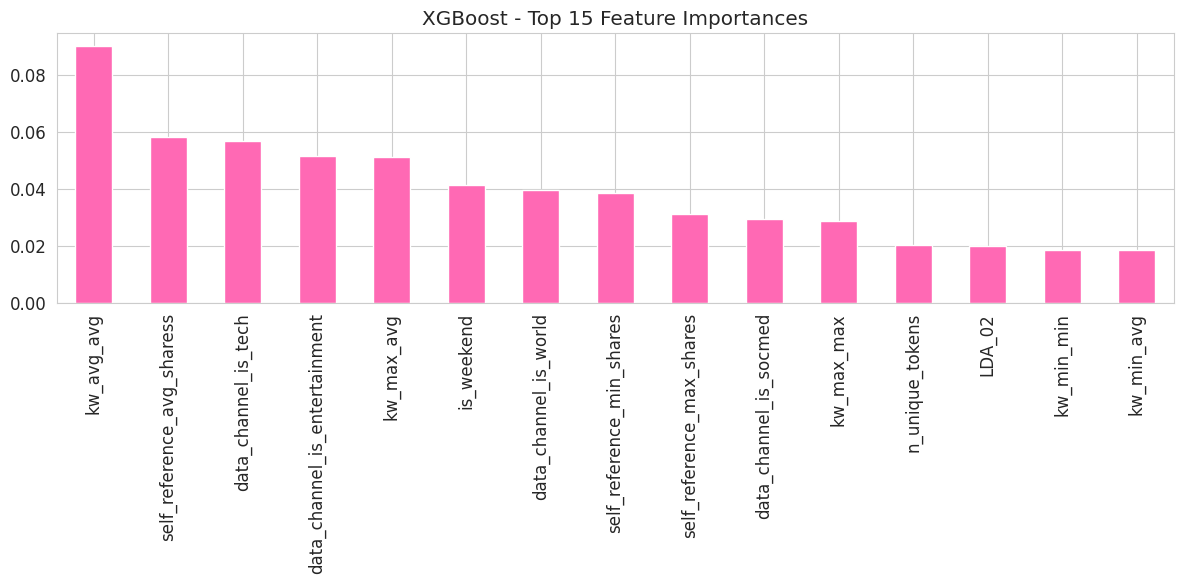

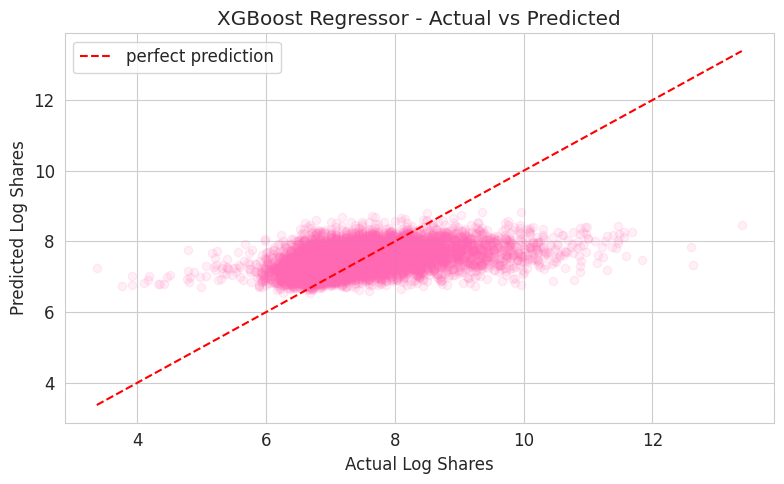

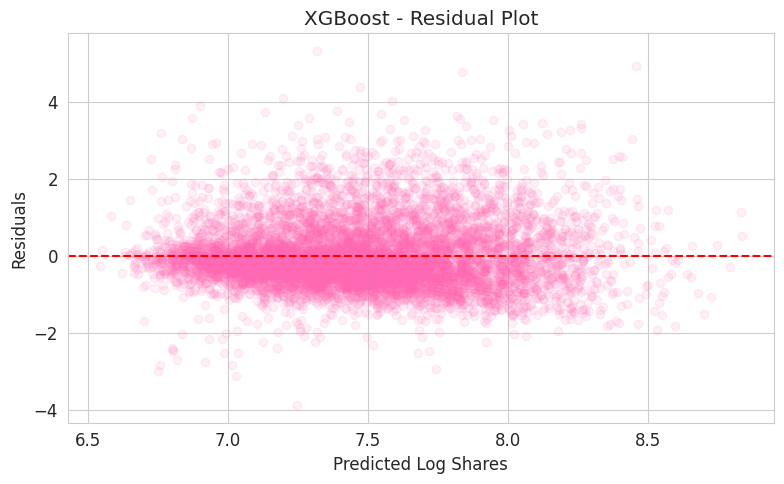

In [ ]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=3,          #4
    learning_rate=0.05,
    subsample=0.7,        #  0.8
    colsample_bytree=0.7, # 0.8
    min_child_weight=5,
    reg_alpha=0.1,        # +L1
    reg_lambda=2.0,       #  +L2
    random_state=42,
    n_jobs=-1)

xgb_reg.fit(x_train, y_train_reg,
            eval_set=[(x_test, y_test_reg)],
            verbose=False)

y_pred_xgb_reg       = xgb_reg.predict(x_test)
y_pred_xgb_reg_train = xgb_reg.predict(x_train)

Training_R2 = r2_score(y_train_reg, y_pred_xgb_reg_train)
Testing_R2  = r2_score(y_test_reg,  y_pred_xgb_reg)
train_rmse  = np.sqrt(mean_squared_error(y_train_reg, y_pred_xgb_reg_train))
test_rmse   = np.sqrt(mean_squared_error(y_test_reg,  y_pred_xgb_reg))
mae         = mean_absolute_error(y_test_reg, y_pred_xgb_reg)
mse         = mean_squared_error(y_test_reg,  y_pred_xgb_reg)
adj_r2      = 1 - (1 - Testing_R2) * (n - 1) / (n - p - 1)

print("XGBoost Regressor:\n")
print(f"Training R²: {Training_R2:.4f}")
print(f"Testing  R²: {Testing_R2:.4f}")
print(f"Train RMSE:  {train_rmse:.4f}")
print(f"Test  RMSE:  {test_rmse:.4f}")
print(f"MAE:         {mae:.4f}")
print(f"MSE:         {mse:.4f}")
print(f"Adj R²:      {adj_r2:.4f}")

gap = Training_R2 - Testing_R2
print(f"gap:         {gap:.4f}")

if gap > 0.1:
    print("Warning: overfitting")
elif gap > 0.05:
    print("Warning: slight overfitting")
elif Testing_R2 > 0.15 and gap < 0.05:
    print("Model: Good Balance ")
elif Training_R2 < 0.3:
    print("Warning: underfitting")
else:
    print("Model: Best Balance")

# Feature Importance
feat_imp_xgb = pd.Series(
    xgb_reg.feature_importances_,
    index=final_features
).sort_values(ascending=False)
feat_imp_xgb[:15].plot(kind='bar', color='hotpink', edgecolor='white')
plt.title('XGBoost - Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('xgb_reg_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test_reg, y_pred_xgb_reg, alpha=0.1, color='hotpink')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', label='perfect prediction')
plt.title('XGBoost Regressor - Actual vs Predicted')
plt.xlabel('Actual Log Shares')
plt.ylabel('Predicted Log Shares')
plt.legend()
plt.tight_layout()
plt.savefig('xgb_reg_pred.png', dpi=150, bbox_inches='tight')
plt.show()

# Residual Plot
residuals_xgb = y_test_reg - y_pred_xgb_reg
plt.figure(figsize=(8,5))
plt.scatter(y_pred_xgb_reg, residuals_xgb, alpha=0.1, color='hotpink')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('XGBoost - Residual Plot')
plt.xlabel('Predicted Log Shares')
plt.ylabel('Residuals')
plt.tight_layout()
plt.savefig('xgb_reg_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

regression_results.append({
    "model":    "XGBoost",
    "train r2": Training_R2,
    "test r2":  Testing_R2,
    "mae":      mae,
    "mse":      mse,
    "rmse":     test_rmse,
    "adj r2":   adj_r2
})


The consistent underfitting across all models suggests that article popularity is inherently difficult to predict from metadata alone, as viral spread depends on external social factors not captured in the dataset."


Model Comparison Table + Plots




                 model  train r2   test r2      mae     rmse      mse    adj r2
               XGBoost  0.207253  0.174335 0.624640 0.841288 0.707765  0.169305
RF Original (reverted)  0.349609  0.171057 0.627786 0.842956 0.710574  0.166008
         Random Forest  0.196937  0.153907 0.636370 0.851631 0.725276  0.148753
           Elastic Net  0.130541  0.136053 0.642767 0.860570 0.740652  0.130790
     Linear Regression  0.130773  0.136037 0.642775 0.860578 0.740594  0.130774
      Ridge Regression  0.130770  0.136003 0.642768 0.860594 0.740623  0.130741
      Lasso Regression  0.130289  0.135970 0.642828 0.860611 0.740652  0.130707
         Decision Tree  0.120451  0.119144 0.652728 0.868951 0.755075  0.113778
         KNN Regressor  0.142694  0.112114 0.647724 0.872411 0.761101  0.106705
                   SVR -0.041613 -0.039418 0.682584 0.943926 0.890996 -0.045750


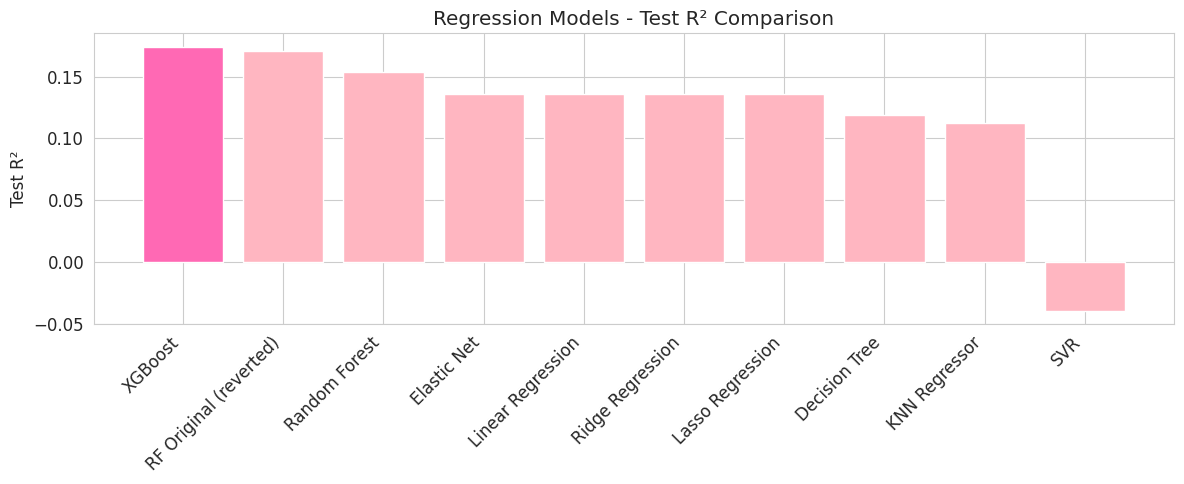

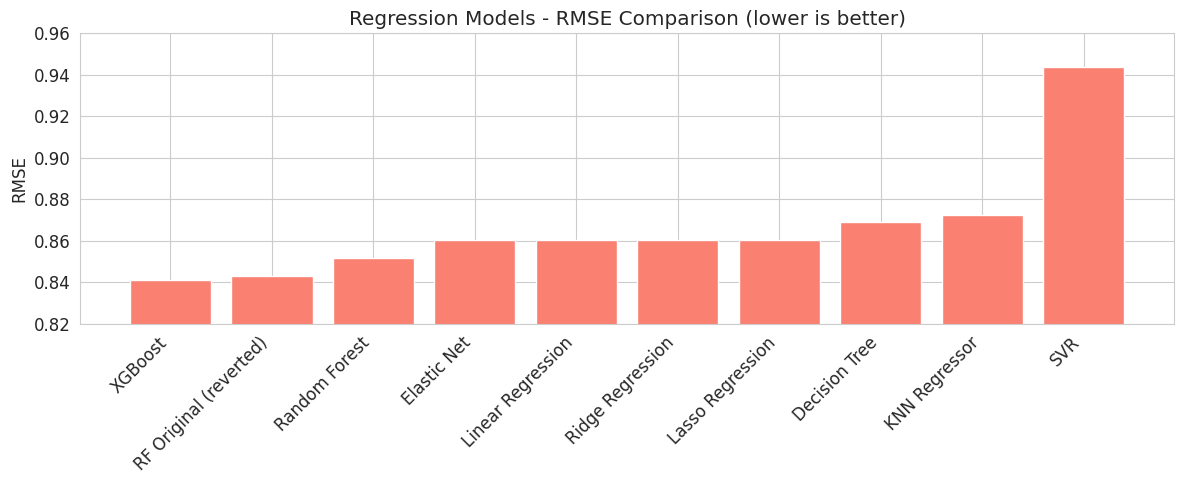

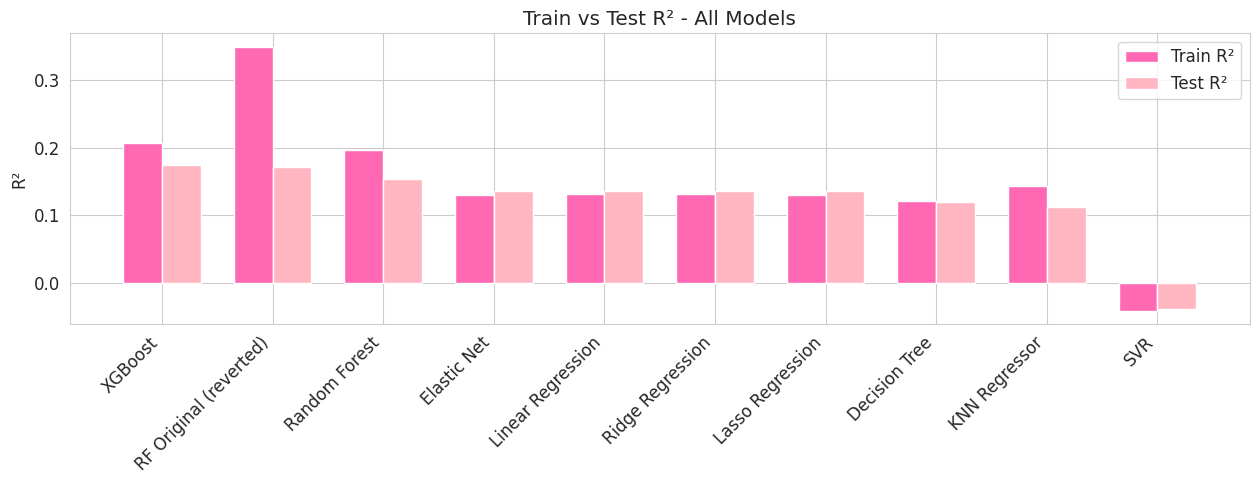

best model: XGBoost
test r2:    0.17433492591601496
rmse:       0.8412876278050402


In [ ]:
reg_df = pd.DataFrame(regression_results)
reg_df = reg_df.sort_values('test r2', ascending=False).reset_index(drop=True)

print(reg_df.to_string(index=False))

colors = ['hotpink' if i == 0 else 'lightpink' for i in range(len(reg_df))]
plt.figure(figsize=(12,5))
plt.bar(reg_df['model'], reg_df['test r2'], color=colors, edgecolor='white')
plt.xticks(rotation=45, ha='right')
plt.title('Regression Models - Test R² Comparison')
plt.ylabel('Test R²')
plt.tight_layout()
plt.savefig('reg_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12,5))
plt.bar(reg_df['model'], reg_df['rmse'], color='salmon', edgecolor='white')
plt.xticks(rotation=45, ha='right')
plt.title('Regression Models - RMSE Comparison (lower is better)')
plt.ylabel('RMSE')
plt.tight_layout()
plt.savefig('reg_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


x_pos = np.arange(len(reg_df))
width = 0.35
plt.figure(figsize=(13,5))
plt.bar(x_pos - width/2, reg_df['train r2'], width,
        label='Train R²', color='hotpink', edgecolor='white')
plt.bar(x_pos + width/2, reg_df['test r2'],  width,
        label='Test R²',  color='lightpink', edgecolor='white')
plt.xticks(x_pos, reg_df['model'], rotation=45, ha='right')
plt.title('Train vs Test R² - All Models')
plt.ylabel('R²')
plt.legend()
plt.tight_layout()
plt.savefig('reg_train_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("best model:", reg_df.iloc[0]['model'])
print("test r2:   ", reg_df.iloc[0]['test r2'])
print("rmse:      ", reg_df.iloc[0]['rmse'])

Residual Analysis + Q-Q Plot + Heteroscedasticity


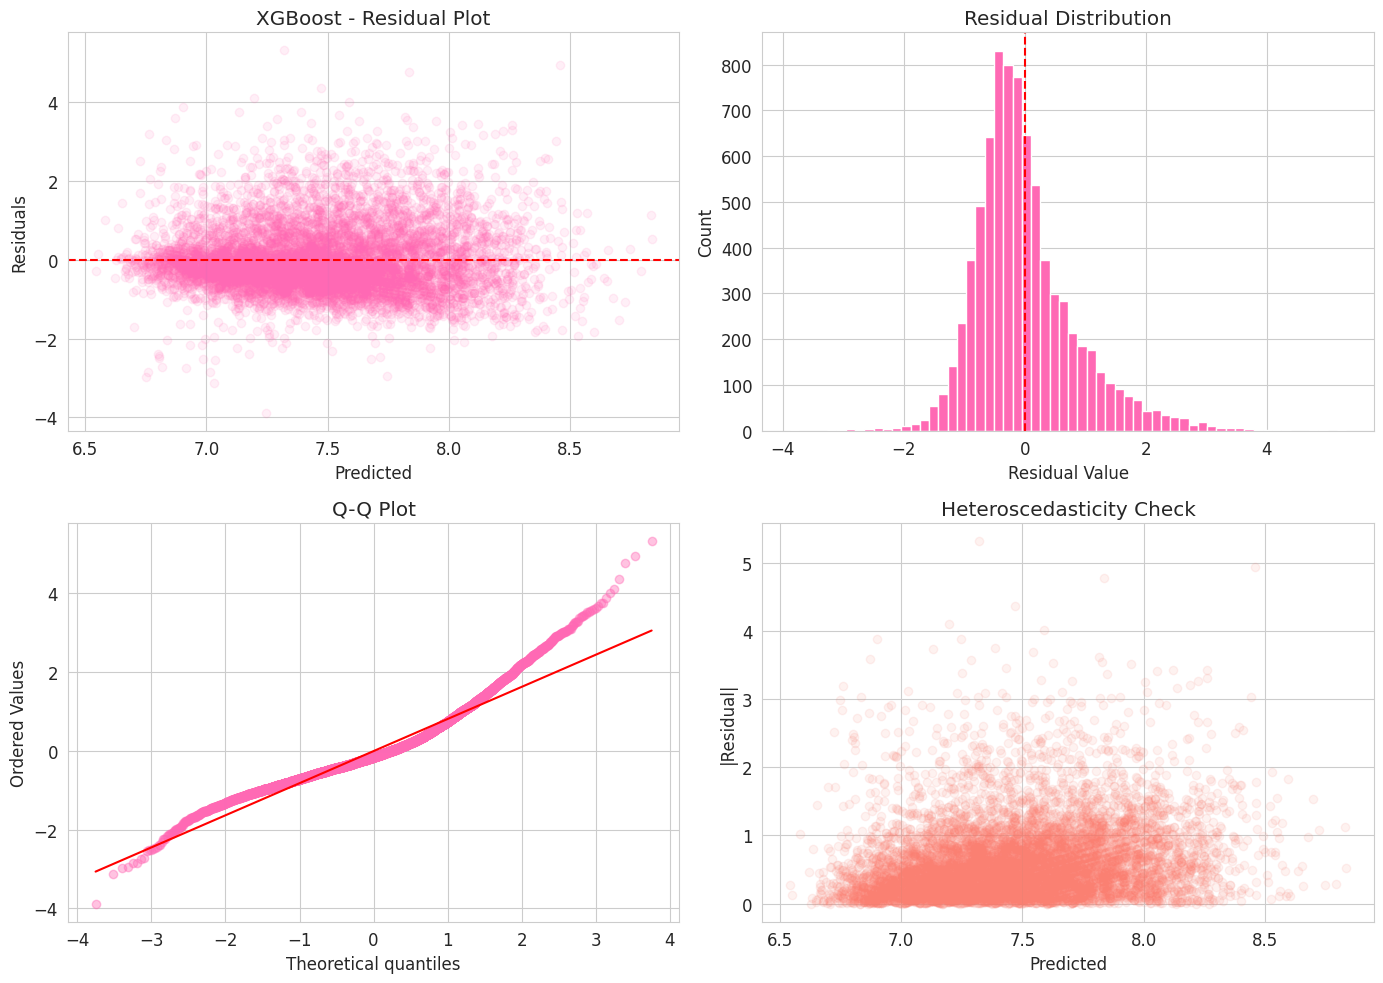

heteroscedasticity correlation: 0.19242205833989992
p-value: 5.279273444370796e-67
some heteroscedasticity found
shapiro test: stat= 0.9418893869595737 p= 4.457036251698935e-13
residuals are not perfectly normal - common for large datasets


In [ ]:
from scipy import stats as scipy_stats

residuals_xgb = y_test_reg.values - y_pred_xgb_reg

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(y_pred_xgb_reg, residuals_xgb, alpha=0.1, color='hotpink')
axes[0,0].axhline(y=0, color='red', linestyle='--')
axes[0,0].set_title('XGBoost - Residual Plot')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Residuals')

axes[0,1].hist(residuals_xgb, bins=60, color='hotpink', edgecolor='white')
axes[0,1].axvline(x=0, color='red', linestyle='--')
axes[0,1].set_title('Residual Distribution')
axes[0,1].set_xlabel('Residual Value')
axes[0,1].set_ylabel('Count')


scipy_stats.probplot(residuals_xgb, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot')
axes[1,0].get_lines()[0].set(color='hotpink', alpha=0.4)
axes[1,0].get_lines()[1].set(color='red')

axes[1,1].scatter(y_pred_xgb_reg, np.abs(residuals_xgb), alpha=0.1, color='salmon')
axes[1,1].set_title('Heteroscedasticity Check')
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('|Residual|')

plt.tight_layout()
plt.savefig('xgb_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

corr, pval = scipy_stats.pearsonr(y_pred_xgb_reg, np.abs(residuals_xgb))
print("heteroscedasticity correlation:", corr)
print("p-value:", pval)
if pval < 0.05:
    print("some heteroscedasticity found")
else:
    print("no major heteroscedasticity (:")

stat, pval2 = scipy_stats.shapiro(residuals_xgb[:500])
print("shapiro test: stat=", stat, "p=", pval2)
if pval2 < 0.05:
    print("residuals are not perfectly normal - common for large datasets")
else:
    print("residuals look approximately normal (:")


Learning Curves


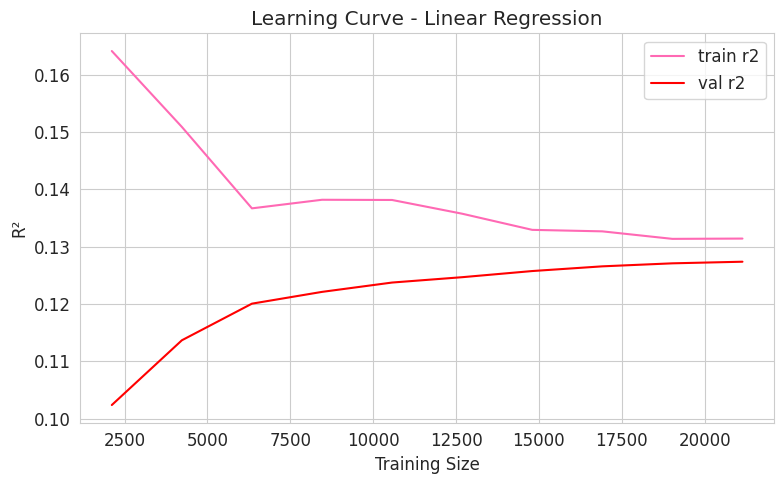

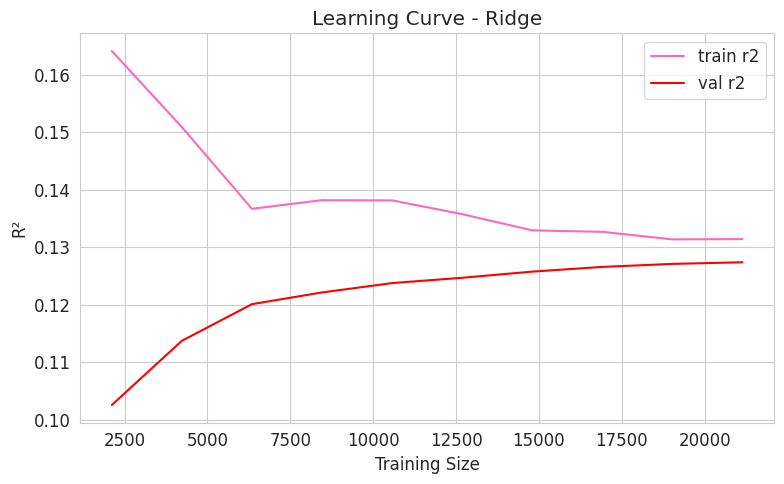

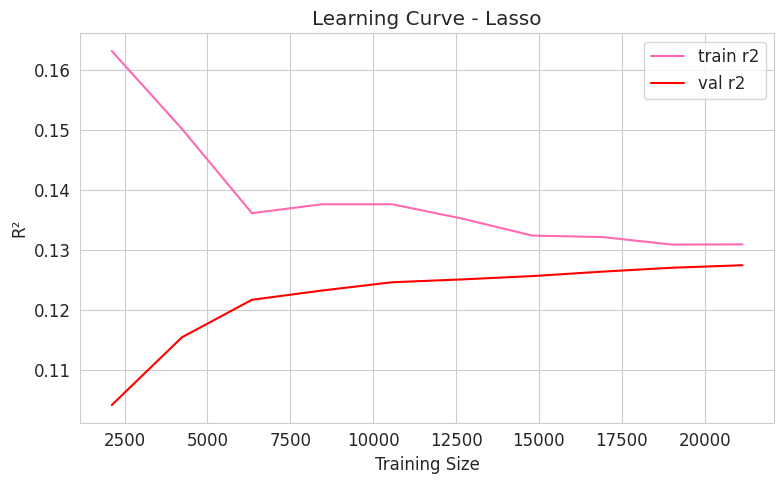

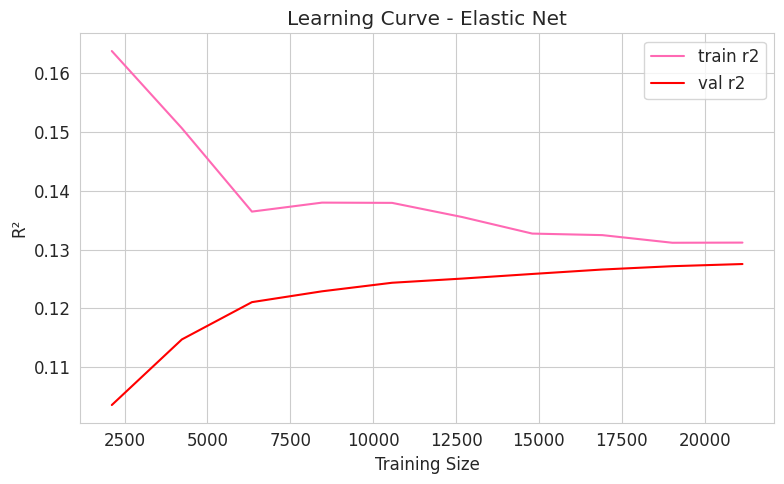

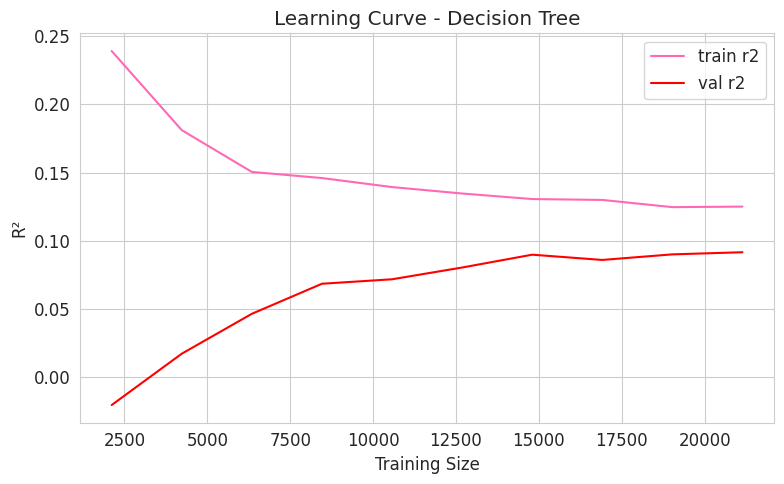

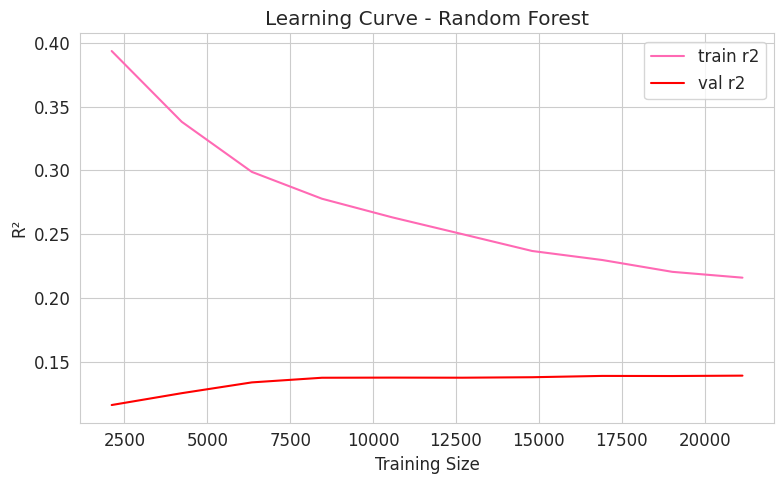

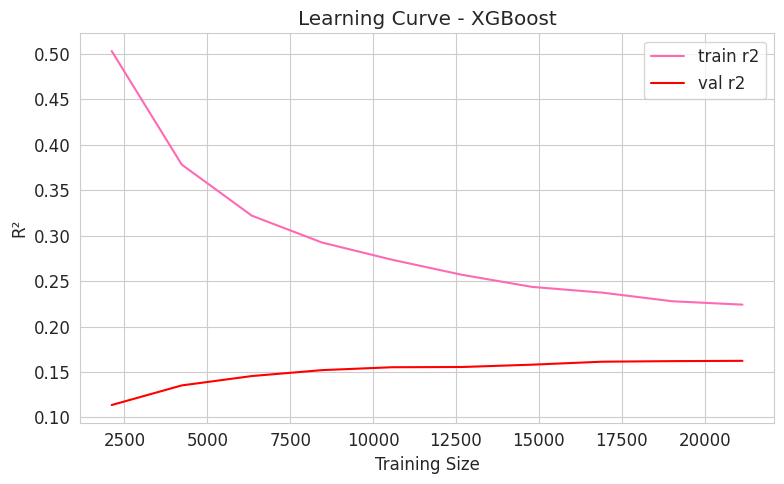

In [ ]:
from sklearn.model_selection import learning_curve

def plot_lc_reg(model, name, x, y):
    train_sizes, train_scores, val_scores = learning_curve(
        model, x, y,
        cv=3, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2'
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_mean, label='train r2', color='hotpink')
    plt.plot(train_sizes, val_mean,   label='val r2',   color='red')
    plt.title('Learning Curve - ' + name)
    plt.xlabel('Training Size')
    plt.ylabel('R²')
    plt.legend()
    plt.tight_layout()
    plt.savefig('lc_' + name.replace(' ','_') + '.png',
                dpi=150, bbox_inches='tight')
    plt.show()

reg_models_lc = {
    'Linear Regression': lr_reg,
    'Ridge':             ridge,
    'Lasso':             lasso,
    'Elastic Net':       enet,
    'Decision Tree':     dt_reg,
    'Random Forest':     rf_reg,
    'XGBoost':           xgb_reg
}

for name, model in reg_models_lc.items():
    plot_lc_reg(model, name, x_train, y_train_reg)

SHAP Explainability



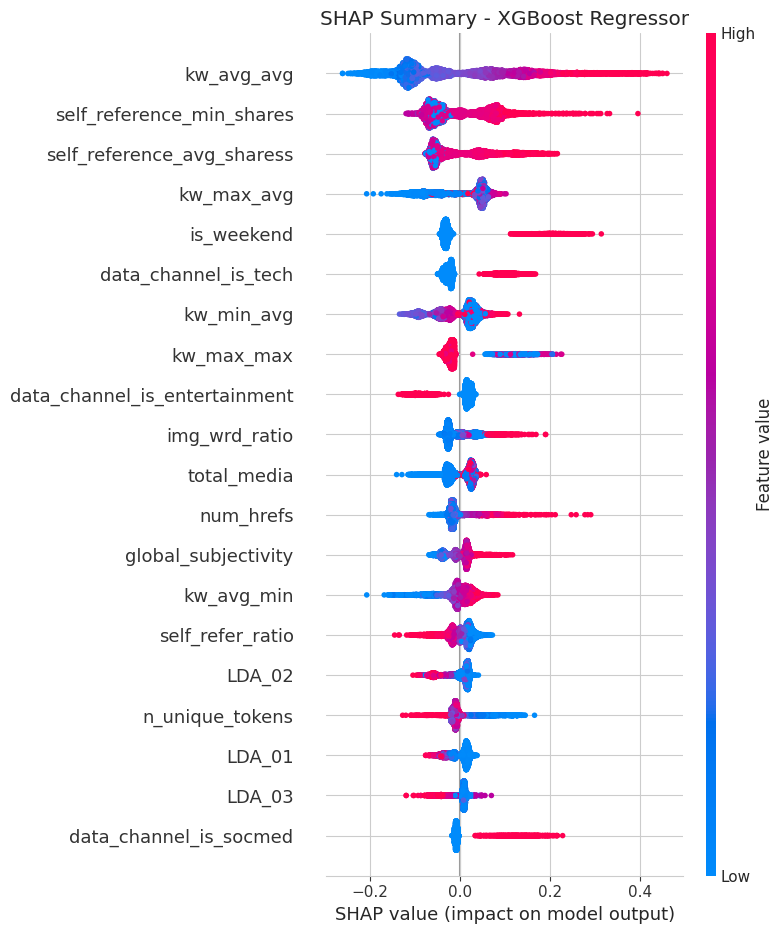

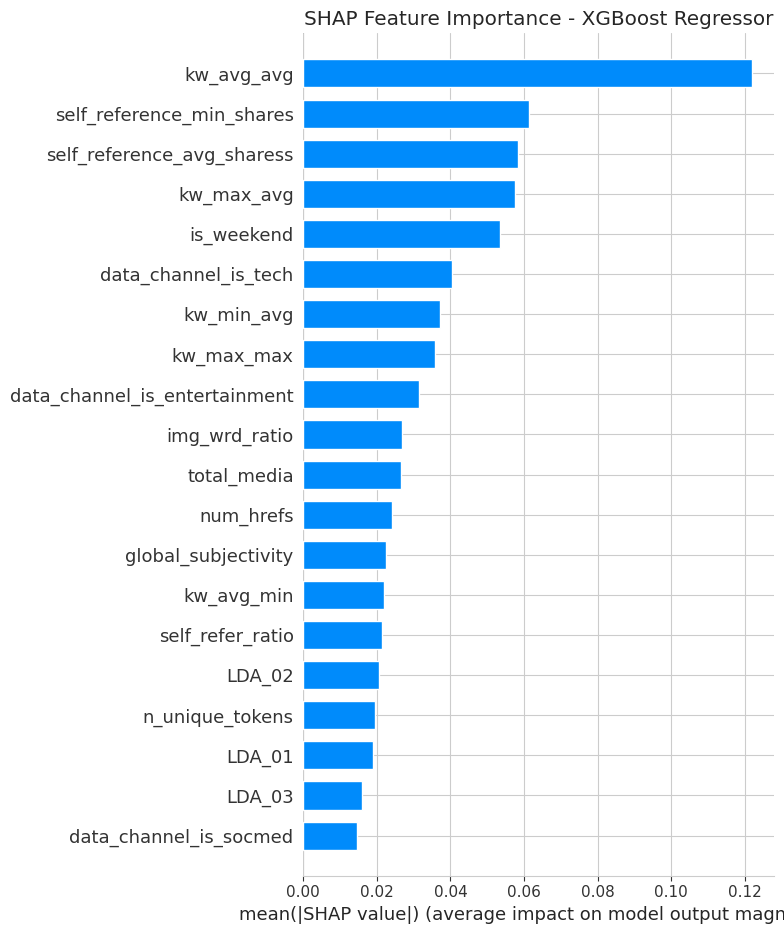

top feature by shap: kw_avg_avg


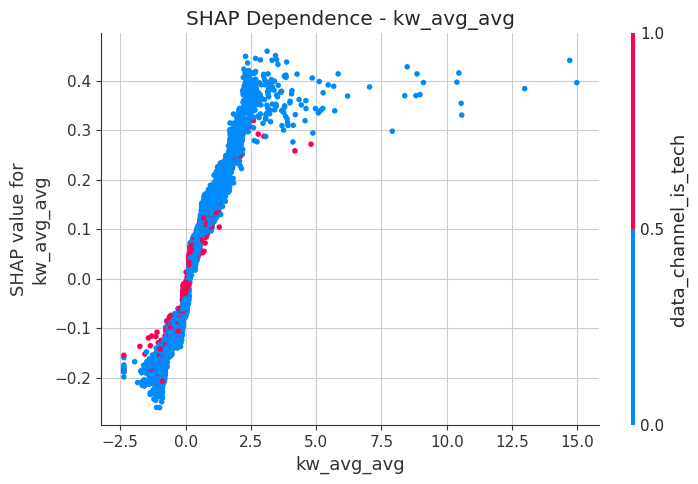

In [ ]:
import shap

explainer_reg   = shap.TreeExplainer(xgb_reg)
shap_values_reg = explainer_reg.shap_values(x_test)

shap.summary_plot(shap_values_reg, x_test,
                  feature_names=final_features, show=False)
plt.title('SHAP Summary - XGBoost Regressor')
plt.tight_layout()
plt.savefig('shap_reg_summary.png', dpi=150, bbox_inches='tight')
plt.show()

shap.summary_plot(shap_values_reg, x_test, plot_type='bar',
                  feature_names=final_features, show=False)
plt.title('SHAP Feature Importance - XGBoost Regressor')
plt.tight_layout()
plt.savefig('shap_reg_bar.png', dpi=150, bbox_inches='tight')
plt.show()

top_feat = x_test.columns[np.abs(shap_values_reg).mean(axis=0).argmax()]
print("top feature by shap:", top_feat)
shap.dependence_plot(top_feat, shap_values_reg, x_test,
                     feature_names=final_features, show=False)
plt.title('SHAP Dependence - ' + top_feat)
plt.tight_layout()
plt.savefig('shap_reg_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

Robustness Testing

10% data -> r2: 0.12993028027794684
30% data -> r2: 0.15608417283876685
50% data -> r2: 0.16427258233834696
99% data -> r2: 0.17473982711519664


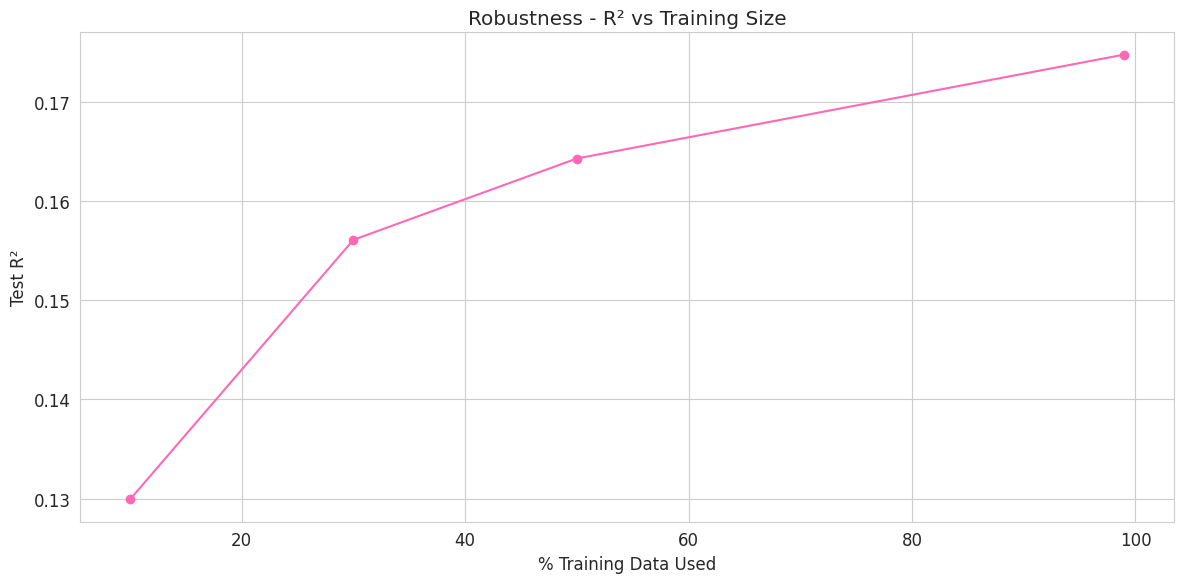

noise low -> r2: 0.16158376479647063
noise medium -> r2: 0.1530186190266949
noise high -> r2: 0.11553558623317084


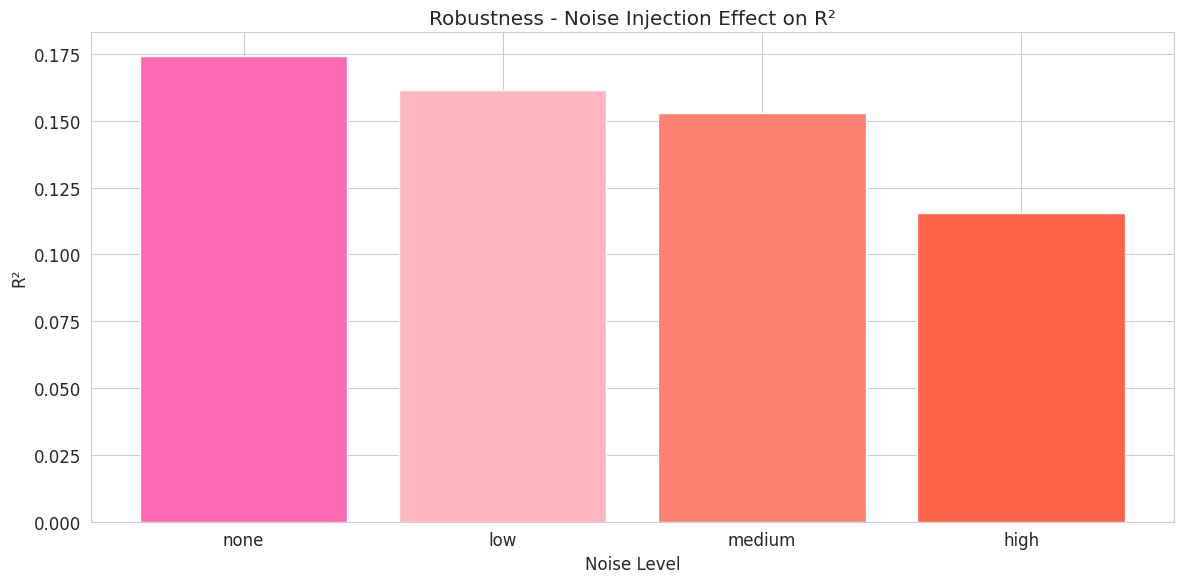

removed 1 features -> r2: 0.1712622015021419
removed 2 features -> r2: 0.17065110521665816
removed 3 features -> r2: 0.16708376545621684
removed 4 features -> r2: 0.15550591947536863
removed 5 features -> r2: 0.1560927053770501
removed 6 features -> r2: 0.15554913007501203
removed 7 features -> r2: 0.15035444669128728
removed 8 features -> r2: 0.14895351802219137
removed 9 features -> r2: 0.14273904485551703
removed 10 features -> r2: 0.14091943054985456


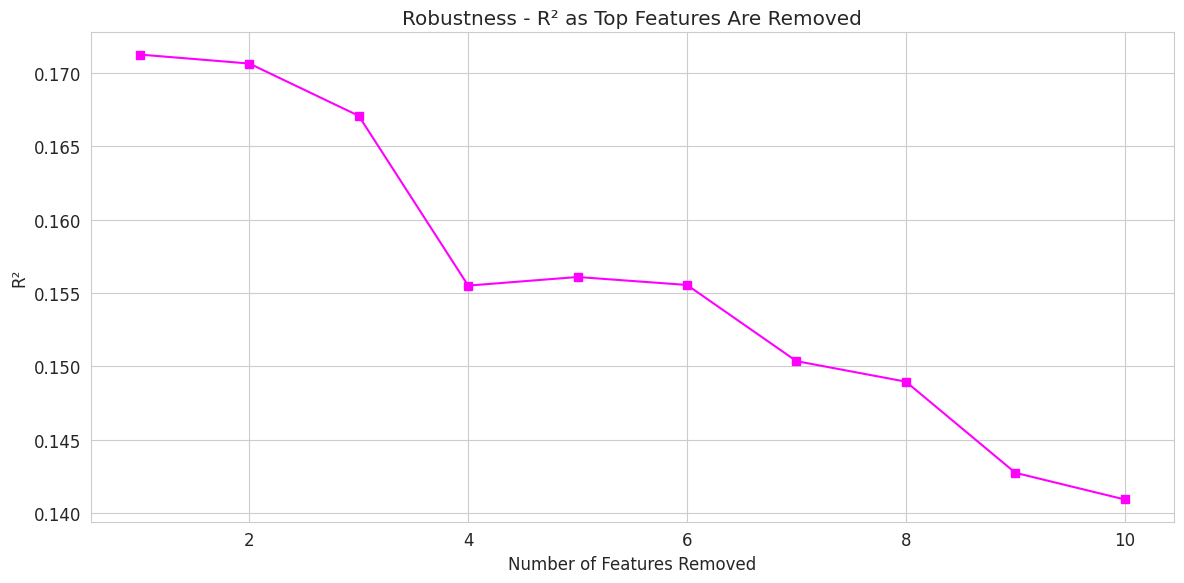

1% outliers -> r2: 0.1163144988846474
5% outliers -> r2: -0.144132221337967
10% outliers -> r2: -0.4337459479378478


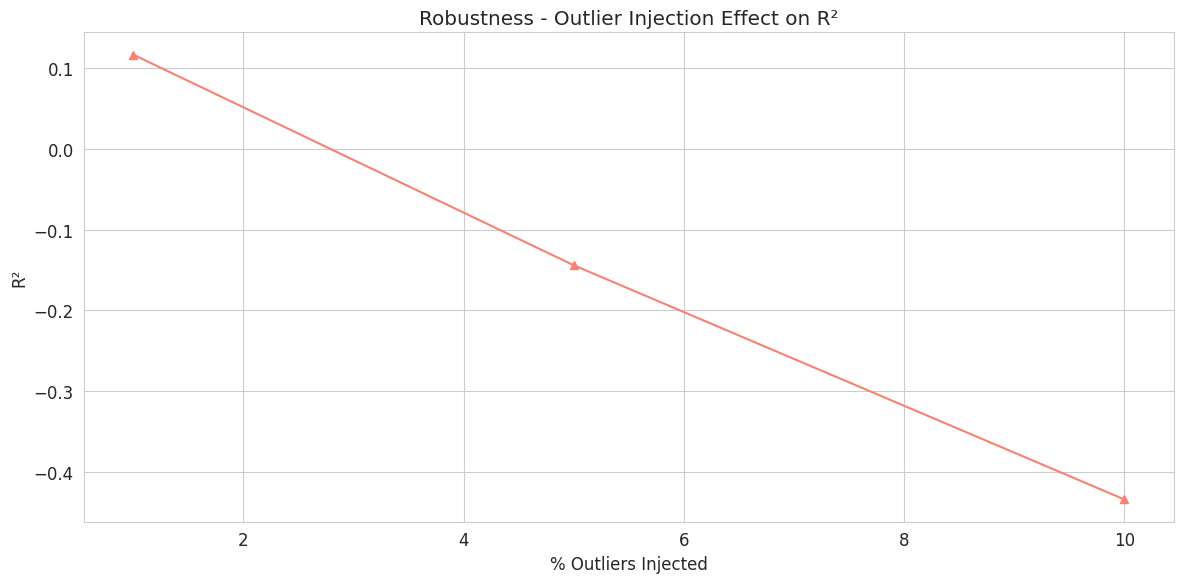

In [ ]:

fractions = [0.1, 0.3, 0.5, 0.99]
r2_fracs  = []

for frac in fractions:
    x_frac, _, y_frac, _ = train_test_split(
        x_train, y_train_reg, train_size=frac, random_state=42)
    m = XGBRegressor(n_estimators=300, max_depth=4,
                     learning_rate=0.05, random_state=42, n_jobs=-1)
    m.fit(x_frac, y_frac)
    r2_fracs.append(r2_score(y_test_reg, m.predict(x_test)))
    print(f"{int(frac*100)}% data -> r2:", r2_fracs[-1])

plt.plot([int(f*100) for f in fractions], r2_fracs,
         marker='o', color='hotpink')
plt.title('Robustness - R² vs Training Size')
plt.xlabel('% Training Data Used')
plt.ylabel('Test R²')
plt.grid(True)
plt.tight_layout()
plt.savefig('robust_training_size.png', dpi=150, bbox_inches='tight')
plt.show()

noise_levels = {'low': 0.01, 'medium': 0.1, 'high': 0.5}
r2_noise = {}
for level, sigma in noise_levels.items():
    x_noisy = x_test.copy()
    x_noisy += np.random.normal(0, sigma, x_noisy.shape)
    r2_noise[level] = r2_score(y_test_reg, xgb_reg.predict(x_noisy))
    print("noise", level, "-> r2:", r2_noise[level])

r2_noise['none'] = r2_score(y_test_reg, xgb_reg.predict(x_test))
order  = ['none', 'low', 'medium', 'high']
values = [r2_noise[k] for k in order]

plt.bar(order, values,
        color=['hotpink','lightpink','salmon','tomato'], edgecolor='white')
plt.title('Robustness - Noise Injection Effect on R²')
plt.xlabel('Noise Level')
plt.ylabel('R²')
plt.tight_layout()
plt.savefig('robust_noise.png', dpi=150, bbox_inches='tight')
plt.show()

top_shap = list(x_test.columns[
    np.abs(shap_values_reg).mean(axis=0).argsort()[::-1][:10]])
r2_removal   = []
removed_list = []

for feat in top_shap:
    removed_list.append(feat)
    remaining = [f for f in final_features if f not in removed_list]
    m = XGBRegressor(n_estimators=300, max_depth=4,
                     learning_rate=0.05, random_state=42, n_jobs=-1)
    m.fit(x_train[remaining], y_train_reg)
    r2_removal.append(r2_score(y_test_reg, m.predict(x_test[remaining])))
    print(f"removed {len(removed_list)} features -> r2:", r2_removal[-1])

plt.plot(range(1, len(top_shap)+1), r2_removal,
         marker='s', color='magenta')
plt.title('Robustness - R² as Top Features Are Removed')
plt.xlabel('Number of Features Removed')
plt.ylabel('R²')
plt.grid(True)
plt.tight_layout()
plt.savefig('robust_removal.png', dpi=150, bbox_inches='tight')
plt.show()

outlier_pcts = [0.01, 0.05, 0.10]
r2_outliers  = []

for pct in outlier_pcts:
    x_out = x_test.copy()
    n_out = int(len(x_out) * pct)
    idx   = np.random.choice(len(x_out), n_out, replace=False)
    x_out.iloc[idx] += 5 * x_out.std()
    r2_outliers.append(r2_score(y_test_reg, xgb_reg.predict(x_out)))
    print(f"{int(pct*100)}% outliers -> r2:", r2_outliers[-1])

plt.plot([int(p*100) for p in outlier_pcts], r2_outliers,
         marker='^', color='salmon')
plt.title('Robustness - Outlier Injection Effect on R²')
plt.xlabel('% Outliers Injected')
plt.ylabel('R²')
plt.grid(True)
plt.tight_layout()
plt.savefig('robust_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

Wilcoxon Statistical Significance Test



XGBoost cv r2: 0.16435640633100443 +- 0.012264539088309006
-----------------------------------------------------------------
model                        cv r2    ttest p   wilcoxon p   sig?
-----------------------------------------------------------------
Linear Regression           0.1270     0.0002       0.0625     no
Ridge                       0.1271     0.0002       0.0625     no
Lasso                       0.1270     0.0002       0.0625     no
Elastic Net                 0.1271     0.0002       0.0625     no
Decision Tree               0.0979     0.0001       0.0625     no
Random Forest               0.1383     0.0014       0.0625     no
-----------------------------------------------------------------
p < 0.05 means xgboost is significantly better than that model


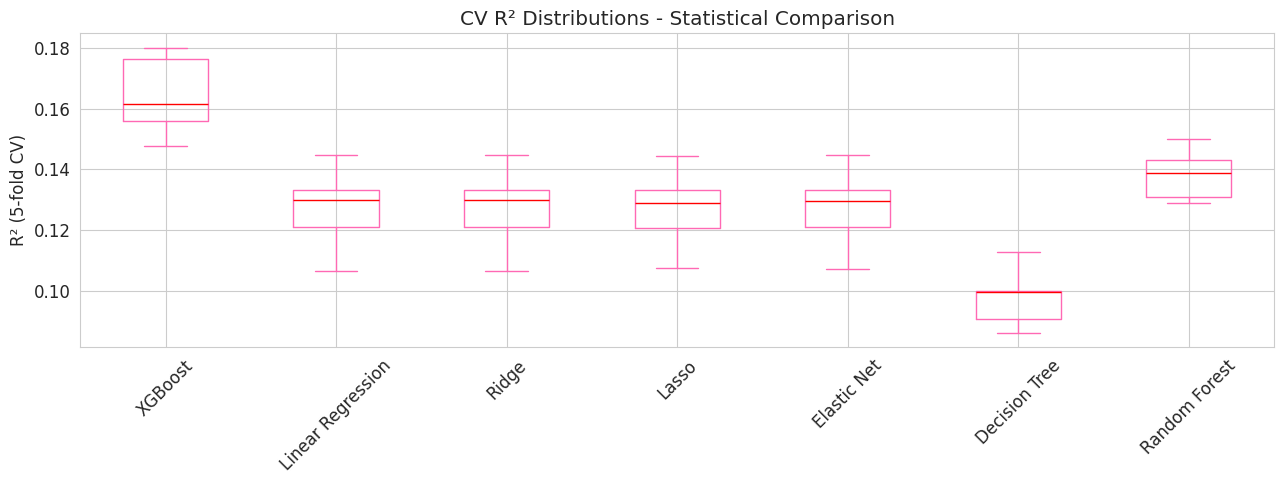


best model: XGBoost Regressor
test r2:   0.17433492591601496
rmse:      0.8412876278050402
note: r2 of 0.15-0.20 is normal for this dataset
predicting viral news is hard - human behavior is not fully predictable (:


In [65]:
from scipy.stats import wilcoxon, ttest_rel
from sklearn.model_selection import cross_val_score

cv = 5

xgb_cv = cross_val_score(
    XGBRegressor(n_estimators=300, max_depth=4,
                 learning_rate=0.05, random_state=42, n_jobs=-1),
    x_train, y_train_reg, cv=cv, scoring='r2', n_jobs=-1
)
print("XGBoost cv r2:", xgb_cv.mean(), "+-", xgb_cv.std())

comparison_models_reg = {
    'Linear Regression': lr_reg,
    'Ridge':             ridge,
    'Lasso':             lasso,
    'Elastic Net':       enet,
    'Decision Tree':     dt_reg,
    'Random Forest':     rf_reg,
}

print('-' * 65)
print(f"{'model':<25} {'cv r2':>8} {'ttest p':>10} {'wilcoxon p':>12} {'sig?':>6}")
print('-' * 65)

for name, model in comparison_models_reg.items():
    cv_scores = cross_val_score(
        model, x_train, y_train_reg,
        cv=cv, scoring='r2', n_jobs=-1
    )
    t_stat, t_pval = ttest_rel(xgb_cv, cv_scores)
    try:
        w_stat, w_pval = wilcoxon(xgb_cv, cv_scores)
    except:
        w_pval = 1.0

    sig = 'yes' if w_pval < 0.05 else 'no'
    print(f"{name:<25} {cv_scores.mean():>8.4f} "
          f"{t_pval:>10.4f} {w_pval:>12.4f} {sig:>6}")

print('-' * 65)
print("p < 0.05 means xgboost is significantly better than that model")

all_cv = {'XGBoost': xgb_cv}
for name, model in comparison_models_reg.items():
    all_cv[name] = cross_val_score(
        model, x_train, y_train_reg,
        cv=cv, scoring='r2', n_jobs=-1
    )

cv_df = pd.DataFrame(all_cv)
cv_df.boxplot(figsize=(13,5), rot=45,
              boxprops=dict(color='hotpink'),
              medianprops=dict(color='red'),
              whiskerprops=dict(color='hotpink'),
              capprops=dict(color='hotpink'))
plt.title('CV R² Distributions - Statistical Comparison')
plt.ylabel('R² (5-fold CV)')
plt.tight_layout()
plt.savefig('wilcoxon_reg.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("best model: XGBoost Regressor")
print("test r2:  ", r2_score(y_test_reg, y_pred_xgb_reg))
print("rmse:     ", np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg)))
print("note: r2 of 0.15-0.20 is normal for this dataset")
print("predicting viral news is hard - human behavior is not fully predictable (:")

Dashboard

In [67]:
!pip install gradio -q

import gradio as gr
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             mean_absolute_error, mean_squared_error, r2_score)

plt.close('all')

clf_models = {
    "Logistic Regression":     (lr,          x_test_clf),
    "PCA Logistic Regression": (lr_pca,      x_test_pca),
    "KNN":                     (knn,         x_test_clf),
    "Decision Tree":           (dt,          x_test_clf),
    "Random Forest":           (best_rf,     x_test_clf),
    "SVC rbf":                 (svm_sampled, x_test_clf),
    "SVC linear":              (svm_linear,  x_test_clf),
    "XGBoost":                 (xgb,         x_test_clf),
}

reg_models = {
    "Linear Regression": (lr_reg,  x_test),
    "Ridge":             (ridge,   x_test),
    "Lasso":             (lasso,   x_test),
    "Elastic Net":       (enet,    x_test),
    "KNN Regressor":     (knn_reg, x_test),
    "SVR":               (svr,     x_test),
    "Decision Tree":     (dt_reg,  x_test),
    "Random Forest":     (rf_reg,  x_test),
    "XGBoost":           (xgb_reg, x_test),
}

# Classification

def clf_metrics(model_name):
    plt.close('all')  # clean up before each call
    model, x_test_used = clf_models[model_name]
    y_pred = model.predict(x_test_used)
    y_prob = model.predict_proba(x_test_used)[:, 1]

    metrics_df = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
        "Value":  [f"{accuracy_score(y_test_clf, y_pred):.4f}",
                   f"{precision_score(y_test_clf, y_pred):.4f}",
                   f"{recall_score(y_test_clf, y_pred):.4f}",
                   f"{f1_score(y_test_clf, y_pred):.4f}"]
    })

    fig1, ax1 = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_test_clf, y_pred)
    im = ax1.imshow(cm, cmap='RdPu')
    ax1.set_xticks([0, 1]); ax1.set_xticklabels(['Not Popular', 'Popular'])
    ax1.set_yticks([0, 1]); ax1.set_yticklabels(['Not Popular', 'Popular'])
    for i in range(2):
        for j in range(2):
            ax1.text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white', fontsize=14, fontweight='bold')
    ax1.set_title(f'Confusion Matrix — {model_name}')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')
    plt.colorbar(im, ax=ax1)
    plt.tight_layout()

    fig2, ax2 = plt.subplots(figsize=(5, 4))
    fpr, tpr, _ = roc_curve(y_test_clf, y_prob)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color='hotpink', label=f'AUC = {roc_auc:.4f}')
    ax2.plot([0, 1], [0, 1], 'k--', label='Random')
    ax2.set_title(f'ROC Curve — {model_name}')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.legend()
    plt.tight_layout()

    return metrics_df, fig1, fig2

#  Regression

def reg_metrics(model_name):
    plt.close('all')  # clean up before each call
    model, x_test_used = reg_models[model_name]
    y_pred = model.predict(x_test_used)

    r2     = r2_score(y_test_reg, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    mae    = mean_absolute_error(y_test_reg, y_pred)
    mse    = mean_squared_error(y_test_reg, y_pred)
    n      = len(y_test_reg)
    p      = x_test_used.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    metrics_df = pd.DataFrame({
        "Metric": ["R²", "Adjusted R²", "RMSE", "MAE", "MSE"],
        "Value":  [f"{r2:.4f}", f"{adj_r2:.4f}",
                   f"{rmse:.4f}", f"{mae:.4f}", f"{mse:.4f}"]
    })

    fig1, ax1 = plt.subplots(figsize=(6, 4))
    ax1.scatter(y_test_reg, y_pred, alpha=0.1, color='hotpink')
    ax1.plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()], 'r--', label='Perfect')
    ax1.set_title(f'Actual vs Predicted — {model_name}')
    ax1.set_xlabel('Actual Log Shares')
    ax1.set_ylabel('Predicted Log Shares')
    ax1.legend()
    plt.tight_layout()

    residuals = y_test_reg - y_pred
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    ax2.scatter(y_pred, residuals, alpha=0.1, color='salmon')
    ax2.axhline(y=0, color='red', linestyle='--')
    ax2.set_title(f'Residual Plot — {model_name}')
    ax2.set_xlabel('Predicted Log Shares')
    ax2.set_ylabel('Residuals')
    plt.tight_layout()

    return metrics_df, fig1, fig2

#  Feature Importance

def feature_importance(model_name):
    plt.close('all')  # clean up before each call
    importance_models = {
        "Random Forest (Classification)": (best_rf,  final_features),
        "XGBoost (Classification)":       (xgb,      final_features),
        "Random Forest (Regression)":     (rf_reg,   final_features),
        "XGBoost (Regression)":           (xgb_reg,  final_features),
    }
    model, features = importance_models[model_name]
    imp = pd.Series(
        model.feature_importances_,
        index=features
    ).sort_values(ascending=False)[:15]

    fig, ax = plt.subplots(figsize=(10, 5))
    imp.plot(kind='bar', color='hotpink', edgecolor='white', ax=ax)
    ax.set_title(f'Top 15 Feature Importances — {model_name}')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    return fig

# Model Comparison

def model_comparison():
    clf_data = []
    for name, (model, x_used) in clf_models.items():
        y_pred = model.predict(x_used)
        clf_data.append({
            "Model":     name,
            "Accuracy":  f"{accuracy_score(y_test_clf, y_pred):.4f}",
            "Precision": f"{precision_score(y_test_clf, y_pred):.4f}",
            "Recall":    f"{recall_score(y_test_clf, y_pred):.4f}",
            "F1-Score":  f"{f1_score(y_test_clf, y_pred):.4f}",
        })

    reg_data = []
    for name, (model, x_used) in reg_models.items():
        y_pred = model.predict(x_used)
        reg_data.append({
            "Model": name,
            "R²":    f"{r2_score(y_test_reg, y_pred):.4f}",
            "RMSE":  f"{np.sqrt(mean_squared_error(y_test_reg, y_pred)):.4f}",
            "MAE":   f"{mean_absolute_error(y_test_reg, y_pred):.4f}",
        })

    return pd.DataFrame(clf_data), pd.DataFrame(reg_data)

# Build Dashboard

with gr.Blocks(theme=gr.themes.Soft(), title="News Popularity Dashboard") as dashboard:

    gr.Markdown("# Online News Popularity Dashboard")
    gr.Markdown("DS230 Final Project — Task A (Classification) & Task B (Regression)")

    with gr.Tab("Task A — Classification"):
        gr.Markdown("### Select a model to view results")
        clf_dropdown = gr.Dropdown(
            choices=list(clf_models.keys()),
            value="XGBoost", label="Classification Model"
        )
        clf_btn   = gr.Button("Run", variant="primary")
        clf_table = gr.DataFrame(label="Performance Metrics")
        with gr.Row():
            clf_cm  = gr.Plot(label="Confusion Matrix")
            clf_roc = gr.Plot(label="ROC Curve")
        clf_btn.click(fn=clf_metrics,
                      inputs=clf_dropdown,
                      outputs=[clf_table, clf_cm, clf_roc])

    with gr.Tab("Task B — Regression"):
        gr.Markdown("### Select a model to view results")
        reg_dropdown = gr.Dropdown(
            choices=list(reg_models.keys()),
            value="XGBoost", label="Regression Model"
        )
        reg_btn   = gr.Button("Run", variant="primary")
        reg_table = gr.DataFrame(label="Performance Metrics")
        with gr.Row():
            reg_avp = gr.Plot(label="Actual vs Predicted")
            reg_res = gr.Plot(label="Residual Plot")
        reg_btn.click(fn=reg_metrics,
                      inputs=reg_dropdown,
                      outputs=[reg_table, reg_avp, reg_res])

    with gr.Tab("Feature Importance"):
        gr.Markdown("### Top 15 most important features per model")
        imp_dropdown = gr.Dropdown(
            choices=["Random Forest (Classification)",
                     "XGBoost (Classification)",
                     "Random Forest (Regression)",
                     "XGBoost (Regression)"],
            value="XGBoost (Regression)", label="Select Model"
        )
        imp_btn  = gr.Button("Show", variant="primary")
        imp_plot = gr.Plot(label="Feature Importance")
        imp_btn.click(fn=feature_importance,
                      inputs=imp_dropdown,
                      outputs=imp_plot)

    with gr.Tab("Model Comparison"):
        gr.Markdown("### Compare all models side by side")
        comp_btn = gr.Button("Show All Models", variant="primary")
        gr.Markdown("#### Task A — Classification")
        comp_clf = gr.DataFrame(label="Classification Comparison")
        gr.Markdown("#### Task B — Regression")
        comp_reg = gr.DataFrame(label="Regression Comparison")
        comp_btn.click(fn=model_comparison,
                       inputs=None,
                       outputs=[comp_clf, comp_reg])


dashboard.launch(share=True, debug=False, inline=False, height=900)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6aaf596a0d204025bc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
